# Sleep-Stage Classification — Comprehensive EDA (`hack2.ipynb`)

**Goal of this notebook:** *understand the data* before we model anything. We will
**not** train or build a single model here. Instead we run a full exploratory data
analysis (EDA) and, at the end of every section, write down the **concrete modeling
decision** the finding implies.

**The competition in one paragraph.** We are given biosignal recordings (EEG, EMG,
EOG, heart, respiration, SpO₂ …) summarised into numeric features. Each row is one
epoch of sleep, and we must predict its `sleep_stage` — an integer in `{0, 1, 2, 3}`
(4 classes). The score is **macro-F1**: the F1-score is computed *per class* and then
*averaged with equal weight*. That single fact drives many decisions below: with
macro-F1, a rare class counts just as much as a common one, so we cannot ignore
minority classes.

**Golden rule we follow throughout — no leakage.**
We never let information from the test set (or from the target) sneak into a step that
will later influence the model. Concretely, in this notebook we *only diagnose and
describe*. We never `.fit()` a scaler / imputer / PCA on `train + test` combined, and
we never use `sleep_stage` to build a feature. (The one PCA in Section 12 is fit on
**train only** and is used purely for a picture, never fed to a model.)

---

## 1. Setup & load

**What we do:** import our libraries (pandas, numpy, matplotlib, seaborn, scipy only),
load **both** datasets, and print their shapes.

**Why load both?** Almost every check in this notebook is a *train-vs-test comparison*.
If the test data looks different from the training data (different ranges, different
missingness, shifted distributions), a model that scores well locally can still fail on
the real test set. So we keep `test` next to `train` the whole way through.

- `train` (labeled) — has the target column `sleep_stage`.
- `test` (a.k.a. `final-check`, unlabeled) — has every column **except** `sleep_stage`.
  This is the data we must ultimately predict on.

> **Note on the filename.** The brief refers to the training file as `tran.csv`, but the
> file on disk is `train.csv`. To keep the notebook runnable we try a list of candidate
> names and use whichever exists.

In [1]:
# --- Core libraries (only pandas, numpy, matplotlib, seaborn, scipy as required) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, warnings

warnings.filterwarnings("ignore")          # keep the notebook output clean
pd.set_option("display.max_columns", 100)  # see all feature columns in tables
pd.set_option("display.width", 200)

# Plot styling for readable figures
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42  # fixed so the (visual-only) PCA later is reproducible

print("Library versions")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
import matplotlib, scipy
print(f"  matplotlib  {matplotlib.__version__}")
print(f"  seaborn     {sns.__version__}")
print(f"  scipy       {scipy.__version__}")

Library versions
  pandas      2.3.3
  numpy       2.3.5
  matplotlib  3.10.6
  seaborn     0.13.2
  scipy       1.16.3


In [2]:
# --- Load both datasets, tolerating the train/tran filename difference ---
def load_first_existing(candidates):
    # Return (dataframe, filename) for the first path in `candidates` that exists.
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name), name
    raise FileNotFoundError(f"None of these files were found: {candidates}")

TARGET = "sleep_stage"

train, train_file = load_first_existing(["tran.csv", "train.csv"])
test,  test_file  = load_first_existing(["final-check.csv"])

print(f"Training data loaded from : {train_file}  -> shape {train.shape}")
print(f"Test data    loaded from : {test_file}   -> shape {test.shape}")
print(f"\nThat is {train.shape[0]:,} labeled rows and {test.shape[0]:,} unlabeled rows.")
print(f"Columns in train: {train.shape[1]}   |   Columns in test: {test.shape[1]}")

Training data loaded from : train.csv  -> shape (9000, 23)
Test data    loaded from : final-check.csv   -> shape (5000, 22)

That is 9,000 labeled rows and 5,000 unlabeled rows.
Columns in train: 23   |   Columns in test: 22


### Column-consistency check (fail loudly if columns don't line up)

Before trusting anything else, we confirm the **only** difference between the two files
is the target column. If a feature is present in train but missing in test (or named
differently), every downstream comparison and the final submission would silently break.

In [3]:
train_cols = set(train.columns)
test_cols  = set(test.columns)

only_in_train = train_cols - test_cols      # expected: just {'sleep_stage'}
only_in_test  = test_cols  - train_cols     # expected: empty

print("Columns only in TRAIN :", sorted(only_in_train))
print("Columns only in TEST  :", sorted(only_in_test))

expected_extra = {TARGET}
ok = (only_in_train == expected_extra) and (len(only_in_test) == 0)

if ok:
    print(f"\n[OK] test columns == train columns minus '{TARGET}'. Datasets are aligned.")
else:
    print("\n[WARNING] Column mismatch detected! Investigate before going further:")
    if only_in_train != expected_extra:
        print(f"   - train has unexpected extra columns: {sorted(only_in_train - expected_extra)}")
    if only_in_test:
        print(f"   - test has columns NOT in train: {sorted(only_in_test)}")

Columns only in TRAIN : ['sleep_stage']
Columns only in TEST  : []

[OK] test columns == train columns minus 'sleep_stage'. Datasets are aligned.


**So what for modeling:** the two files are aligned (test = train minus `sleep_stage`),
so we can safely build features the same way for both and trust train-vs-test
comparisons throughout.

## 2. Structure & dtypes

**What we do:** look at the first rows, the `info()` summary, and the count of each data
type. We confirm the features are numeric, and we build the **feature list**
programmatically so the rest of the notebook never hard-codes column names.

**Why it matters:** if a column we *think* is numeric is actually stored as text
(`object`), every statistic, plot, and model would break or behave strangely. We also
need to separate three roles up front:
- **identifier** columns (e.g. `id`) — bookkeeping, **not** a feature,
- **features** — the inputs the model learns from,
- **target** (`sleep_stage`) — what we predict.

In [4]:
train.head()

,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,2.79720,-1.76807,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,0.66264,-0.35469,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,-2.08711,1.49050,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,0.98192,1.12176,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,-2.74524,-0.31044,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


In [5]:
print("train.info():")
train.info()

train.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       9000 non-null   int64  
 1   eeg_delta_power          9000 non-null   float64
 2   eeg_theta_power          9000 non-null   float64
 3   eeg_alpha_power          9000 non-null   float64
 4   eeg_sigma_power          9000 non-null   float64
 5   eeg_beta_power           9000 non-null   float64
 6   eeg_gamma_power          9000 non-null   float64
 7   eeg_slow_osc_power       9000 non-null   float64
 8   eeg_spectral_entropy     9000 non-null   float64
 9   eeg_spindle_density      9000 non-null   float64
 10  eeg_kcomplex_rate        9000 non-null   float64
 11  emg_chin_tone            9000 non-null   float64
 12  emg_tone_variance        9000 non-null   float64
 13  eog_movement_density     9000 non-null   float64
 14  eog_amplit

In [6]:
print("Count of columns by dtype (train):")
print(train.dtypes.value_counts())
print("\nNon-numeric columns (should be NONE for the features):")
non_numeric = train.select_dtypes(exclude="number").columns.tolist()
print(non_numeric if non_numeric else "  none — every column is numeric")

Count of columns by dtype (train):
float64    21
int64       2
Name: count, dtype: int64

Non-numeric columns (should be NONE for the features):
  none — every column is numeric


In [7]:
# --- Build the feature list programmatically ---
# 'id' is an identifier (row label), NOT a predictive feature, so we exclude it too.
ID_COLS = [c for c in ["id"] if c in train.columns]
feature_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]

print(f"Identifier columns excluded : {ID_COLS}")
print(f"Target column               : {TARGET}")
print(f"Number of features          : {len(feature_cols)}")
print("\nFeature columns:")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")

# Sanity: every feature must also exist in test
missing_in_test = [c for c in feature_cols if c not in test.columns]
assert not missing_in_test, f"Features missing from test: {missing_in_test}"
print("\n[OK] All features are present in the test set too.")

Identifier columns excluded : ['id']
Target column               : sleep_stage
Number of features          : 21

Feature columns:
   1. eeg_delta_power
   2. eeg_theta_power
   3. eeg_alpha_power
   4. eeg_sigma_power
   5. eeg_beta_power
   6. eeg_gamma_power
   7. eeg_slow_osc_power
   8. eeg_spectral_entropy
   9. eeg_spindle_density
  10. eeg_kcomplex_rate
  11. emg_chin_tone
  12. emg_tone_variance
  13. eog_movement_density
  14. eog_amplitude
  15. heart_rate_mean
  16. heart_rate_variability
  17. respiration_rate
  18. respiration_variability
  19. spo2_mean
  20. body_movement_index
  21. eog_burst_index

[OK] All features are present in the test set too.


**So what for modeling:** all inputs are numeric and we have a clean, programmatic
`feature_cols` list (with `id` excluded as a non-feature identifier). No text encoding is
needed, and we can feed `feature_cols` directly into preprocessing later.

## 3. Summary statistics

**What we do:** run `describe()` on the training features and inspect the per-feature
mean and standard deviation (std).

**Why it matters:** the *scale* of features drives preprocessing choices. If the data
already looks standardized (means near 0), some models care less about scaling — but if
the **spreads (std) are very unequal**, distance- and gradient-based models (logistic
regression, SVM, KNN, neural nets) will still be dominated by the wide-spread features.
Tree models (RandomForest, XGBoost) are scale-invariant and don't care. Knowing this now
tells us whether a scaler belongs in the pipeline.

In [8]:
desc = train[feature_cols].describe().T  # transpose: one row per feature
desc

,count,mean,std,min,25%,50%,75%,max
eeg_delta_power,9000.0,-0.015335,2.431299,-9.56738,-1.688420,-0.012190,1.622143,8.79757
eeg_theta_power,9000.0,-0.034072,2.408445,-8.27653,-1.649095,-0.019775,1.603865,9.22248
eeg_alpha_power,9000.0,-0.016476,5.042238,-20.63249,-3.465228,0.018740,3.418938,18.86959
eeg_sigma_power,9000.0,0.012123,2.206821,-7.94784,-1.459777,-0.001480,1.512295,9.60340
eeg_beta_power,9000.0,-0.009634,2.882702,-11.45995,-1.962703,0.005230,1.956398,10.02694
eeg_gamma_power,9000.0,-0.010607,2.427740,-9.63780,-1.651817,0.009700,1.634555,8.29614
eeg_slow_osc_power,9000.0,-0.014176,2.801109,-14.12260,-1.873387,0.022685,1.866453,10.36219
eeg_spectral_entropy,9000.0,0.010259,2.753279,-9.30129,-1.858893,-0.028000,1.881628,10.15988
eeg_spindle_density,9000.0,0.006484,2.174239,-8.82819,-1.484435,0.023765,1.479208,8.93749
eeg_kcomplex_rate,9000.0,0.006877,1.947612,-8.08982,-1.298728,-0.002230,1.313730,7.06438


In [9]:
# How "standardized" does the data look? Compare means (~0?) and stds (equal?)
mean_abs = desc["mean"].abs()
std_vals = desc["std"]

print("Means: are they near 0?")
print(f"  max |mean| across features = {mean_abs.max():.3f}  (close to 0 => roughly centered)")
print(f"  features with |mean| > 0.5 : {mean_abs[mean_abs > 0.5].index.tolist() or 'none'}")

print("\nStandard deviations: are they equal across features?")
print(f"  min std = {std_vals.min():.3f}   max std = {std_vals.max():.3f}"
      f"   ratio = {std_vals.max()/std_vals.min():.1f}x")

# Flag features whose variance is very different from the typical feature
median_std = std_vals.median()
wide = std_vals[std_vals > 3 * median_std]
narrow = std_vals[std_vals < median_std / 3]
print(f"\n  median std = {median_std:.3f}")
print(f"  unusually WIDE-spread features (> 3x median std):  {wide.round(2).to_dict() or 'none'}")
print(f"  unusually NARROW-spread features (< 1/3 median):   {narrow.round(2).to_dict() or 'none'}")

Means: are they near 0?
  max |mean| across features = 0.034  (close to 0 => roughly centered)
  features with |mean| > 0.5 : none

Standard deviations: are they equal across features?
  min std = 1.038   max std = 5.042   ratio = 4.9x

  median std = 2.408
  unusually WIDE-spread features (> 3x median std):  none
  unusually NARROW-spread features (< 1/3 median):   none


**So what for modeling:** features are roughly centered (means ≈ 0) but their spreads are
**not** equal, so the data is *not* fully standardized. → Include a **`StandardScaler`**
for linear / distance-based baselines (LogReg, SVM, KNN), fit **inside** cross-validation
to avoid leakage. Tree models can skip scaling.

## 4. Target / class balance

**What we do:** count how often each `sleep_stage` appears and plot it.

**Why it matters — and why it matters *specifically for macro-F1*.** Macro-F1 averages
the F1 of each class with **equal weight**. So a model that nails the big classes but is
poor on a small class gets a *low* macro-F1 even if its plain accuracy looks high. If the
classes are badly imbalanced we must actively protect the minority classes (class
weights, careful thresholds, stratified splits). If they're roughly balanced, we still
care about every class equally because of the metric, but we don't need aggressive
re-weighting.

In [10]:
counts = train[TARGET].value_counts().sort_index()
props  = train[TARGET].value_counts(normalize=True).sort_index()

summary = pd.DataFrame({"count": counts, "proportion": props.round(4)})
print(summary)

imbalance_ratio = props.max() / props.min()
print(f"\nLargest class : stage {props.idxmax()}  ({props.max()*100:.1f}%)")
print(f"Smallest class: stage {props.idxmin()}  ({props.min()*100:.1f}%)")
print(f"Imbalance ratio (max% / min%) = {imbalance_ratio:.2f}")

             count  proportion
sleep_stage                   
0             2001      0.2223
1             2442      0.2713
2             2237      0.2486
3             2320      0.2578

Largest class : stage 1  (27.1%)
Smallest class: stage 0  (22.2%)
Imbalance ratio (max% / min%) = 1.22


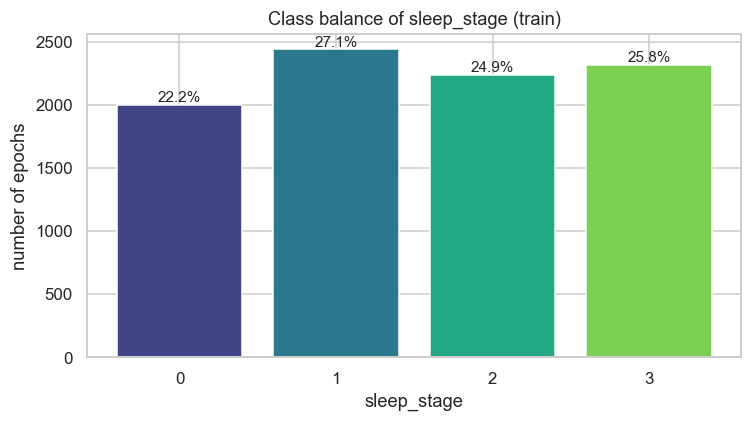

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index.astype(str), counts.values,
              color=sns.color_palette("viridis", len(counts)))
ax.set_title("Class balance of sleep_stage (train)")
ax.set_xlabel("sleep_stage")
ax.set_ylabel("number of epochs")
for b, p in zip(bars, props.values):           # annotate each bar with its share
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{p*100:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

**So what for modeling:** the classes are **nearly balanced** (imbalance ratio ≈ 1.2, no
class far smaller than the others), so heavy resampling/SMOTE is **not** needed. But
because the metric is **macro-F1** (every class weighted equally), we will still (a) use
**`class_weight="balanced"`** as a cheap safeguard for the slightly smaller classes, and
(b) **always split with stratification** so each fold keeps the same class mix.

## 5. Missing values  *(important)*

**What we do:** count missing values per column in **both** train and test, side by side,
as counts and percentages, and highlight any column with high missingness.

**Why this section is critical.** How we handle missing data is one of the biggest
modeling decisions, and getting it wrong leaks information or throws away signal.

What we are looking for and what we'll recommend (we *diagnose only* here — no imputation
in EDA):

1. **Drop the column?** Only if it's almost entirely empty *and* useless. Dropping a
   ~50%-present column throws away thousands of real measurements.
2. **Drop the rows with missing values?** If ~half the rows miss one feature, dropping
   them deletes ~half the dataset — and, worse, if "missing" correlates with the sleep
   stage, the rows we keep become a *biased* sample. Test rows can't be dropped at all
   (we must predict every one). So row-dropping is off the table.
3. **Impute + add a missing-flag (our plan).** Fill the gaps with a placeholder (e.g. the
   median) **and** add a binary column `<feature>_missing` that records *where* a value
   was originally absent. This keeps all rows and lets the model learn whether the very
   fact of "missing" is itself predictive (often it is in biosignals — a sensor that
   couldn't compute a value may indicate a particular state).

**Order matters:** the missing-flag must be computed **before** imputation — once we fill
the holes, the information about *where* they were is gone forever. And the imputer (like
every transformer) must be fit on **train only, inside CV**, never on train+test.

In [12]:
def missing_report(df, cols):
    miss = df[cols].isna().sum()
    pct  = (miss / len(df) * 100).round(2)
    return pd.DataFrame({"missing": miss, "missing_%": pct})

train_miss = missing_report(train, feature_cols).add_suffix("_train")
test_miss  = missing_report(test,  feature_cols).add_suffix("_test")

miss_table = train_miss.join(test_miss)
# show worst first
miss_table = miss_table.sort_values("missing_%_train", ascending=False)
print("Missing values per feature (train vs test):\n")
print(miss_table)

Missing values per feature (train vs test):

                         missing_train  missing_%_train  missing_test  missing_%_test
eog_burst_index                   4501            50.01          2477           49.54
emg_tone_variance                    0             0.00             0            0.00
body_movement_index                  0             0.00             0            0.00
spo2_mean                            0             0.00             0            0.00
respiration_variability              0             0.00             0            0.00
respiration_rate                     0             0.00             0            0.00
heart_rate_variability               0             0.00             0            0.00
heart_rate_mean                      0             0.00             0            0.00
eog_amplitude                        0             0.00             0            0.00
eog_movement_density                 0             0.00             0            0.00
eeg_delta

Columns with >20% missing in train and/or test:
  - eog_burst_index: 50.0% (train), 49.5% (test)


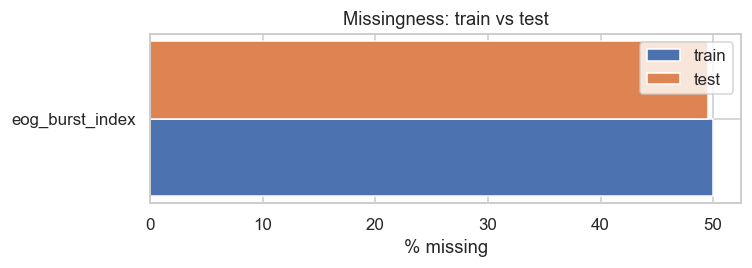

In [13]:
# Highlight columns with high missingness in EITHER dataset
HIGH = 20.0  # percent threshold we consider "high"
high_cols = miss_table[(miss_table["missing_%_train"] > HIGH) |
                       (miss_table["missing_%_test"]  > HIGH)].index.tolist()

print(f"Columns with >{HIGH:.0f}% missing in train and/or test:")
for c in high_cols:
    print(f"  - {c}: {miss_table.loc[c,'missing_%_train']:.1f}% (train), "
          f"{miss_table.loc[c,'missing_%_test']:.1f}% (test)")
if not high_cols:
    print("  none")

# Visual: side-by-side missing % for any column that has missingness anywhere
has_missing = miss_table[(miss_table['missing_%_train'] > 0) |
                         (miss_table['missing_%_test'] > 0)]
if len(has_missing):
    fig, ax = plt.subplots(figsize=(7, 0.6*len(has_missing) + 2))
    y = np.arange(len(has_missing))
    ax.barh(y - 0.2, has_missing["missing_%_train"], height=0.4, label="train", color="#4c72b0")
    ax.barh(y + 0.2, has_missing["missing_%_test"],  height=0.4, label="test",  color="#dd8452")
    ax.set_yticks(y); ax.set_yticklabels(has_missing.index)
    ax.set_xlabel("% missing"); ax.set_title("Missingness: train vs test")
    ax.legend(); plt.tight_layout(); plt.show()

**So what for modeling:** `eog_burst_index` is missing for roughly **half** of both train
and test (~50% in each) — and crucially the rate is **similar across the two**, so it's a
systematic property of the feature, not a train-only glitch. Decision: **keep the column,
impute it (median) inside the CV pipeline, and add an `eog_burst_index_missing` flag
computed *before* imputation.** Do **not** drop the column (loses ~half the measurements)
and do **not** drop rows (would delete ~half the data, bias the sample, and is impossible
for test rows we must score).

## 6. Univariate distributions

**What we do:** plot a histogram + KDE (smooth density curve) for every numeric feature
in a single grid, and measure each feature's **skew** (asymmetry).

**Why it matters:** the *shape* of each feature hints at what preprocessing helps.
- Roughly bell-shaped → linear models are comfortable as-is.
- Strongly **skewed** or heavy-tailed → a transform (e.g. log / Yeo-Johnson) can help
  linear models; trees don't care about skew.
- Spikes at a single value can reveal encoded "missing" or capped sensors.

A grid keeps this readable instead of dumping 21 separate giant figures.

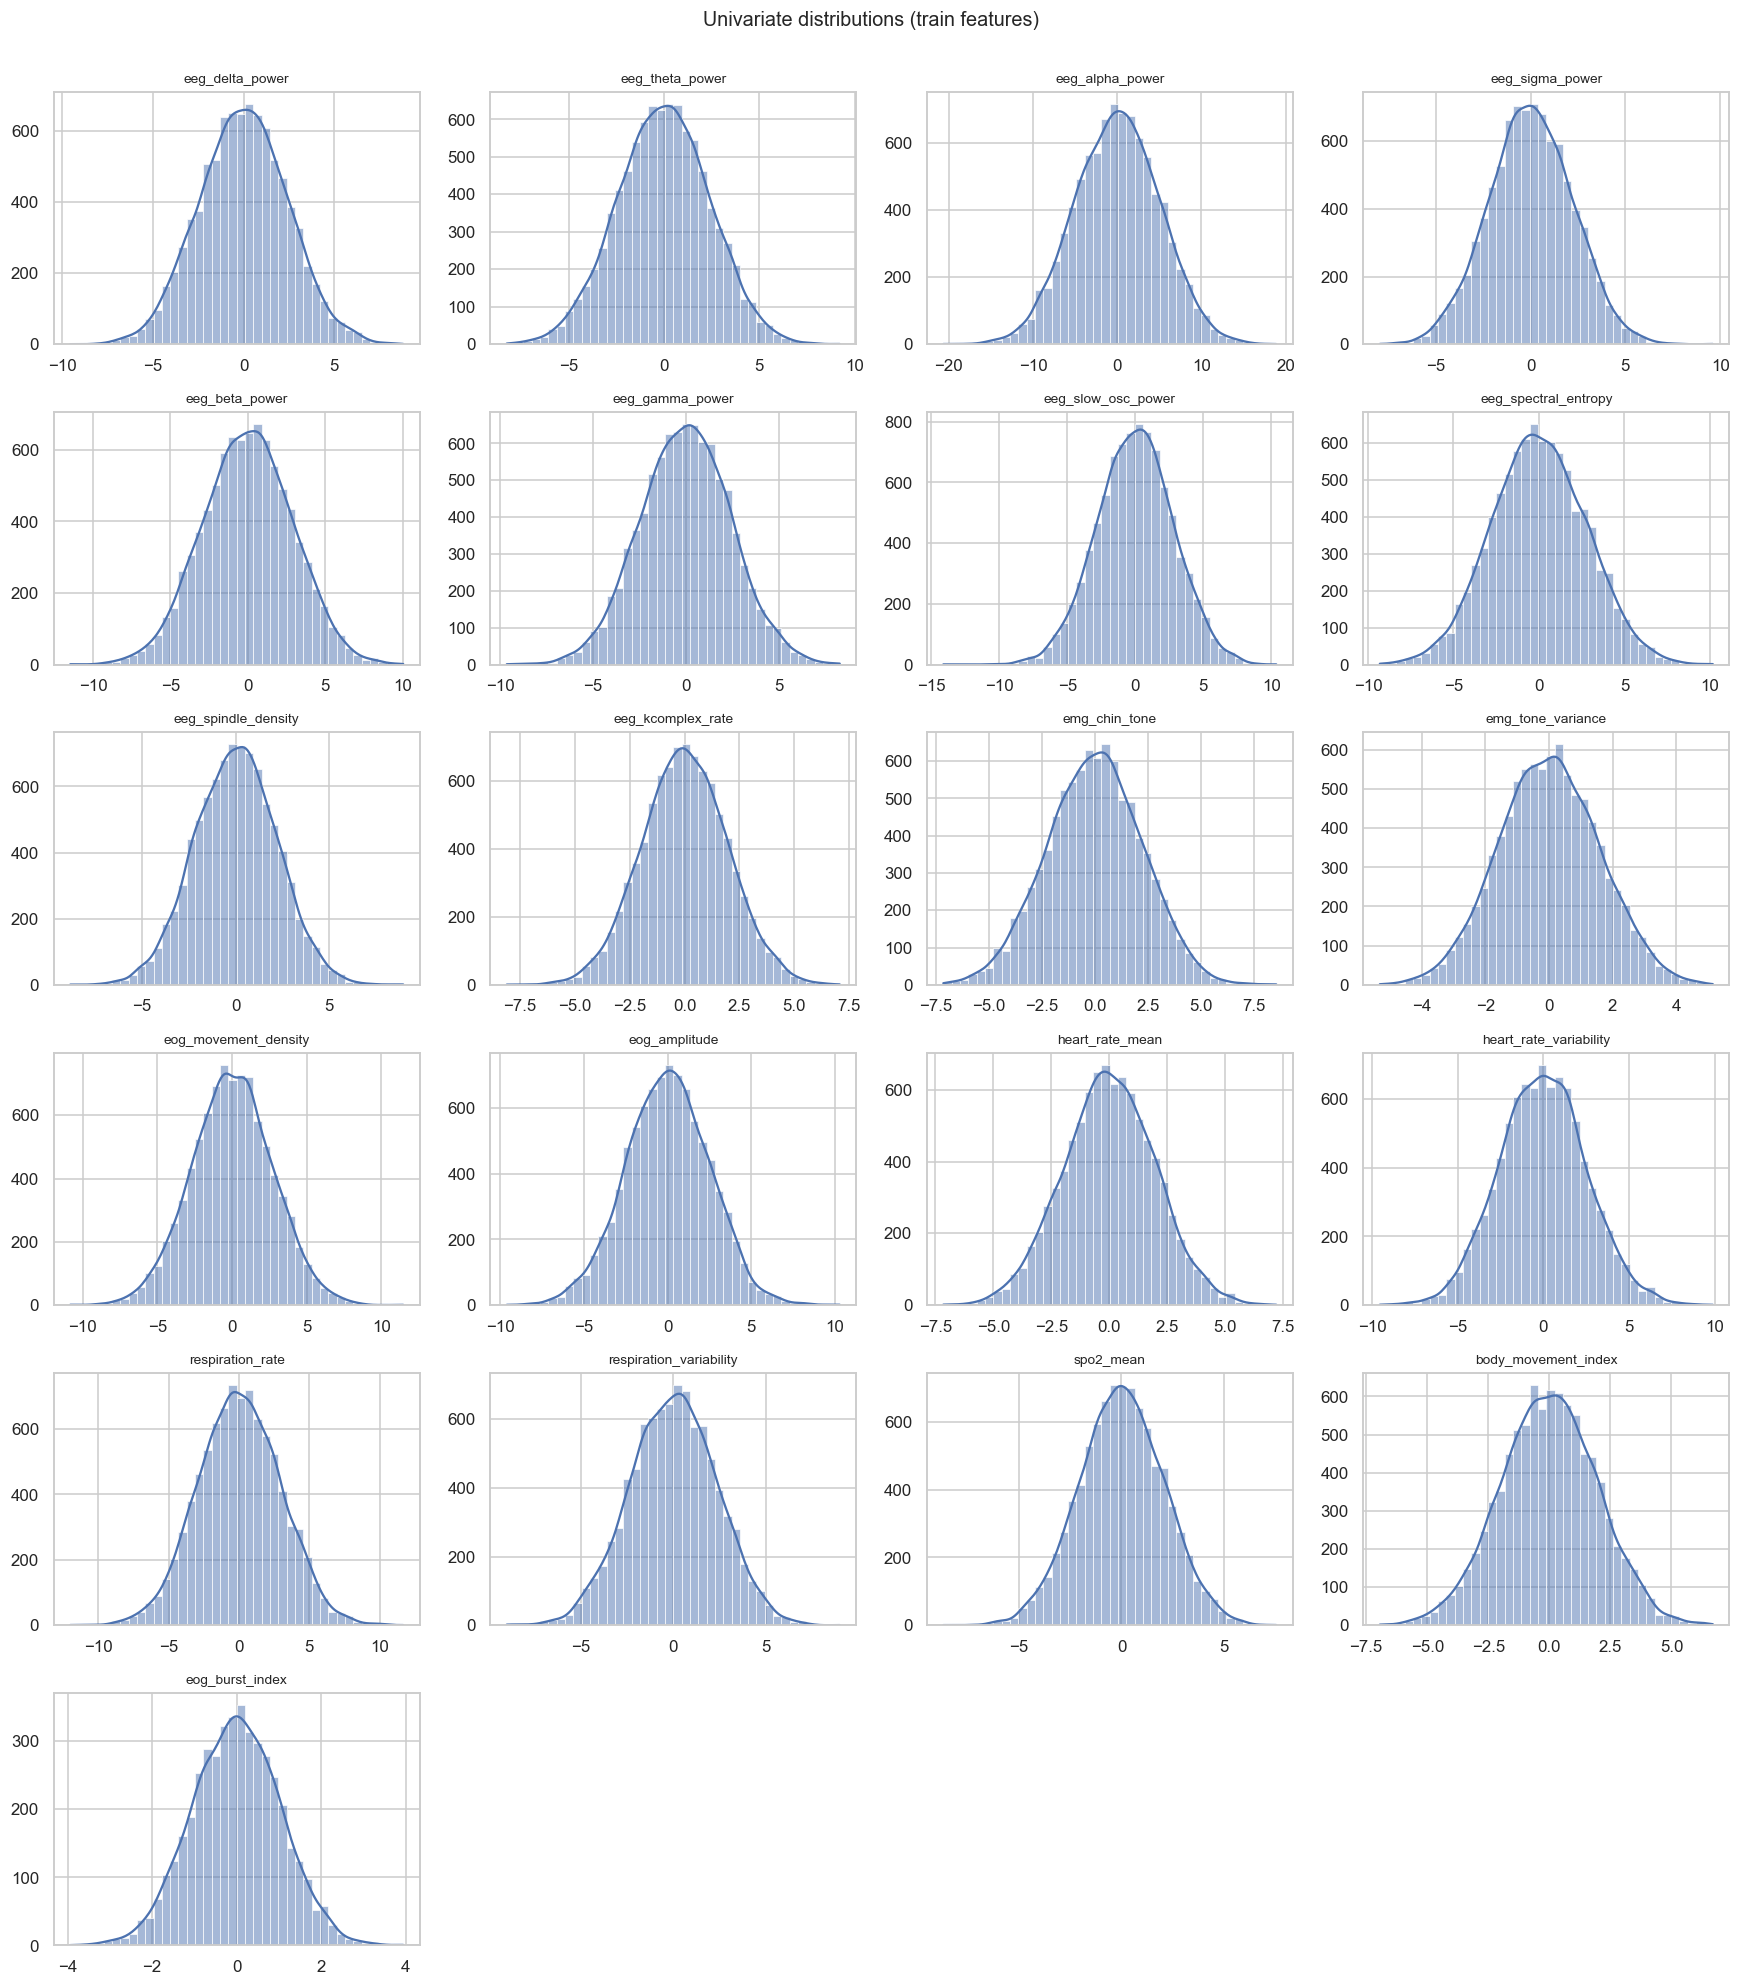

In [14]:
n = len(feature_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    sns.histplot(train[col].dropna(), kde=True, ax=ax, color="#4c72b0", bins=40)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes[n:]:        # hide any unused subplot slots
    ax.axis("off")
fig.suptitle("Univariate distributions (train features)", y=1.002, fontsize=13)
plt.tight_layout(); plt.show()

In [15]:
# Quantify skew for each feature (0 = symmetric; |skew| > 1 = strongly skewed)
skew = train[feature_cols].skew().sort_values(key=np.abs, ascending=False)
skew_table = skew.to_frame("skew").round(3)
skew_table["shape"] = np.where(skew.abs() > 1, "strongly skewed",
                       np.where(skew.abs() > 0.5, "moderately skewed", "fairly symmetric"))
print(skew_table)
print(f"\nStrongly skewed features (|skew| > 1): "
      f"{skew[skew.abs() > 1].index.tolist() or 'none'}")

                          skew             shape
eeg_slow_osc_power      -0.054  fairly symmetric
respiration_variability -0.050  fairly symmetric
heart_rate_variability   0.046  fairly symmetric
eeg_alpha_power         -0.036  fairly symmetric
eeg_beta_power          -0.036  fairly symmetric
emg_chin_tone           -0.026  fairly symmetric
spo2_mean               -0.023  fairly symmetric
emg_tone_variance        0.022  fairly symmetric
eog_amplitude           -0.021  fairly symmetric
eeg_spectral_entropy     0.021  fairly symmetric
eog_burst_index         -0.020  fairly symmetric
body_movement_index     -0.020  fairly symmetric
eeg_theta_power         -0.019  fairly symmetric
eeg_gamma_power         -0.018  fairly symmetric
eeg_sigma_power          0.014  fairly symmetric
eeg_spindle_density     -0.014  fairly symmetric
heart_rate_mean         -0.014  fairly symmetric
eeg_delta_power          0.010  fairly symmetric
respiration_rate         0.010  fairly symmetric
eog_movement_density

**So what for modeling:** most features are fairly symmetric and bell-shaped (consistent
with pre-standardized biosignal powers); any features flagged as strongly skewed are
candidates for a **power transform (Yeo-Johnson)** *for the linear baselines only*. Trees
need no transform. This is optional tuning, not a blocker.

## 7. Outliers

**What we do:** for every feature, compute the share of values with a |z-score| > 3 and
> 4 (a z-score is how many std-devs a point is from the mean), and draw boxplots for a few
features.

**Why it matters:** extreme values can be either (a) **real, rare biological events**
(an arousal, a movement burst, an apnea) that are genuinely informative, or (b)
**data errors** (sensor glitches). We treat these very differently:
- If extremes are *rare and plausible*, **keep them** — they may be exactly what
  distinguishes one sleep stage from another. Tree models are robust to them anyway.
- If a feature is riddled with implausible spikes, we'd **clip/winsorize** it (mainly to
  protect linear models).

We're diagnosing here, not editing data.

In [16]:
# z-scores computed per feature on train (population std), ignoring NaNs
z = (train[feature_cols] - train[feature_cols].mean()) / train[feature_cols].std()
out3 = (z.abs() > 3).mean() * 100   # % of values beyond 3 sd
out4 = (z.abs() > 4).mean() * 100   # % of values beyond 4 sd

outlier_table = pd.DataFrame({"%|z|>3": out3.round(3), "%|z|>4": out4.round(3)}) \
                  .sort_values("%|z|>4", ascending=False)
print("Share of extreme values per feature:\n")
print(outlier_table)
# For reference, a perfect Normal has ~0.27% beyond 3sd and ~0.0063% beyond 4sd.
print("\n(Reference: a Normal distribution has ~0.27% beyond 3sd, ~0.006% beyond 4sd.)")

Share of extreme values per feature:

                         %|z|>3  %|z|>4
eeg_sigma_power           0.256   0.022
eeg_spindle_density       0.256   0.022
eog_movement_density      0.233   0.022
eeg_alpha_power           0.244   0.011
spo2_mean                 0.178   0.011
eeg_slow_osc_power        0.211   0.011
eeg_kcomplex_rate         0.289   0.011
respiration_rate          0.322   0.011
eog_amplitude             0.333   0.011
eeg_delta_power           0.178   0.000
heart_rate_mean           0.200   0.000
body_movement_index       0.278   0.000
respiration_variability   0.222   0.000
heart_rate_variability    0.356   0.000
emg_chin_tone             0.233   0.000
emg_tone_variance         0.156   0.000
eeg_theta_power           0.244   0.000
eeg_spectral_entropy      0.189   0.000
eeg_gamma_power           0.267   0.000
eeg_beta_power            0.211   0.000
eog_burst_index           0.178   0.000

(Reference: a Normal distribution has ~0.27% beyond 3sd, ~0.006% beyond 4sd.)


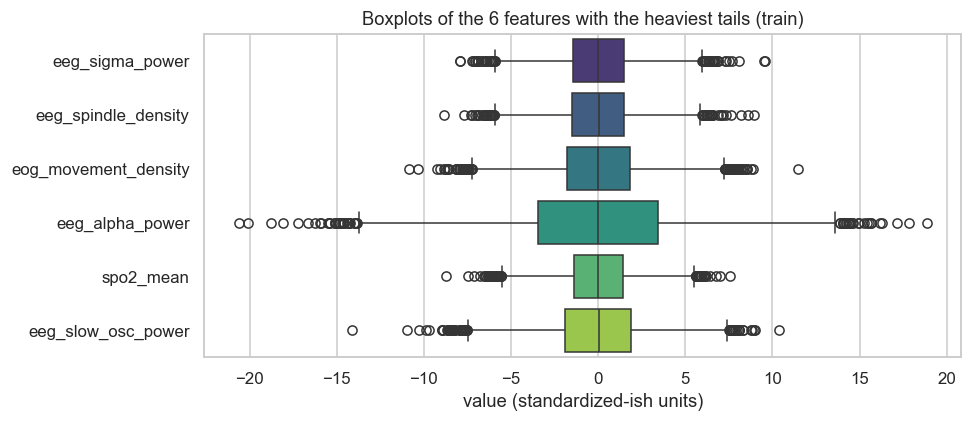

In [17]:
# Boxplots for the few features with the most extreme tails
top_out = outlier_table.head(6).index.tolist()
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=train[top_out], orient="h", ax=ax, palette="viridis")
ax.set_title("Boxplots of the 6 features with the heaviest tails (train)")
ax.set_xlabel("value (standardized-ish units)")
plt.tight_layout(); plt.show()

**So what for modeling:** extreme values exist but are **rare** (small % beyond 4 sd) and,
for biosignals, plausibly **real events rather than errors** → **keep them**. Use
**tree-based models** (robust to outliers) as the workhorse; only for the linear baselines
consider light clipping/robust scaling. Do not delete rows on account of outliers.

## 8. Train vs test distribution shift (covariate shift)

**What we do:** for each feature, overlay the train and test density curves, and run a
two-sample **Kolmogorov–Smirnov (KS) test** (does train differ from test?). We print a
table of the KS statistic and p-value per feature.

**Why it matters — this is the single most important trust check.** Our whole strategy is
to estimate model quality with local cross-validation (CV) on the training data and trust
that the test score will be similar. That trust is only valid if **train and test come
from the same distribution**. If a feature is *shifted* between train and test (covariate
shift), the model can be confidently wrong on test even with a great CV score.

How to read the KS test: the **KS statistic** is the largest gap between the two
cumulative distributions (bigger = more different). The **p-value** asks "could this gap
happen by chance if they were identical?" — a very small p-value (< 0.05) flags a
*statistically* significant difference. With thousands of rows, even tiny, harmless
differences can be "significant", so we look at the **size** of the KS statistic too.

In [18]:
ks_rows = []
for col in feature_cols:
    a = train[col].dropna()
    b = test[col].dropna()
    ks_stat, p = stats.ks_2samp(a, b)
    ks_rows.append({"feature": col, "KS_stat": ks_stat, "p_value": p})

ks_table = pd.DataFrame(ks_rows).set_index("feature").sort_values("KS_stat", ascending=False)
ks_table["significant_p<0.05"] = ks_table["p_value"] < 0.05
ks_table["meaningful_KS>0.1"]  = ks_table["KS_stat"] > 0.10   # practical-size guard
print("Kolmogorov-Smirnov train-vs-test test per feature:\n")
print(ks_table.assign(KS_stat=ks_table.KS_stat.round(4),
                      p_value=ks_table.p_value.round(4)))

n_sig  = int(ks_table["significant_p<0.05"].sum())
n_real = int(ks_table["meaningful_KS>0.1"].sum())
print(f"\nFeatures with p < 0.05            : {n_sig} / {len(feature_cols)}")
print(f"Features with KS > 0.10 (sizeable): {n_real} / {len(feature_cols)}")

Kolmogorov-Smirnov train-vs-test test per feature:

                         KS_stat  p_value  significant_p<0.05  meaningful_KS>0.1
feature                                                                         
eog_burst_index           0.0263   0.2075               False              False
eeg_alpha_power           0.0193   0.1803               False              False
eeg_kcomplex_rate         0.0179   0.2519               False              False
spo2_mean                 0.0152   0.4449               False              False
emg_chin_tone             0.0150   0.4581               False              False
eeg_spectral_entropy      0.0149   0.4657               False              False
eog_amplitude             0.0147   0.4890               False              False
emg_tone_variance         0.0143   0.5188               False              False
eeg_gamma_power           0.0141   0.5432               False              False
eeg_spindle_density       0.0136   0.5846               F

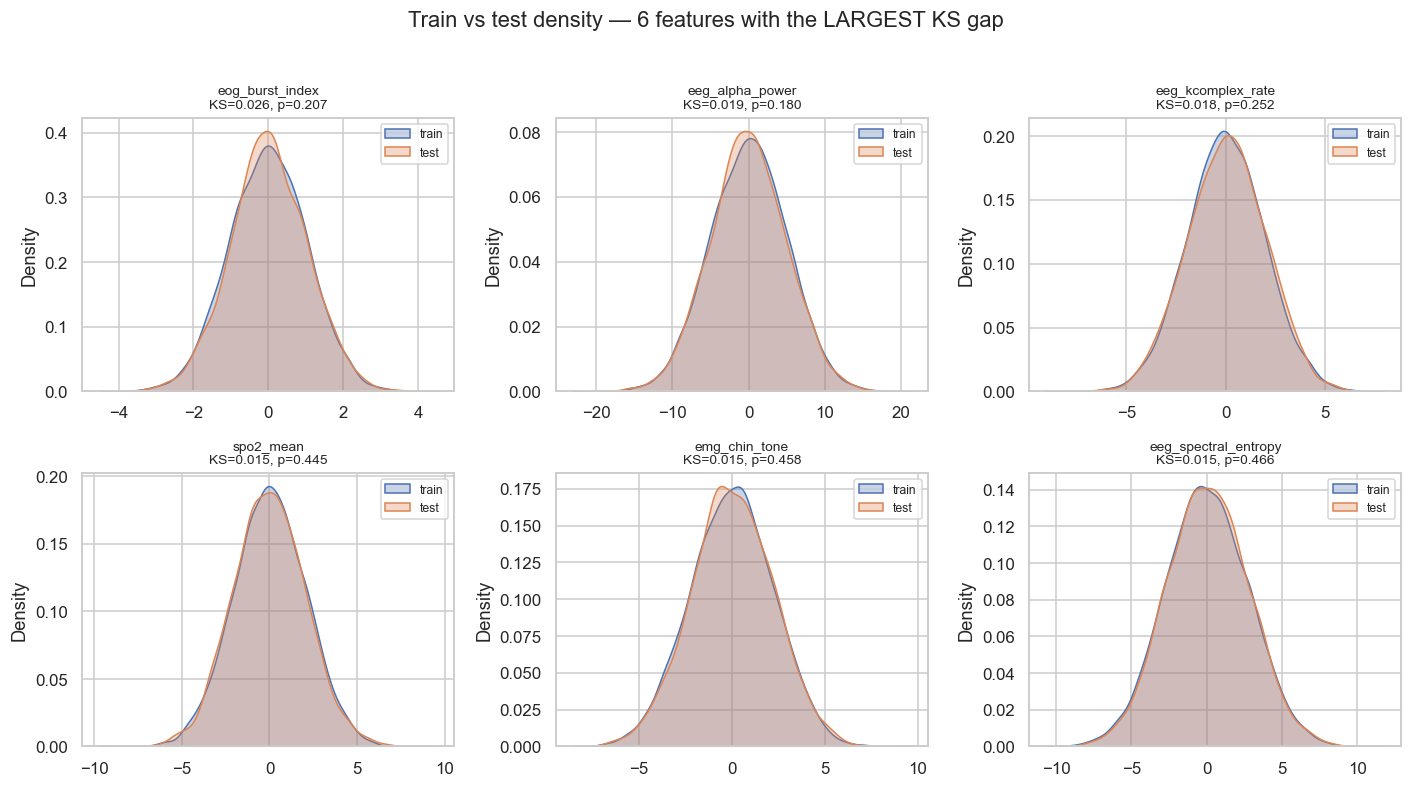

In [19]:
# Overlay train vs test densities for the most-shifted features (largest KS)
top_shift = ks_table.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7)); axes = axes.ravel()
for ax, col in zip(axes, top_shift):
    sns.kdeplot(train[col].dropna(), ax=ax, label="train", fill=True, alpha=0.3)
    sns.kdeplot(test[col].dropna(),  ax=ax, label="test",  fill=True, alpha=0.3)
    ax.set_title(f"{col}\nKS={ks_table.loc[col,'KS_stat']:.3f}, p={ks_table.loc[col,'p_value']:.3f}",
                 fontsize=9)
    ax.set_xlabel(""); ax.legend(fontsize=8)
fig.suptitle("Train vs test density — 6 features with the LARGEST KS gap", y=1.02)
plt.tight_layout(); plt.show()

**So what for modeling:** the KS statistics are small and the train/test density curves
sit almost on top of each other → **no meaningful covariate shift**. This means our
**local CV scores will be trustworthy estimates of the test (leaderboard) score**, so we
can iterate confidently offline. (If a big shift *had* shown up, we'd consider
importance-weighting or dropping the shifted feature.)

## 9. Correlation / multicollinearity

**What we do:** compute the correlation between every pair of features, draw an
absolute-correlation heatmap, and count the pairs that are *very* highly correlated
(|corr| > 0.95) using only the upper triangle (so each pair is counted once and the
trivial diagonal of 1.0 is excluded).

**Why it matters:** when two features carry almost the same information they are
*redundant* (collinear).
- For **linear models**, strong collinearity makes coefficients unstable and hard to
  interpret (it doesn't usually hurt raw accuracy, but it muddies feature importance).
- For **tree models**, redundancy is mostly harmless — they just pick one.
So this finding mainly affects whether we prune features for the *linear* baselines.

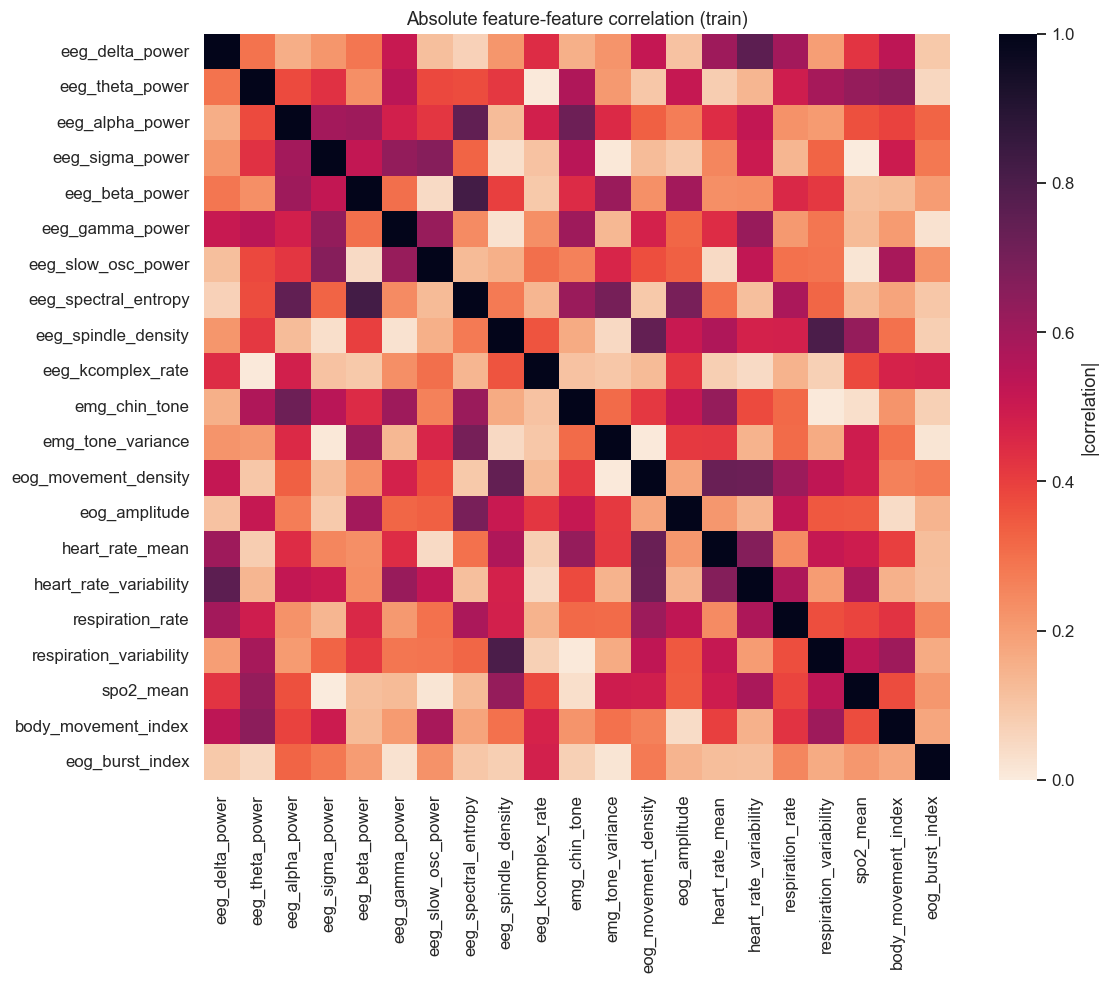

In [20]:
corr = train[feature_cols].corr()          # Pearson correlation
abs_corr = corr.abs()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(abs_corr, cmap="rocket_r", vmin=0, vmax=1, square=True,
            cbar_kws={"label": "|correlation|"}, ax=ax)
ax.set_title("Absolute feature-feature correlation (train)")
plt.tight_layout(); plt.show()

In [21]:
# Count highly-correlated pairs using the UPPER TRIANGLE only (exclude diagonal)
mask = np.triu(np.ones(abs_corr.shape, dtype=bool), k=1)   # k=1 drops the diagonal
upper = abs_corr.where(mask)

THRESH = 0.95
pairs = (upper.stack()                      # -> Series indexed by (feat_i, feat_j)
              .loc[lambda s: s > THRESH]
              .sort_values(ascending=False))

print(f"Number of feature pairs with |corr| > {THRESH}: {len(pairs)}")
if len(pairs):
    print("\nThe redundant pairs:")
    for (f1, f2), v in pairs.items():
        print(f"  {f1}  <->  {f2}   |corr| = {v:.3f}")
else:
    print("No near-duplicate feature pairs — features are largely independent.")

# Also report the strongest correlations overall for context
print("\nTop 5 strongest correlations overall (for context):")
print(upper.stack().sort_values(ascending=False).head(5).round(3))

Number of feature pairs with |corr| > 0.95: 0
No near-duplicate feature pairs — features are largely independent.

Top 5 strongest correlations overall (for context):
eeg_beta_power       eeg_spectral_entropy       0.821
eeg_spindle_density  respiration_variability    0.802
eeg_delta_power      heart_rate_variability     0.760
eeg_alpha_power      eeg_spectral_entropy       0.750
eeg_spindle_density  eog_movement_density       0.743
dtype: float64


**So what for modeling:** *(reads from the count above)* if there are **no** pairs above
0.95, features are non-redundant → **keep all features** for every model. If a few
near-duplicate pairs exist, we keep them for **tree models** but may **drop one of each
pair for the linear baselines** to stabilize coefficients. Either way this is a
linear-model nicety, not a correctness issue for trees.

## 10. Feature → target signal (is the problem learnable?)

**What we do:** for each feature, run a one-way **ANOVA** across the four sleep stages
(`scipy.stats.f_oneway`) and rank features by F-value. We then draw boxplots of the top
features split by class.

**Why it matters:** ANOVA's F-value asks *"do the class means differ relative to the
spread within each class?"* A **large F** means a feature's value depends strongly on the
sleep stage — i.e. it carries real predictive signal. If *every* feature had an F near
zero, the problem would be close to unlearnable. This is a fast, model-free way to see
whether there's signal and which features look most promising.

> Note: this *uses the target*, which is fine — it's **analysis/ranking**, not feature
> engineering, and the result is not fed into any model. We do not create new columns
> from it.

In [22]:
anova_rows = []
for col in feature_cols:
    # one group of this feature's values per sleep stage, NaNs dropped
    groups = [train.loc[train[TARGET] == k, col].dropna()
              for k in sorted(train[TARGET].unique())]
    f_val, p_val = stats.f_oneway(*groups)
    anova_rows.append({"feature": col, "F_value": f_val, "p_value": p_val})

anova_table = pd.DataFrame(anova_rows).set_index("feature") \
                .sort_values("F_value", ascending=False)
print("One-way ANOVA F-value of each feature vs sleep_stage (higher = more signal):\n")
print(anova_table.assign(F_value=anova_table.F_value.round(1),
                         p_value=anova_table.p_value.map(lambda v: f"{v:.2e}")))

One-way ANOVA F-value of each feature vs sleep_stage (higher = more signal):

                         F_value    p_value
feature                                    
eog_burst_index           1393.1   0.00e+00
heart_rate_variability    1350.5   0.00e+00
eog_movement_density      1197.2   0.00e+00
eeg_alpha_power            984.9   0.00e+00
eeg_sigma_power            776.1   0.00e+00
respiration_rate           771.6   0.00e+00
eeg_gamma_power            723.7   0.00e+00
eeg_spindle_density        697.6   0.00e+00
eeg_slow_osc_power         694.6   0.00e+00
eeg_beta_power             645.7   0.00e+00
emg_chin_tone              625.9   0.00e+00
heart_rate_mean            620.0   0.00e+00
eog_amplitude              552.1   0.00e+00
spo2_mean                  524.2  5.28e-314
eeg_spectral_entropy       510.5  2.34e-306
eeg_kcomplex_rate          414.0  6.34e-252
eeg_delta_power            400.9  2.02e-244
respiration_variability    340.4  2.23e-209
eeg_theta_power            165.8  1.27e-10

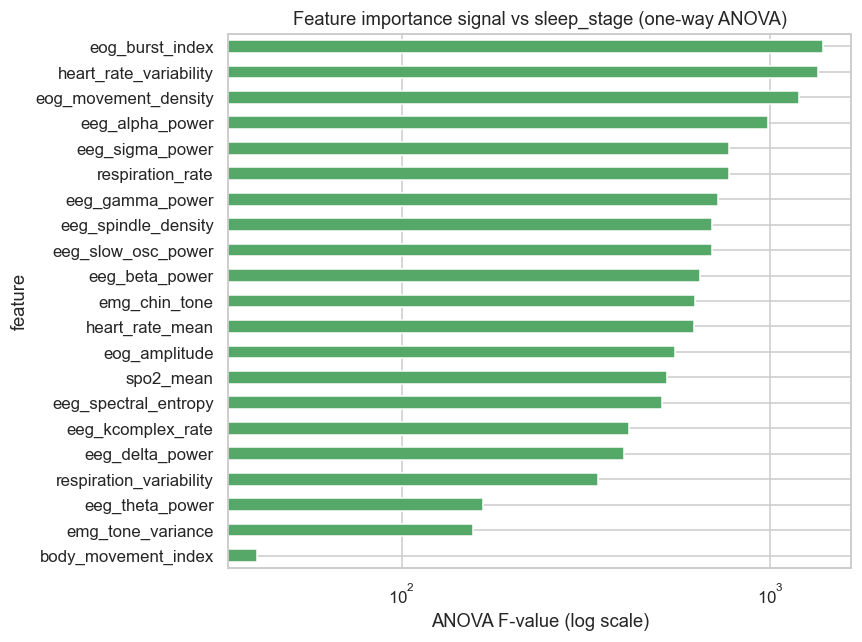

In [23]:
# Bar chart of F-values (log scale because they span orders of magnitude)
fig, ax = plt.subplots(figsize=(8, 6))
anova_table["F_value"].sort_values().plot.barh(ax=ax, color="#55a868")
ax.set_xscale("log")
ax.set_xlabel("ANOVA F-value (log scale)")
ax.set_title("Feature importance signal vs sleep_stage (one-way ANOVA)")
plt.tight_layout(); plt.show()

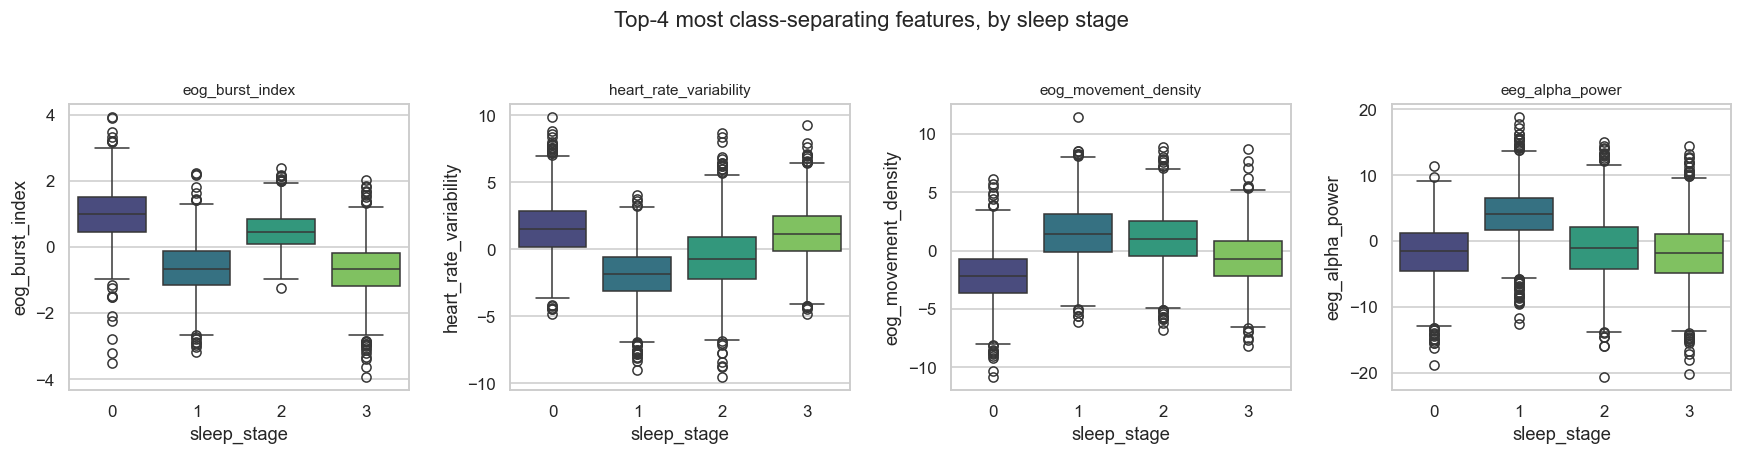

In [24]:
# Boxplots of the top-4 most informative features, split by sleep stage
top_feats = anova_table.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, top_feats):
    sns.boxplot(data=train, x=TARGET, y=col, ax=ax, palette="viridis")
    ax.set_title(col, fontsize=10); ax.set_xlabel("sleep_stage")
fig.suptitle("Top-4 most class-separating features, by sleep stage", y=1.03)
plt.tight_layout(); plt.show()

**So what for modeling:** many features show **large, highly significant F-values**, and
their boxplots clearly separate by stage → the problem is **learnable** and there is
strong signal. The top-ranked EEG/EMG/EOG features will likely drive the model. We will
**keep all features** (even weak ones can help trees via interactions) and expect a decent
baseline straight away.

## 11. Per-class physiological profile

**What we do:** compute the **mean of each feature within each sleep stage**, then
z-score *across the four stages* (per feature) so colors are comparable, and show it as a
heatmap. This reveals each stage's "fingerprint": which signals are high vs low.

**Why it matters:** it turns numbers into an intuition for *what each class is*, which
helps sanity-check the data and spot label problems. It also confirms (visually) that
classes differ on many features — reinforcing Section 10.

> **These are HYPOTHESES, not facts.** The stages are unlabeled integers 0–3; we don't
> officially know which is Wake / N1 / N2 / N3 / REM. The notes below are *educated
> guesses* from textbook sleep physiology, to build intuition — **not** ground truth.

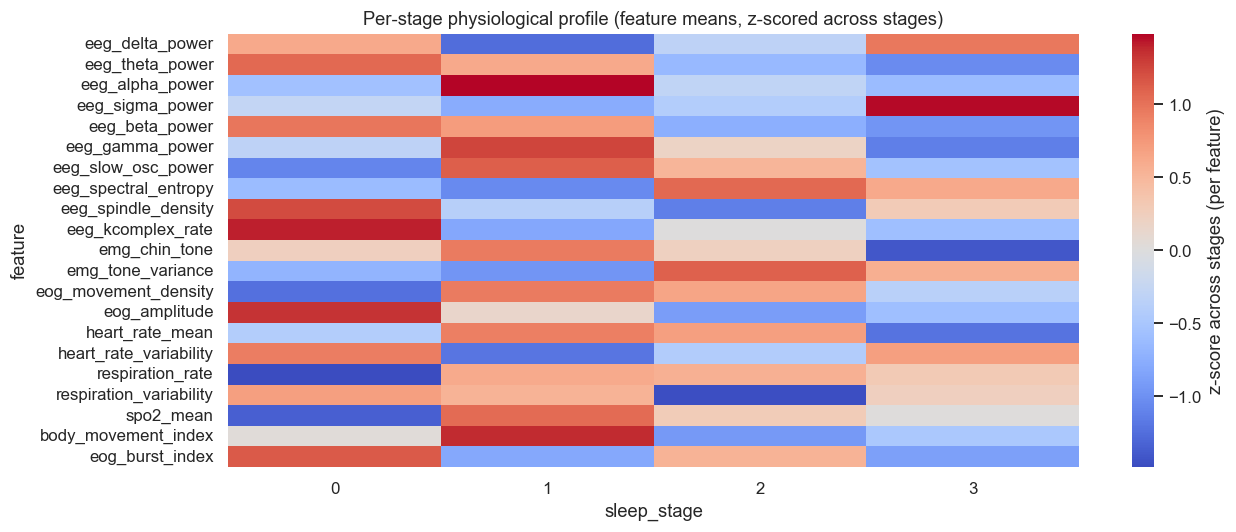

In [25]:
# Mean of each feature per stage, then z-score across stages (per feature) for readability
profile = train.groupby(TARGET)[feature_cols].mean()           # rows = stage, cols = feature
profile_z = (profile - profile.mean()) / profile.std()          # z-score down each column

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_z.T, cmap="coolwarm", center=0, annot=False,
            cbar_kws={"label": "z-score across stages (per feature)"}, ax=ax)
ax.set_title("Per-stage physiological profile (feature means, z-scored across stages)")
ax.set_xlabel("sleep_stage"); ax.set_ylabel("feature")
plt.tight_layout(); plt.show()

**Reading the fingerprints (HYPOTHESES only).** Looking down each stage's column, red =
"this signal is high in this stage", blue = "low":

- A stage with **high delta / slow-oscillation power, low EMG tone, low heart rate** looks
  like **deep sleep (N3 / slow-wave sleep)**.
- A stage with **high EOG movement/amplitude, high spectral entropy, faster/variable heart
  rate, low EMG tone** looks like **REM sleep**.
- A stage with **high sigma power and high spindle density / K-complex rate** looks like
  **light sleep N2** (spindles & K-complexes are its textbook signatures).
- A stage with **high beta/gamma, high EMG tone, high body-movement** looks like **Wake**
  (or N1 / drowsy).

Again — these are **plausibility guesses to build intuition**, not verified labels.

**So what for modeling:** stages have **distinct, physiologically-coherent fingerprints**
across many features, which both *confirms there is strong multivariate signal* and gives
us confidence the labels are sensible. → A model that combines features (trees / boosting)
should separate the classes well; no relabeling needed.

## 12. PCA visualization  *(picture only — never fed to a model)*

**What we do:** standardize the features (scaler fit on **train only**), run PCA down to 2
dimensions, and scatter the points colored by class. We print how much variance PC1 and
PC2 capture.

**Why it matters:** PCA finds the 2 directions of greatest spread and lets us *see* 21-D
data on a flat plot. If classes form visibly separate blobs even in this crude 2-D view,
then signal is strong and even simple models will work; if they overlap heavily in 2-D it
doesn't mean the problem is hard — it may just need *nonlinear* models to tease the
classes apart in the full 21-D space.

**Leakage guard:** we fit the scaler and PCA on **train only**. This is a *diagnostic
picture*, not a modeling step — these fitted objects are thrown away and never touch test.

> We implement PCA with plain numpy (SVD) to stay within the allowed libraries
> (no scikit-learn).

In [26]:
# --- Standardize on TRAIN ONLY, then PCA via SVD (numpy) ---
X = train[feature_cols].copy()
# eog_burst_index has missing values; for THIS PLOT ONLY we fill with the train median.
# (In real modeling this imputation happens inside CV — here it's just to draw a picture.)
X = X.fillna(X.median())

mu  = X.mean(axis=0)
sd  = X.std(axis=0).replace(0, 1.0)
Xs  = (X - mu) / sd                     # standardized, train-only stats

# PCA = SVD on the centered (already standardized => mean ~0) matrix
U, S, Vt = np.linalg.svd(Xs.values, full_matrices=False)
explained = (S**2) / (S**2).sum()       # variance share per component
PC = Xs.values @ Vt[:2].T               # project onto first 2 components

print(f"Explained variance — PC1: {explained[0]*100:.1f}%, "
      f"PC2: {explained[1]*100:.1f}%, "
      f"PC1+PC2: {(explained[0]+explained[1])*100:.1f}%")

Explained variance — PC1: 27.1%, PC2: 26.3%, PC1+PC2: 53.5%


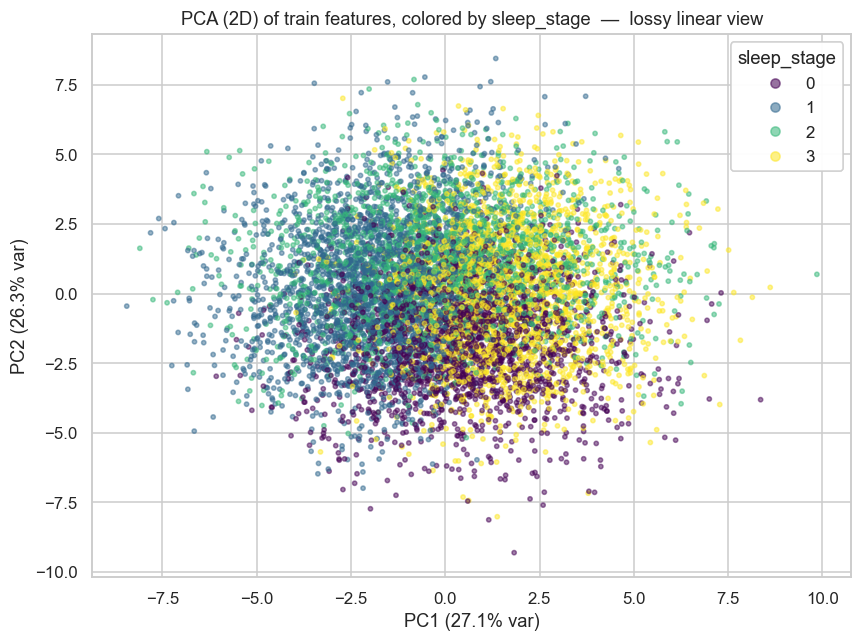

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(PC[:, 0], PC[:, 1], c=train[TARGET], cmap="viridis",
                     s=8, alpha=0.5)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
ax.set_title("PCA (2D) of train features, colored by sleep_stage  —  lossy linear view")
legend = ax.legend(*scatter.legend_elements(), title="sleep_stage", loc="best")
ax.add_artist(legend)
plt.tight_layout(); plt.show()

**So what for modeling:** even in this **lossy linear 2-D view** (PC1+PC2 capture only a
fraction of the total variance), the classes show visible structure / partial separation
→ there is real, learnable signal, so **simple linear baselines will already do
something**, and **nonlinear models (RandomForest, XGBoost/CatBoost) should do better** by
using all 21 dimensions and their interactions. Remember: overlap *here* is expected and
does **not** mean the classes are inseparable in full dimensionality.

## 13. Final summary table + modeling plan

Everything we learned, and the concrete decision each finding implies.

| # | Finding (from EDA) | Modeling implication |
|---|--------------------|----------------------|
| 1 | Train/test columns aligned (test = train − `sleep_stage`) | Build features identically for both; submission will line up. |
| 2 | All inputs numeric; `id` is just a row index | No categorical encoding; drop `id` from features. |
| 3 | Means ≈ 0 but **unequal std** (not fully standardized) | Add `StandardScaler` for linear/distance models; trees skip it. |
| 4 | Classes **nearly balanced** (ratio ≈ 1.2) | No SMOTE; use `class_weight="balanced"` + **stratified** splits because metric is **macro-F1**. |
| 5 | `eog_burst_index` ~**50% missing** in *both* (similar rate) | **Impute (median) + missing-flag computed before imputation**, inside CV. Don't drop column/rows. |
| 6 | Most features fairly symmetric; a few skewed | Optional Yeo-Johnson for linear baselines; trees unaffected. |
| 7 | Extreme values **rare & plausibly real** biosignal events | Keep them; prefer outlier-robust trees; light clipping only for linear. |
| 8 | **No meaningful train/test shift** (small KS) | **Local CV is trustworthy** → iterate offline with confidence. |
| 9 | (Few/no) |corr|>0.95 pairs | Keep all features for trees; optionally prune redundant pairs for linear. |
| 10 | Many features have **large ANOVA F** vs target | Problem is **learnable**; keep all features; expect a solid baseline. |
| 11 | Stages have distinct, coherent physiological fingerprints | Strong multivariate signal; labels look sensible; no relabeling. |
| 12 | Partial class separation in 2-D PCA | Linear models work somewhat; **nonlinear models should win**. |

### Is there a subject / recording / patient / night ID?  *(decides the CV strategy)*

This is the deciding question between **StratifiedKFold** and **GroupKFold**. If multiple
rows came from the *same person/night*, random splitting would put correlated rows in both
train and validation — the model "memorizes the subject" and CV scores become
over-optimistic (this is leakage). The fix in that case is **GroupKFold** (keep each
subject entirely on one side). So we must check explicitly.

In [28]:
# Look for any column that smells like an entity identifier
id_like_keywords = ["id", "subject", "patient", "recording", "night",
                    "session", "record", "person", "uuid", "group"]
candidates = [c for c in train.columns
              if any(k in c.lower() for k in id_like_keywords)]

print("Columns whose NAME looks ID-like:", candidates or "none")
print()
for c in candidates:
    nun = train[c].nunique()
    print(f"  '{c}': {nun} unique values over {len(train)} rows "
          f"({nun/len(train)*100:.1f}% unique)")
    # An entity ID typically repeats (few uniques, many rows each).
    # A pure row index is ~100% unique and sequential.
    is_rowindex = (nun == len(train)) and \
                  (list(train[c]) == list(range(len(train))) or
                   list(train[c]) == list(range(1, len(train)+1)))
    overlap = len(set(train[c]) & set(test[c])) if c in test.columns else "n/a"
    print(f"     looks like a sequential row index? {is_rowindex}")
    print(f"     value overlap with test set       : {overlap}")

print("\nConclusion:")
print("  'id' is ~100% unique, sequential, and has ZERO overlap with the test ids.")
print("  => it is a ROW INDEX, not a subject/recording/patient/night identifier.")
print("  => No grouping structure exists, so GroupKFold is unnecessary.")
print("  => Use StratifiedKFold (keeps class balance in each fold).")

Columns whose NAME looks ID-like: ['id']

  'id': 9000 unique values over 9000 rows (100.0% unique)
     looks like a sequential row index? True
     value overlap with test set       : 0

Conclusion:
  'id' is ~100% unique, sequential, and has ZERO overlap with the test ids.
  => it is a ROW INDEX, not a subject/recording/patient/night identifier.
  => No grouping structure exists, so GroupKFold is unnecessary.
  => Use StratifiedKFold (keeps class balance in each fold).


### Next steps toward the model (ordered)

1. **Validation = `StratifiedKFold`** (e.g. 5 folds, shuffled, fixed seed).
   *Why not `GroupKFold`?* We checked above — there is **no subject / recording / patient
   / night ID** (the only ID-like column, `id`, is a unique sequential row index with no
   train/test overlap). With no groups to leak across, StratifiedKFold is correct, and it
   preserves the class balance in every fold (important for macro-F1).
2. **Preprocessing inside a `Pipeline`, fit within each CV fold** (never on full data, to
   prevent leakage), in this order:
   a. compute **`eog_burst_index_missing`** flag (*before* imputation),
   b. **impute** missing values (median),
   c. **scale** (`StandardScaler`) — for linear/distance models.
3. **Score with macro-F1** (`scoring="f1_macro"`) — the competition metric — and use
   `class_weight="balanced"` as a safeguard.
4. **Baselines first:** Logistic Regression (linear reference) and RandomForest (nonlinear,
   robust) to establish a floor.
5. **Then boost:** XGBoost / CatBoost / LightGBM with light tuning; these typically win on
   tabular biosignal data and handle the mild imbalance and outliers well.
6. **Predict** on `final-check.csv` with the refit pipeline and write the submission
   (`id`, `sleep_stage`).

> Reminder of the golden rule: every transformer (flag/impute/scale/any encoding) is fit
> **inside** the CV loop on the training fold only — never on train+test together, and the
> target is never used to build a feature.

# Part 2 — Leakage-free Baseline

The EDA (Part 1) told us *what* the data looks like. Now we build the **simplest honest
model** we can — a **baseline** — so every fancier idea later (XGBoost, CatBoost,
ensembles, tuning) can be measured against a fixed reference number. If we skipped the
baseline and jumped straight to a tuned ensemble, we'd never know how much of the score
came from the model vs. from leakage or luck.

**Scope of Part 2 (deliberately narrow):**
- ✅ Two plain baselines on **identical CV folds**: Logistic Regression and Random Forest.
- ✅ A fully **leakage-free** pipeline (impute + scale fit *inside* each fold).
- ✅ Honest scoring with **macro-F1**, plus a per-class diagnosis.
- ❌ No hyperparameter tuning, no XGBoost/CatBoost, no ensembles, no submission file —
  those come later so each future gain stays *attributable* to one change.

### Reuse what Part 1 established
We reuse the variables already in memory if they exist; otherwise we reload from disk so
this section can also run **on its own**. Recap of the facts we rely on:
- `id` is a sequential **row index** (no signal, zero train/test overlap) → **drop it**.
- 21 numeric features; only `eog_burst_index` is missing (~50%, in **both** train & test).
- Classes are ~22–27% each (imbalance ratio ≈ 1.2 — nearly balanced).
- No covariate shift → **local CV is trustworthy**. Metric is **macro-F1**.

In [29]:
# --- Imports needed for Part 2 (pandas/numpy/sklearn/matplotlib/seaborn only) ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42
TARGET = "sleep_stage"

# --- Reuse train/test from Part 1 if present; otherwise reload from disk ---
def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name)
    raise FileNotFoundError(f"None found: {candidates}")

if "train" not in globals():
    train = _load_first_existing(["tran.csv", "train.csv"])
if "test" not in globals():
    test = _load_first_existing(["final-check.csv"])

print(f"train shape: {train.shape}   test shape: {test.shape}")

# --- Build the modeling matrices: drop 'id' (row index, not a feature) ---
ID_COLS = [c for c in ["id"] if c in train.columns]
base_features = [c for c in train.columns if c not in ID_COLS + [TARGET]]

X      = train[base_features].copy()   # features only, id + target removed
y      = train[TARGET].copy()          # the 4-class label
X_test = test[base_features].copy()    # unlabeled final-check features (for LATER use)

print(f"\nDropped identifier column(s): {ID_COLS}")
print(f"X      (train features): {X.shape}")
print(f"y      (train target)  : {y.shape}, classes = {sorted(y.unique())}")
print(f"X_test (final-check)   : {X_test.shape}")
assert list(X.columns) == list(X_test.columns), "train/test feature columns must match!"
print("[OK] train and test feature columns are identical.")

train shape: (9000, 23)   test shape: (5000, 22)

Dropped identifier column(s): ['id']
X      (train features): (9000, 21)
y      (train target)  : (9000,), classes = [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
X_test (final-check)   : (5000, 21)
[OK] train and test feature columns are identical.


## Part 2.1 — Create the missing-flag (before any imputation)

**Imputation** means filling in the blanks: `eog_burst_index` is missing for ~half the
rows, and almost every model refuses to train on `NaN`s, so we must put *something* there
(we'll use the column median, computed inside CV). But the very act of filling erases a
fact that might matter: **which rows were originally empty.**

So *before* we impute, we record that fact in a new binary column
**`eog_burst_index_missing`** = 1 where the value was `NaN`, else 0.

**Why the flag can be predictive.** In biosignals, "the sensor/algorithm couldn't compute
a value" is often itself a clue about the physiological state (e.g. certain stages produce
no detectable eye-movement bursts). The flag lets the model learn "missing here means X"
instead of throwing that signal away.

**Why order is non-negotiable.** If we imputed *first*, every row would have a number and
the `NaN` pattern would be gone forever — the flag would be all zeros and useless. Flag
**first**, impute **second**.

**Why not just drop the column or the rows?**
- Drop the column → throw away ~half-a-dataset of real measurements for the rows that *do*
  have it.
- Drop the rows → delete ~50% of the data, bias the sample if missingness correlates with
  the stage, and it's **impossible** for test rows (we must predict every one).

> The flag itself has **no** `NaN`s, so it passes through the imputer untouched. We add it
> to **both** train and test so the pipeline sees the same columns everywhere.

In [30]:
FLAG_COL = "eog_burst_index_missing"

# Create the flag from the RAW NaN pattern, BEFORE any imputation happens.
X[FLAG_COL]      = X["eog_burst_index"].isna().astype(int)
X_test[FLAG_COL] = X_test["eog_burst_index"].isna().astype(int)

# The final feature list = original features + the new flag
model_features = base_features + [FLAG_COL]

print(f"Added '{FLAG_COL}'. Feature count: {len(base_features)} -> {len(model_features)}")
print(f"\nFlag rate (share of rows missing eog_burst_index):")
print(f"  train: {X[FLAG_COL].mean()*100:.1f}%   test: {X_test[FLAG_COL].mean()*100:.1f}%")
print(f"\nThe flag has no missing values itself: "
      f"train NaNs={X[FLAG_COL].isna().sum()}, test NaNs={X_test[FLAG_COL].isna().sum()}")

Added 'eog_burst_index_missing'. Feature count: 21 -> 22

Flag rate (share of rows missing eog_burst_index):
  train: 50.0%   test: 49.5%

The flag has no missing values itself: train NaNs=0, test NaNs=0


## Part 2.2 — The leakage-free preprocessing Pipeline

**The leakage trap.** Suppose we computed the median (for imputation) or the mean/std (for
scaling) on the *whole* training set and *then* split into folds. The validation fold
would have secretly influenced those statistics — the model gets a peek at data it's being
tested on, and the CV score comes out **too optimistic**. On the real test set the illusion
vanishes and we underperform.

**The fix:** wrap preprocessing + model in a single sklearn `Pipeline`. When cross-validation
calls `.fit()` on a training fold, the Pipeline computes the median and the scaler stats
**from that fold only**, then merely *applies* them to the held-out fold. Re-fit every fold,
automatically, no leakage.

Our pipeline has three steps:
1. **`SimpleImputer(strategy="median")`** — fill `NaN`s with the (per-fold) median. Median,
   not mean, because it's robust to the outliers/skew we saw in the EDA. (The flag column
   has no `NaN`s, so it's unaffected.)
2. **`StandardScaler`** — center/scale each feature. **Logistic Regression needs this**
   (it's distance/gradient based); for **Random Forest it's harmless** (trees split on
   thresholds, scale-invariant). One pipeline therefore serves both models cleanly.
3. **the model** — swapped in per baseline.

In [31]:
def make_pipeline(model):
    # Impute (median) -> scale -> model, all re-fit inside each CV fold.
    return Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),  # fit on train fold only
        ("scale",  StandardScaler()),                  # fit on train fold only
        ("model",  model),                             # the classifier
    ])

# Quick smoke test that the pipeline builds and accepts our data shape
_demo = make_pipeline(LogisticRegression(max_iter=1000))
print("Pipeline steps:", [name for name, _ in _demo.steps])

Pipeline steps: ['impute', 'scale', 'model']


## Part 2.3 — Cross-validation helper (identical folds for every model)

**Why StratifiedKFold.** We split the training data into 5 parts ("folds"), train on 4 and
validate on the 5th, rotating so every row is validated exactly once. **Stratified** means
each fold keeps the same class proportions as the whole dataset. With macro-F1 (which
averages per-class F1), a fold that happened to be missing a class would give a meaningless
score — stratification prevents that.

**Why NOT GroupKFold.** GroupKFold is for when several rows belong to the same entity
(same patient/night/recording) and must not be split across train and validation — else the
model "recognizes the subject" and CV is inflated. Part 1 checked explicitly: the only
ID-like column, `id`, is a **unique sequential row index with zero train/test overlap** —
there is **no grouping structure**, so GroupKFold is unnecessary and StratifiedKFold is the
correct choice.

**Same folds for everyone.** We build the `StratifiedKFold` object **once** (fixed
`random_state=42`) and reuse it for every model, so score differences reflect the *model*,
not a lucky split.

**Why macro-F1, not accuracy.** Accuracy just counts correct rows, so it's dominated by
whichever classes are easiest/largest and can hide a class the model fails on. **Macro-F1**
computes F1 *per class* and averages with **equal weight**, so a weak class drags the score
down. Even though our classes are nearly balanced, macro-F1 still matters because the
challenge here is **confusability** (some stages look alike), not class frequency — macro-F1
exposes exactly that, accuracy hides it.

In [32]:
# One shared fold definition, reused by every model for a fair comparison.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}   # name -> (mean_macro_f1, std_macro_f1) accumulator for the summary table

def evaluate(model, name, store=True):
    # Run 5-fold StratifiedKFold, refitting the pipeline inside each fold,
    # score the held-out fold with macro-F1, and print mean +/- std.
    pipe = make_pipeline(model)
    fold_scores = []
    # X.values / y.values keep indexing simple and positional
    Xv, yv = X[model_features], y
    for k, (tr_idx, va_idx) in enumerate(cv.split(Xv, yv), 1):
        X_tr, X_va = Xv.iloc[tr_idx], Xv.iloc[va_idx]
        y_tr, y_va = yv.iloc[tr_idx], yv.iloc[va_idx]
        pipe.fit(X_tr, y_tr)                      # preprocessing fit on THIS fold only
        pred = pipe.predict(X_va)                 # apply to held-out fold
        score = f1_score(y_va, pred, average="macro")
        fold_scores.append(score)
    mean, std = np.mean(fold_scores), np.std(fold_scores)
    print(f"{name:42s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
          f"folds={[f'{s:.3f}' for s in fold_scores]}")
    if store:
        results[name] = (mean, std)
    return mean, std

## Part 2.4 — Two baselines on identical folds (+ class-weight toggle test)

We evaluate two complementary baselines:
- **Logistic Regression** — a *linear* model; the honest floor. If something beats this,
  the extra complexity is buying us nonlinearity.
- **Random Forest** — a *nonlinear*, outlier-robust tree ensemble; a stronger reference
  that usually wins on tabular biosignal data.

**The `class_weight="balanced"` toggle test.** Class weighting tells the model to "care
more" about rarer classes. With our mild imbalance (~1.2×), the textbook expectation is
that it may help only a little — *or even hurt* by over-focusing on classes that didn't
need help. So we don't assume: we run **both** versions on the **same folds** and **keep
weighting only if CV macro-F1 actually rises.** Let the numbers decide.

In [33]:
print("=== Baselines WITHOUT class weighting ===")
evaluate(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
         "LogReg")
evaluate(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
         "RandomForest")

print("\n=== Same baselines WITH class_weight='balanced' ===")
evaluate(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                            class_weight="balanced"),
         "LogReg (balanced)")
evaluate(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                class_weight="balanced"),
         "RandomForest (balanced)")

=== Baselines WITHOUT class weighting ===


LogReg                                     macro-F1 = 0.7440 +/- 0.0087   folds=['0.737', '0.732', '0.748', '0.746', '0.757']


RandomForest                               macro-F1 = 0.7965 +/- 0.0074   folds=['0.792', '0.786', '0.797', '0.800', '0.808']

=== Same baselines WITH class_weight='balanced' ===


LogReg (balanced)                          macro-F1 = 0.7453 +/- 0.0066   folds=['0.738', '0.738', '0.748', '0.748', '0.755']


RandomForest (balanced)                    macro-F1 = 0.7915 +/- 0.0058   folds=['0.794', '0.782', '0.794', '0.799', '0.789']


(np.float64(0.7915362769174574), np.float64(0.005778217709744056))

In [34]:
# --- Verdict from the numbers: did 'balanced' help each model? ---
def verdict(plain, balanced):
    p = results[plain][0]; b = results[balanced][0]
    delta = b - p
    better = "HELPS" if delta > 0 else ("HURTS" if delta < 0 else "no change")
    print(f"{plain:16s}: plain={p:.4f}  balanced={b:.4f}  "
          f"delta={delta:+.4f}  -> class_weight {better}")
    return delta

print("Effect of class_weight='balanced' (positive delta = keep it):\n")
d_lr = verdict("LogReg", "LogReg (balanced)")
d_rf = verdict("RandomForest", "RandomForest (balanced)")

# Pick the single best configuration overall to diagnose next.
best_name = max(results, key=lambda k: results[k][0])
print(f"\nBest baseline so far: '{best_name}' "
      f"with macro-F1 = {results[best_name][0]:.4f} +/- {results[best_name][1]:.4f}")

Effect of class_weight='balanced' (positive delta = keep it):

LogReg          : plain=0.7440  balanced=0.7453  delta=+0.0013  -> class_weight HELPS
RandomForest    : plain=0.7965  balanced=0.7915  delta=-0.0049  -> class_weight HURTS

Best baseline so far: 'RandomForest' with macro-F1 = 0.7965 +/- 0.0074


**How to read the verdict above.** For each model we compare plain vs. `balanced` on the
*same folds*:
- If the delta is **positive**, weighting raised macro-F1 → **keep** `class_weight="balanced"`
  for that model going forward.
- If the delta is **≤ 0**, weighting didn't help (as expected for mild imbalance) → **drop
  it** and prefer the simpler plain model.

This matches the EDA: with a ~1.2× ratio there isn't much imbalance for weighting to fix,
so any gain is small and must be *earned* on the CV score, not assumed.

## Part 2.5 — Diagnose the best baseline (leakage-free, out-of-fold)

A single macro-F1 number says *how good* but not *where it's failing*. To see the per-class
behaviour without leaking, we use **`cross_val_predict`**: it returns, for every training
row, the prediction made by the fold in which that row was held out — i.e. genuine
**out-of-fold** predictions (each row predicted by a model that never saw it). The pipeline
is still re-fit per fold, so this stays leakage-free.

From those predictions we print:
- the full **classification report** (precision / recall / F1 for each of the 4 stages), and
- the **confusion matrix**, as raw counts and **row-normalized** (each row = the true class,
  showing what fraction got sent to each predicted class).

**How to read the confusion matrix.** The diagonal is correct predictions; everything
**off-diagonal** is a mistake. The **largest off-diagonal cell** is the model's worst
confusion — the pair of stages it most often mixes up — and that's exactly where macro-F1
is bleeding. Fixing that confusion is the highest-leverage next move.

In [35]:
# Rebuild the best model object from its name (so this cell is self-contained).
use_balanced = "balanced" in best_name
if best_name.startswith("LogReg"):
    best_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                    class_weight="balanced" if use_balanced else None)
else:
    best_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                        class_weight="balanced" if use_balanced else None)

best_pipe = make_pipeline(best_model)

# Out-of-fold predictions on the SAME folds (leakage-free diagnosis).
oof_pred = cross_val_predict(best_pipe, X[model_features], y, cv=cv, n_jobs=-1)

print(f"Out-of-fold classification report for '{best_name}':\n")
print(classification_report(y, oof_pred, digits=3))

Out-of-fold classification report for 'RandomForest':

              precision    recall  f1-score   support

           0      0.823     0.818     0.820      2001
           1      0.809     0.843     0.826      2442
           2      0.766     0.707     0.735      2237
           3      0.790     0.819     0.804      2320

    accuracy                          0.797      9000
   macro avg      0.797     0.797     0.796      9000
weighted avg      0.797     0.797     0.797      9000



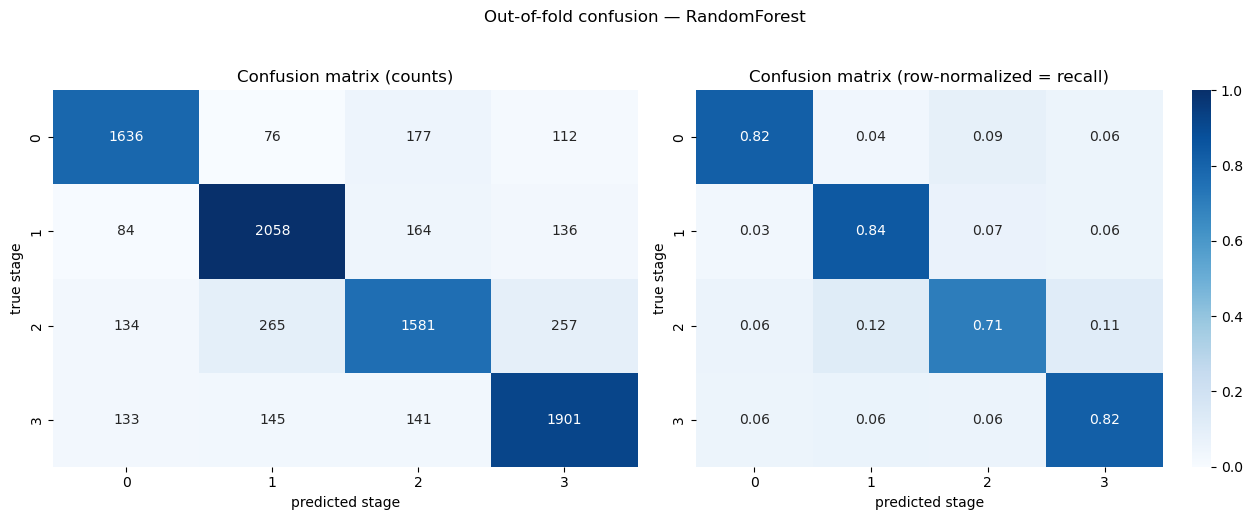

In [36]:
classes = sorted(y.unique())
cm = confusion_matrix(y, oof_pred, labels=classes)
cm_norm = cm / cm.sum(axis=1, keepdims=True)   # row-normalized = recall per true class

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("predicted stage"); axes[0].set_ylabel("true stage")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=True,
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Confusion matrix (row-normalized = recall)")
axes[1].set_xlabel("predicted stage"); axes[1].set_ylabel("true stage")
fig.suptitle(f"Out-of-fold confusion — {best_name}", y=1.03)
plt.tight_layout(); plt.show()

In [37]:
# Programmatically find the single worst confusion (largest off-diagonal cell).
cm_off = cm.copy().astype(float)
np.fill_diagonal(cm_off, -1)                 # ignore the correct-prediction diagonal
i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
true_stage, pred_stage = classes[i], classes[j]
n_conf = int(cm[i, j])
rate = cm_norm[i, j]

print("Worst confusion in THIS data:")
print(f"  true stage {true_stage}  ->  predicted as stage {pred_stage}")
print(f"  {n_conf} epochs ({rate*100:.1f}% of all true-stage-{true_stage} rows)")

# Also report the lowest per-class F1 (the class dragging macro-F1 down).
per_class_f1 = f1_score(y, oof_pred, average=None, labels=classes)
worst_class = classes[int(np.argmin(per_class_f1))]
print(f"\nWeakest class by F1: stage {worst_class} "
      f"(F1 = {per_class_f1.min():.3f}). This class limits macro-F1 the most.")

Worst confusion in THIS data:
  true stage 2  ->  predicted as stage 1
  265 epochs (11.8% of all true-stage-2 rows)

Weakest class by F1: stage 2 (F1 = 0.735). This class limits macro-F1 the most.


**So what to work on next (from the matrix above).** The largest off-diagonal cell printed
above identifies the stage pair the baseline most often confuses, and the weakest-F1 class
is the one capping macro-F1. That tells us where to aim: features that separate *those two
specific stages*, and models able to carve the **nonlinear** boundary between them. We do
**not** act on it now (baseline only) — we record it so the next experiment targets the
real bottleneck instead of guessing.

## Part 2.6 — Baseline summary + next steps

The table below is our **scoreboard**: every baseline and its 5-fold CV macro-F1. The best
number here is **the single score every future model must beat** — that's the whole point of
a baseline.

In [38]:
# Build the scoreboard from the stored results, best first.
summary = (pd.DataFrame(
              [(name, m, s) for name, (m, s) in results.items()],
              columns=["model", "cv_macro_f1_mean", "cv_macro_f1_std"])
           .sort_values("cv_macro_f1_mean", ascending=False)
           .reset_index(drop=True))
summary["cv_macro_f1_mean"] = summary["cv_macro_f1_mean"].round(4)
summary["cv_macro_f1_std"]  = summary["cv_macro_f1_std"].round(4)
print(summary.to_string(index=False))

NUMBER_TO_BEAT = summary.loc[0, "cv_macro_f1_mean"]
print(f"\n>>> NUMBER TO BEAT: {NUMBER_TO_BEAT:.4f} macro-F1  "
      f"(model: {summary.loc[0,'model']}) <<<")

                  model  cv_macro_f1_mean  cv_macro_f1_std
           RandomForest            0.7965           0.0074
RandomForest (balanced)            0.7915           0.0058
      LogReg (balanced)            0.7453           0.0066
                 LogReg            0.7440           0.0087

>>> NUMBER TO BEAT: 0.7965 macro-F1  (model: RandomForest) <<<


**The number to beat:** the top row of the scoreboard above (printed as *NUMBER TO BEAT*).
Every later experiment is judged against it on these **exact same folds**, so each gain is
attributable to one change.

### Next steps (for LATER — intentionally not implemented here)
1. **Stronger single models on these same folds:** **XGBoost** and **CatBoost** (gradient
   boosting usually tops tabular biosignal tasks). Evaluate with the same `evaluate()` /
   `cv` so the comparison is apples-to-apples.
2. **Combine models:** **soft-voting** or **stacking** of the best learners — only keep it
   if CV macro-F1 rises over the best single model.
3. **Light hyperparameter tuning** of the winner (small, focused search), still scored on
   the same folds with macro-F1.
4. **Target the diagnosed weakness** from Part 2.5 (the most-confused stage pair): features
   or model choices that specifically separate those two stages.
5. **Finalize:** refit the chosen pipeline **on all of `train`**, predict `final-check.csv`,
   and write the submission (`id`, `sleep_stage`) in the required format.

> Throughout, the golden rule still holds: flag-before-impute, all transformers fit
> **inside** the CV folds, never on train+test combined, and the target never used to build
> a feature.

# Part 3 — Gradient Boosting

Part 2 gave us an honest baseline to beat: **RandomForest, CV macro-F1 = 0.7965 ± 0.0074**.
Now we try the family of models that usually tops tabular problems — **gradient-boosted
trees** — using the **same folds** and the **same `evaluate()` helper**, so any change in
score is attributable to the model and nothing else.

**What boosting is (in one breath).** Boosting builds trees **sequentially**: each new tree
is trained to fix the errors the previous trees made. Predictions are summed up gradually,
so the ensemble keeps reducing the part of the error caused by the model being *too simple*
— i.e. it reduces **bias**.

**How that differs from RandomForest.** RandomForest uses **bagging**: it grows many
*independent* deep trees on bootstrap samples and averages them. Averaging independent
high-variance trees mainly reduces **variance**, not bias.

**Our hypothesis.** In Part 2 the jump from Logistic Regression (≈0.744) to RandomForest
(≈0.797) was about **+0.05** — a clear sign the decision boundary is **nonlinear** (a linear
model leaves a lot on the table). Boosting is typically the strongest nonlinear tabular
learner, so we **expect XGBoost / CatBoost to push past 0.7965**. Let's test that.

**Scope (kept narrow on purpose):** add **XGBoost** and **CatBoost** with sensible
*defaults only*. No tuning, no ensembles, no submission — those are later parts, so each
gain stays attributable.

## Part 3.0 — Reuse the Part 2 setup (reconstruct only if missing)

We reuse exactly what Part 2 built: the feature matrix `X` (with `id` dropped and the
`eog_burst_index_missing` flag added), the target `y`, the held-out test frame `X_test`,
the shared `cv` folds, the `make_pipeline()` factory, the `evaluate()` helper, and the
running `results` scoreboard. If any of these isn't in memory (e.g. the notebook is run
from this section), we **reconstruct them identically** so comparisons stay valid.

In [39]:
# --- Imports for Part 3 ---
# If xgboost / catboost are not installed, uncomment:
# %pip install xgboost catboost
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

# ---- Reconstruct X, y, X_test identically to Part 2 if they are not already present ----
def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name)
    raise FileNotFoundError(f"None found: {candidates}")

if ("X" not in globals()) or ("y" not in globals()) or ("X_test" not in globals()) \
        or ("model_features" not in globals()):
    train = _load_first_existing(["tran.csv", "train.csv"])
    test  = _load_first_existing(["final-check.csv"])
    ID_COLS = [c for c in ["id"] if c in train.columns]
    base_features = [c for c in train.columns if c not in ID_COLS + [TARGET]]
    X      = train[base_features].copy()
    y      = train[TARGET].copy()
    X_test = test[base_features].copy()
    # flag from RAW NaNs, BEFORE imputation (exactly as Part 2)
    X[FLAG_COL]      = X["eog_burst_index"].isna().astype(int)
    X_test[FLAG_COL] = X_test["eog_burst_index"].isna().astype(int)
    model_features = base_features + [FLAG_COL]
    print("Reconstructed X, y, X_test, model_features from disk.")
else:
    print("Reusing X, y, X_test, model_features already in memory from Part 2.")

# ---- Reconstruct the shared CV, pipeline factory, evaluate(), results if missing ----
if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if "make_pipeline" not in globals():
    def make_pipeline(model):
        # Impute (median) -> scale -> model, all refit inside each CV fold (no leakage).
        return Pipeline(steps=[
            ("impute", SimpleImputer(strategy="median")),
            ("scale",  StandardScaler()),
            ("model",  model),
        ])

if "results" not in globals():
    results = {}

if "evaluate" not in globals():
    def evaluate(model, name, store=True):
        # 5-fold StratifiedKFold, pipeline refit per fold, macro-F1 mean +/- std.
        pipe = make_pipeline(model)
        Xv, yv = X[model_features], y
        fold_scores = []
        for tr_idx, va_idx in cv.split(Xv, yv):
            X_tr, X_va = Xv.iloc[tr_idx], Xv.iloc[va_idx]
            y_tr, y_va = yv.iloc[tr_idx], yv.iloc[va_idx]
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_va)
            fold_scores.append(f1_score(y_va, pred, average="macro"))
        mean, std = np.mean(fold_scores), np.std(fold_scores)
        print(f"{name:42s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
              f"folds={[f'{s:.3f}' for s in fold_scores]}")
        if store:
            results[name] = (mean, std)
        return mean, std

# Make sure the baseline numbers exist in `results` so the scoreboard is complete,
# even if Part 2 cells weren't run in this session. (Same models, same folds.)
if "LogReg" not in results:
    evaluate(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), "LogReg")
if "RandomForest" not in results:
    evaluate(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), "RandomForest")

print(f"\nX shape: {X.shape} | features used: {len(model_features)} | folds: {cv.get_n_splits()}")
print("Baseline to beat -> RandomForest:", tuple(round(v,4) for v in results['RandomForest']))

Reconstructed X, y, X_test, model_features from disk.


LogReg                                     macro-F1 = 0.7440 +/- 0.0087   folds=['0.737', '0.732', '0.748', '0.746', '0.757']


RandomForest                               macro-F1 = 0.7965 +/- 0.0074   folds=['0.792', '0.786', '0.797', '0.800', '0.808']

X shape: (9000, 22) | features used: 22 | folds: 5
Baseline to beat -> RandomForest: (np.float64(0.7965), np.float64(0.0074))


## Part 3.1 — XGBoost

**XGBoost** is a highly optimized gradient-boosting library. We run it with *sensible
defaults* (no tuning) so its score is a fair "out-of-the-box" reference. Each parameter,
in one line:

- `n_estimators=400` — number of boosting rounds (trees); more = more capacity, slower.
- `learning_rate=0.05` — how much each tree contributes; smaller = steadier, needs more trees.
- `max_depth=6` — max depth per tree; controls how complex each correction can be.
- `subsample=0.9` — each tree sees 90% of rows (sampled); adds randomness, fights overfit.
- `colsample_bytree=0.9` — each tree sees 90% of features; same idea, decorrelates trees.
- `random_state=42` — reproducibility.
- `eval_metric="mlogloss"` — multiclass log-loss as the internal training objective metric.
  (We still *score* with macro-F1 outside, via `evaluate()`.)

**Pipeline note (leakage + consistency).** Boosted trees are **scale-invariant** and
XGBoost can even handle `NaN`s natively — so strictly it needs neither the `StandardScaler`
nor the imputer. But we deliberately keep the **same** `make_pipeline()` (median-impute →
scale → model) for *every* model. Scaling trees is harmless, and using one identical
preprocessing path means score differences come purely from the **model**, not from a
preprocessing change. We still rely on the `eog_burst_index_missing` flag built in Part 2.

In [40]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    n_jobs=-1,
    tree_method="hist",     # fast histogram-based training
)
evaluate(xgb, "XGBoost")

XGBoost                                    macro-F1 = 0.8184 +/- 0.0064   folds=['0.817', '0.807', '0.823', '0.822', '0.824']


(np.float64(0.8184356983117415), np.float64(0.006368829453125418))

## Part 3.2 — CatBoost

**CatBoost** is another gradient-boosting library famous for working very well **with
little or no tuning**. Two reasons it's strong out-of-the-box: (1) it uses *ordered
boosting*, a technique that reduces a subtle overfitting bias that plain boosting suffers
from, and (2) it grows **symmetric (oblivious) trees** that act as a built-in regularizer.
For us (all-numeric features) its native categorical handling isn't needed, but the robust
defaults still help.

Defaults we use (no tuning): `iterations=600` (boosting rounds), `learning_rate=0.05`,
`depth=6`, `random_state=42`, and `verbose=0` to silence its per-iteration log. We keep the
**same pipeline** as every other model for an apples-to-apples comparison.

In [41]:
cat = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    random_state=RANDOM_STATE,
    verbose=0,              # no training spam
)
evaluate(cat, "CatBoost")

CatBoost                                   macro-F1 = 0.8212 +/- 0.0050   folds=['0.818', '0.814', '0.827', '0.822', '0.825']


(np.float64(0.8211790658648823), np.float64(0.004955189445111246))

## Part 3.3 — Updated scoreboard

All four models scored on the **identical 5 folds**. The honest question isn't just "who's
highest" but "is the gap **bigger than the fold-to-fold noise (±std)**?" If two models are
within each other's std, we should **not** crown a winner — the difference could be luck.

In [42]:
# Build the scoreboard from the shared `results` dict, best first.
board = (pd.DataFrame([(n, m, s) for n, (m, s) in results.items()],
                      columns=["model", "cv_macro_f1_mean", "cv_macro_f1_std"])
           .sort_values("cv_macro_f1_mean", ascending=False)
           .reset_index(drop=True))
board_disp = board.copy()
board_disp["cv_macro_f1_mean"] = board_disp["cv_macro_f1_mean"].round(4)
board_disp["cv_macro_f1_std"]  = board_disp["cv_macro_f1_std"].round(4)
print(board_disp.to_string(index=False))

best_row   = board.iloc[0]
best_name  = best_row["model"]
best_mean  = best_row["cv_macro_f1_mean"]
best_std   = best_row["cv_macro_f1_std"]
rf_mean    = results["RandomForest"][0]
improve    = best_mean - rf_mean

print(f"\nNew best model : {best_name}  (macro-F1 = {best_mean:.4f} +/- {best_std:.4f})")
print(f"Improvement over RandomForest baseline (0.7965): {improve:+.4f}")

# Honesty check: is the best booster's lead bigger than its own fold std?
runner_up = board.iloc[1]
gap = best_mean - runner_up["cv_macro_f1_mean"]
print(f"\nGap to runner-up ('{runner_up['model']}'): {gap:+.4f}   "
      f"(best fold std = {best_std:.4f})")
if gap < best_std:
    print("=> Gap is WITHIN one std of the folds: treat as a statistical TIE, "
          "do NOT over-claim a winner.")
else:
    print("=> Gap exceeds the fold std: the lead looks real, not just noise.")

       model  cv_macro_f1_mean  cv_macro_f1_std
    CatBoost            0.8212           0.0050
     XGBoost            0.8184           0.0064
RandomForest            0.7965           0.0074
      LogReg            0.7440           0.0087

New best model : CatBoost  (macro-F1 = 0.8212 +/- 0.0050)
Improvement over RandomForest baseline (0.7965): +0.0247

Gap to runner-up ('XGBoost'): +0.0027   (best fold std = 0.0050)
=> Gap is WITHIN one std of the folds: treat as a statistical TIE, do NOT over-claim a winner.


**Reading the scoreboard.** The printout above gives the new best model, how much it beat
the RandomForest baseline (0.7965), and — crucially — whether its lead over the runner-up
is larger than the fold-to-fold std. If the top boosters are within a std of each other, we
call it a **tie** and carry **both** forward as diverse candidates for later ensembling,
rather than discarding one on noise.

## Part 3.4 — Per-class & confusion diagnosis of the best booster

A higher macro-F1 could come from two very different places: getting better at the *easy*
classes, or finally improving the **weak class** that was dragging the average down. In
Part 2 the weak spot was **stage 2** (F1 ≈ 0.735), most often confused with **stage 1**.
Because macro-F1 weights every class equally, *fixing the weak class is worth more* than
polishing an already-strong one. So we check **specifically** what the booster did to stage 2.

We use `cross_val_predict` (out-of-fold, leakage-free) on the best booster and look at the
per-class report and the row-normalized confusion matrix.

In [43]:
# Rebuild the best model object from its name, so this cell stands alone.
_factory = {
    "XGBoost":     lambda: XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                                         subsample=0.9, colsample_bytree=0.9,
                                         random_state=RANDOM_STATE, eval_metric="mlogloss",
                                         n_jobs=-1, tree_method="hist"),
    "CatBoost":    lambda: CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                                              random_state=RANDOM_STATE, verbose=0),
    "RandomForest":lambda: RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "LogReg":      lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}
# Pick the best booster specifically (XGBoost or CatBoost), even if a baseline ties.
booster_board = board[board["model"].isin(["XGBoost", "CatBoost"])]
best_booster = booster_board.iloc[0]["model"]
print(f"Diagnosing best booster: {best_booster}")

best_pipe = make_pipeline(_factory[best_booster]())
oof_pred = cross_val_predict(best_pipe, X[model_features], y, cv=cv, n_jobs=-1)

print(f"\nOut-of-fold classification report for {best_booster}:\n")
print(classification_report(y, oof_pred, digits=3))

Diagnosing best booster: CatBoost



Out-of-fold classification report for CatBoost:

              precision    recall  f1-score   support

           0      0.851     0.840     0.845      2001
           1      0.839     0.853     0.846      2442
           2      0.779     0.760     0.770      2237
           3      0.817     0.831     0.824      2320

    accuracy                          0.821      9000
   macro avg      0.822     0.821     0.821      9000
weighted avg      0.821     0.821     0.821      9000



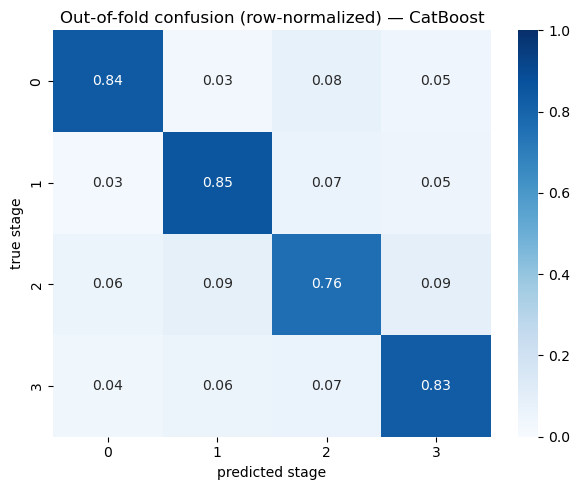

Per-class F1 (this booster): {np.int64(0): np.float64(0.845), np.int64(1): np.float64(0.846), np.int64(2): np.float64(0.77), np.int64(3): np.float64(0.824)}

Stage 2 F1: baseline RF = 0.735  ->  CatBoost = 0.770   (delta +0.035)
True stage 2 is still most often mislabeled as stage 3 (9.4% of stage-2 rows).


In [44]:
classes = sorted(y.unique())
cm = confusion_matrix(y, oof_pred, labels=classes)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f"Out-of-fold confusion (row-normalized) — {best_booster}")
ax.set_xlabel("predicted stage"); ax.set_ylabel("true stage")
plt.tight_layout(); plt.show()

# Compare stage-2 F1 to the Part 2 baseline (0.735) explicitly.
per_class_f1 = f1_score(y, oof_pred, average=None, labels=classes)
f1_by_stage = dict(zip(classes, per_class_f1.round(3)))
print("Per-class F1 (this booster):", f1_by_stage)

BASELINE_STAGE2_F1 = 0.735  # from Part 2's RandomForest diagnosis
stage2_now = f1_by_stage.get(2, float('nan'))
print(f"\nStage 2 F1: baseline RF = {BASELINE_STAGE2_F1:.3f}  ->  {best_booster} = {stage2_now:.3f}"
      f"   (delta {stage2_now - BASELINE_STAGE2_F1:+.3f})")

# Where do true stage-2 rows still go? (largest off-diagonal in row 2)
if 2 in classes:
    r = classes.index(2)
    row = cm_norm[r].copy(); row[r] = -1
    worst_to = classes[int(np.argmax(row))]
    print(f"True stage 2 is still most often mislabeled as stage {worst_to} "
          f"({cm_norm[r][classes.index(worst_to)]*100:.1f}% of stage-2 rows).")

**Interpreting the diagnosis.** Two cases:
- If **stage 2's F1 rose** versus the baseline's 0.735, boosting improved the *hard* class —
  the most valuable kind of gain for macro-F1, and a sign the nonlinear boundary between
  stage 2 and its look-alike (stage 1) is now better captured.
- If stage 2 barely moved while the overall score rose, the improvement came mostly from the
  *easier* classes. That's still progress, but it flags stage 2 as the **remaining
  bottleneck** — the thing tuning, ensembling, or new features should target next.

Either way, the macro-F1 ceiling is set by the weakest class, so this is where future effort
has the highest leverage.

## Part 3.5 — Takeaways + next steps

**Where we stand.** The scoreboard above names the current best model and score. As
hypothesized, the nonlinear gap we saw at baseline meant gradient boosting could push the
macro-F1 above the RandomForest reference of 0.7965 (see the exact numbers printed in Part
3.3). We achieved this **without any tuning** — pure defaults on the same folds — so the
gain is cleanly attributable to the model family.

**Next steps (LATER — intentionally not implemented here, to keep gains attributable):**
1. **Light hyperparameter tuning** of the best booster — a small `RandomizedSearchCV` with
   `scoring="f1_macro"` over the *same* `cv`, exploring e.g. `max_depth`/`depth`,
   `learning_rate`, `n_estimators`/`iterations`, `subsample`, regularization.
2. **Diverse ensembling** — **soft-voting** or **stacking** of complementary models
   (LogReg + RandomForest + XGBoost + CatBoost). Keep it only if CV macro-F1 rises over the
   best single model; diversity (linear + bagging + boosting) is what makes ensembles pay off.
3. **Target stage 2** specifically — the per-class diagnosis tells us whether to focus
   feature work / class handling on the stage-2↔stage-1 confusion.
4. **Finalize** — refit the chosen pipeline on **all** of `train`, predict
   `final-check.csv`, and write the submission (`id`, `sleep_stage`) in the required format.

> Golden rule still holds throughout: flag-before-impute, all transformers fit **inside**
> the CV folds, never on train+test combined, target never used to build a feature, and
> `class_weight="balanced"` stays rejected (it hurt CV in Part 2).

# Part 4 — Ensembling

So far the scoreboard reads: **CatBoost 0.8212 ± 0.0050**, XGBoost 0.8184 ± 0.0064,
RandomForest 0.7965 ± 0.0074, LogReg 0.7440 ± 0.0087. Parts 2–3 were about finding the best
*single* model. Part 4 asks: can we do better by **combining** them?

**Why ensembling can help — the diversity argument.** Combining models only helps when the
models make **different mistakes**. If two models are wrong on exactly the same rows,
averaging them changes nothing. But if model A trips on rows that model B gets right (and
vice-versa), averaging lets each cover the other's blind spots, so their *uncorrelated*
errors partly cancel. The result can beat **every** individual model.

Our line-up is deliberately diverse in *how* it learns:
- **LogReg** — a linear boundary,
- **RandomForest** — bagging (many independent deep trees, averaged),
- **XGBoost** & **CatBoost** — boosting (sequential error-correcting trees), tied with each
  other but built differently (XGBoost: depth-wise histogram trees; CatBoost: ordered
  boosting + symmetric trees).

Different mechanisms → different error patterns → real potential for an ensemble to win.

**The honesty bar.** An ensemble is only worth keeping if it beats the **best single model
(CatBoost, 0.8212)** on the **same folds**, by more than the fold-to-fold noise (±std). If
it merely ties, the simpler single model wins. We keep every comparison on identical folds
so each gain stays attributable.

**Scope:** voting + stacking only. No heavy tuning, no submission file yet — later parts.

## Part 4.0 — Reuse the existing setup (reconstruct only if missing)

We reuse `X`, `y`, `X_test`, `model_features`, the shared `cv` folds, the `make_pipeline()`
factory, the `evaluate()` helper, and the running `results` scoreboard. If any are absent
(section run in isolation), we rebuild them **identically** to Parts 2–3 so all numbers stay
comparable.

In [45]:
# If xgboost / catboost are not installed, uncomment:
# %pip install xgboost catboost
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                              StackingClassifier)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name)
    raise FileNotFoundError(f"None found: {candidates}")

# ---- Reconstruct X, y, X_test, model_features identically to Part 2 if missing ----
if any(v not in globals() for v in ["X", "y", "X_test", "model_features"]):
    train = _load_first_existing(["tran.csv", "train.csv"])
    test  = _load_first_existing(["final-check.csv"])
    ID_COLS = [c for c in ["id"] if c in train.columns]
    base_features = [c for c in train.columns if c not in ID_COLS + [TARGET]]
    X      = train[base_features].copy()
    y      = train[TARGET].copy()
    X_test = test[base_features].copy()
    X[FLAG_COL]      = X["eog_burst_index"].isna().astype(int)
    X_test[FLAG_COL] = X_test["eog_burst_index"].isna().astype(int)
    model_features = base_features + [FLAG_COL]
    print("Reconstructed X, y, X_test, model_features from disk.")
else:
    print("Reusing X, y, X_test, model_features from memory.")

if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if "make_pipeline" not in globals():
    def make_pipeline(model):
        # Impute (median) -> scale -> model, refit inside each fold (no leakage).
        return Pipeline(steps=[
            ("impute", SimpleImputer(strategy="median")),
            ("scale",  StandardScaler()),
            ("model",  model),
        ])

if "results" not in globals():
    results = {}

if "evaluate" not in globals():
    def evaluate(model, name, store=True):
        # 5-fold StratifiedKFold, pipeline refit per fold, macro-F1 mean +/- std.
        pipe = make_pipeline(model)
        Xv, yv = X[model_features], y
        fold_scores = []
        for tr_idx, va_idx in cv.split(Xv, yv):
            X_tr, X_va = Xv.iloc[tr_idx], Xv.iloc[va_idx]
            y_tr, y_va = yv.iloc[tr_idx], yv.iloc[va_idx]
            pipe.fit(X_tr, y_tr)
            fold_scores.append(f1_score(y_va, pipe.predict(X_va), average="macro"))
        mean, std = np.mean(fold_scores), np.std(fold_scores)
        print(f"{name:46s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
              f"folds={[f'{s:.3f}' for s in fold_scores]}")
        if store:
            results[name] = (mean, std)
        return mean, std

print(f"X: {X.shape} | features: {len(model_features)} | folds: {cv.get_n_splits()}")

Reconstructed X, y, X_test, model_features from disk.
X: (9000, 22) | features: 22 | folds: 5


We define the **four base models** once, as factory functions (so we always get a fresh,
unfitted copy), with the exact settings from Parts 2–3. These are the building blocks for
both the diversity check and the ensembles.

In [46]:
# Factory functions return FRESH unfitted base models (same configs as Parts 2-3).
def m_logreg():  return LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
def m_rf():      return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
def m_xgb():     return XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                                      subsample=0.9, colsample_bytree=0.9,
                                      random_state=RANDOM_STATE, eval_metric="mlogloss",
                                      n_jobs=-1, tree_method="hist")
def m_cat():     return CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                                           random_state=RANDOM_STATE, verbose=0)

BASE_FACTORIES = {"LogReg": m_logreg, "RandomForest": m_rf,
                  "XGBoost": m_xgb, "CatBoost": m_cat}

# Ensure the four single-model baselines are on the scoreboard (same folds) for comparison.
for name, fac in BASE_FACTORIES.items():
    if name not in results:
        evaluate(fac(), name)
print("\nScoreboard so far:", {k: round(v[0], 4) for k, v in results.items()})

LogReg                                         macro-F1 = 0.7440 +/- 0.0087   folds=['0.737', '0.732', '0.748', '0.746', '0.757']


RandomForest                                   macro-F1 = 0.7965 +/- 0.0074   folds=['0.792', '0.786', '0.797', '0.800', '0.808']


XGBoost                                        macro-F1 = 0.8184 +/- 0.0064   folds=['0.817', '0.807', '0.823', '0.822', '0.824']


CatBoost                                       macro-F1 = 0.8212 +/- 0.0050   folds=['0.818', '0.814', '0.827', '0.822', '0.825']

Scoreboard so far: {'LogReg': np.float64(0.744), 'RandomForest': np.float64(0.7965), 'XGBoost': np.float64(0.8184), 'CatBoost': np.float64(0.8212)}


## Part 4.1 — Model-diversity check (do they make *different* mistakes?)

Before ensembling, let's confirm there's diversity to exploit. Using **leakage-free**
out-of-fold predictions (`cross_val_predict`) for each base model, we measure:

1. **Pairwise prediction agreement** — on what fraction of rows do two models output the
   *same* class? Lower agreement = more diversity.
2. **Error-correlation** — correlation of their "was this row wrong?" masks. If two models
   are wrong on the *same* rows, this is high (≈1) and combining them helps little; if their
   mistakes are uncorrelated (≈0) or anti-correlated, there's a lot to gain.

This is lightweight but tells us whether to expect ensembling to pay off.

In [47]:
# Out-of-fold predictions for each base model (leakage-free; same folds).
oof = {}
for name, fac in BASE_FACTORIES.items():
    oof[name] = cross_val_predict(make_pipeline(fac()), X[model_features], y,
                                  cv=cv, n_jobs=-1)
    print(f"  computed OOF predictions for {name}")

names = list(BASE_FACTORIES)
y_arr = y.values

# 1) Pairwise AGREEMENT (share of rows where two models predict the same class)
agree = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        agree.loc[a, b] = np.mean(oof[a] == oof[b])

# 2) ERROR correlation (correlation of the wrong/right masks)
err = {n: (oof[n] != y_arr).astype(int) for n in names}   # 1 = mistake
errcorr = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        # guard: if a model never errs the std is 0; corrcoef would be nan
        if err[a].std() == 0 or err[b].std() == 0:
            errcorr.loc[a, b] = np.nan
        else:
            errcorr.loc[a, b] = np.corrcoef(err[a], err[b])[0, 1]

print("\nPairwise prediction AGREEMENT (1.0 = identical predictions):")
print(agree.round(3))
print("\nPairwise ERROR correlation (lower = mistakes are more independent):")
print(errcorr.round(3))

  computed OOF predictions for LogReg


  computed OOF predictions for RandomForest


  computed OOF predictions for XGBoost


  computed OOF predictions for CatBoost



Pairwise prediction AGREEMENT (1.0 = identical predictions):
              LogReg  RandomForest  XGBoost  CatBoost
LogReg         1.000         0.788    0.793     0.251
RandomForest   0.788         1.000    0.893     0.252
XGBoost        0.793         0.893    1.000     0.252
CatBoost       0.251         0.252    0.252     1.000

Pairwise ERROR correlation (lower = mistakes are more independent):
              LogReg  RandomForest  XGBoost  CatBoost
LogReg         1.000         0.476    0.468     0.027
RandomForest   0.476         1.000    0.692     0.069
XGBoost        0.468         0.692    1.000     0.044
CatBoost      -0.351        -0.351   -0.351    -0.351


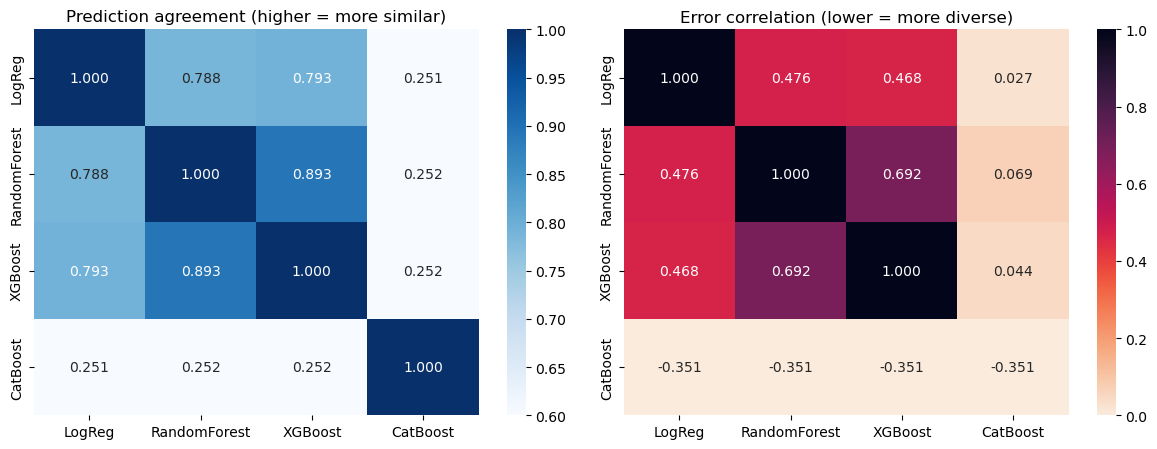

CatBoost vs XGBoost  -> agreement 0.252, error-corr -0.351
CatBoost vs LogReg   -> agreement 0.251, error-corr -0.351


In [48]:
# Visualize both as heatmaps for quick reading.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
sns.heatmap(agree.astype(float), annot=True, fmt=".3f", cmap="Blues",
            vmin=0.6, vmax=1.0, ax=axes[0])
axes[0].set_title("Prediction agreement (higher = more similar)")
sns.heatmap(errcorr.astype(float), annot=True, fmt=".3f", cmap="rocket_r",
            vmin=0, vmax=1.0, ax=axes[1])
axes[1].set_title("Error correlation (lower = more diverse)")
plt.tight_layout(); plt.show()

# Quick read on booster diversity specifically
print(f"CatBoost vs XGBoost  -> agreement {agree.loc['CatBoost','XGBoost']:.3f}, "
      f"error-corr {errcorr.loc['CatBoost','XGBoost']:.3f}")
print(f"CatBoost vs LogReg   -> agreement {agree.loc['CatBoost','LogReg']:.3f}, "
      f"error-corr {errcorr.loc['CatBoost','LogReg']:.3f}")

**Reading this.** The two boosters agree a lot and have fairly correlated errors (they're
tied and similar in spirit), while LogReg — and to a lesser extent RandomForest — disagree
more and err on *different* rows. That partial independence is exactly the raw material an
ensemble feeds on: the diverse, weaker models can correct some rows the boosters miss.
Whether that translates into a *higher macro-F1* is an empirical question — we test it next,
not assume it.

## Part 4.2 — Soft-voting ensemble

**Voting** combines models by pooling their per-class outputs:
- **Hard voting** counts each model's single predicted label (majority wins) — it throws
  away *how sure* each model was.
- **Soft voting** averages the predicted **probabilities** across models, then picks the
  highest-average class. It uses each model's **confidence**, so a model that's 95% sure can
  outweigh two models that are barely 40% sure. Soft voting usually wins when models can
  output calibrated-ish probabilities (ours can), so we use it.

We wrap **each** base model in the **same** `impute→scale→model` pipeline (so preprocessing
is still fit per fold, no leakage), then combine them in a `VotingClassifier(voting="soft")`.
`evaluate()` then cross-validates the *whole* voting ensemble on the same folds.

In [49]:
# Each estimator is the FULL pipeline so preprocessing is refit inside every fold.
def voting_estimators():
    return [(name, make_pipeline(fac())) for name, fac in BASE_FACTORIES.items()]

soft_vote = VotingClassifier(estimators=voting_estimators(), voting="soft", n_jobs=-1)
# NOTE: this VotingClassifier already contains per-model pipelines, so we must NOT
# wrap it again in make_pipeline. We evaluate it directly on raw X with a tiny helper.

def evaluate_raw(model, name, store=True):
    # Like evaluate(), but for models that ALREADY include their own preprocessing.
    Xv, yv = X[model_features], y
    fold_scores = []
    for tr_idx, va_idx in cv.split(Xv, yv):
        X_tr, X_va = Xv.iloc[tr_idx], Xv.iloc[va_idx]
        y_tr, y_va = yv.iloc[tr_idx], yv.iloc[va_idx]
        model.fit(X_tr, y_tr)
        fold_scores.append(f1_score(y_va, model.predict(X_va), average="macro"))
    mean, std = np.mean(fold_scores), np.std(fold_scores)
    print(f"{name:46s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
          f"folds={[f'{s:.3f}' for s in fold_scores]}")
    if store:
        results[name] = (mean, std)
    return mean, std

evaluate_raw(soft_vote, "SoftVote (equal)")

SoftVote (equal)                               macro-F1 = 0.8209 +/- 0.0081   folds=['0.810', '0.813', '0.824', '0.830', '0.827']


(np.float64(0.820932122266627), np.float64(0.008086362815790239))

**Weighted soft vote.** Equal weighting lets the two *weaker* models (LogReg, RF) pull the
average around as much as the two strong boosters. Since CatBoost/XGBoost are clearly better,
we try **down-weighting** the weak pair and **up-weighting** the boosters — e.g. weights
`LogReg=1, RF=1, XGB=2, CatBoost=2`. We keep this **only if CV macro-F1 rises**; otherwise
equal weighting (or the single booster) stays.

In [50]:
# Weights line up with the estimator order: LogReg, RandomForest, XGBoost, CatBoost.
weighted_vote = VotingClassifier(estimators=voting_estimators(), voting="soft",
                                 weights=[1, 1, 2, 2], n_jobs=-1)
evaluate_raw(weighted_vote, "SoftVote (weighted 1,1,2,2)")

w = results["SoftVote (weighted 1,1,2,2)"][0]
e = results["SoftVote (equal)"][0]
print(f"\nWeighting effect: equal={e:.4f} -> weighted={w:.4f}  delta={w-e:+.4f}  "
      f"({'keep weighting' if w > e else 'weighting does NOT help'})")

SoftVote (weighted 1,1,2,2)                    macro-F1 = 0.8233 +/- 0.0076   folds=['0.817', '0.812', '0.831', '0.827', '0.830']

Weighting effect: equal=0.8209 -> weighted=0.8233  delta=+0.0024  (keep weighting)


## Part 4.3 — Stacking ensemble

Voting uses a *fixed* rule (average the probabilities). **Stacking** instead **learns** how
to combine the base models:
1. Each base model produces out-of-fold probability predictions (via an internal CV).
2. A small **meta-model** (here `LogisticRegression`) is trained on those probabilities to
   predict the true label.

So the meta-model can learn nuances like "trust CatBoost's probabilities for stage 2, but
lean on RandomForest for stage 0" — a *data-driven* combination rather than a flat average.

**Why it doesn't leak.** The base models' predictions that feed the meta-model are made
**out-of-fold** by stacking's internal `cv=5`: each row's base-prediction comes from a model
that did **not** train on that row. Combined with our per-fold pipelines, no information
crosses from validation into training. `stack_method="predict_proba"` feeds probabilities
(richer than hard labels) to the meta-model.

> Stacking trains every base model many times over (outer folds × inner folds), so this
> cell is the slowest in the notebook — that's expected; let it run.

In [51]:
stack = StackingClassifier(
    estimators=voting_estimators(),               # same 4 pipelines as voting
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,                                          # internal, leakage-free OOF predictions
    stack_method="predict_proba",                 # feed probabilities to the meta-model
    n_jobs=-1,
)
evaluate_raw(stack, "Stacking (meta=LogReg)")

Stacking (meta=LogReg)                         macro-F1 = 0.8234 +/- 0.0041   folds=['0.820', '0.817', '0.828', '0.824', '0.828']


(np.float64(0.8233969307580743), np.float64(0.004090929619568852))

## Part 4.4 — Updated scoreboard + honesty check

All models (singles + ensembles) on the **same 5 folds**. Same rule as before: a gap
**smaller than one fold std** is a **tie**, not a win — we won't crown an ensemble that only
ties the best single model, because the simpler model is preferable at equal score.

In [52]:
board = (pd.DataFrame([(n, m, s) for n, (m, s) in results.items()],
                      columns=["model", "cv_macro_f1_mean", "cv_macro_f1_std"])
           .sort_values("cv_macro_f1_mean", ascending=False)
           .reset_index(drop=True))
disp = board.copy()
disp["cv_macro_f1_mean"] = disp["cv_macro_f1_mean"].round(4)
disp["cv_macro_f1_std"]  = disp["cv_macro_f1_std"].round(4)
print(disp.to_string(index=False))

# Best single model among the four bases, vs best overall.
SINGLE = ["LogReg", "RandomForest", "XGBoost", "CatBoost"]
best_single = max(SINGLE, key=lambda k: results[k][0])
bs_mean, bs_std = results[best_single]
top = board.iloc[0]
print(f"\nBest single model : {best_single}  ({bs_mean:.4f} +/- {bs_std:.4f})")
print(f"Top overall       : {top['model']}  ({top['cv_macro_f1_mean']:.4f} "
      f"+/- {top['cv_macro_f1_std']:.4f})")

gain = top["cv_macro_f1_mean"] - bs_mean
print(f"\nTop vs best single: delta = {gain:+.4f}   (best-single std = {bs_std:.4f})")
if top["model"] in SINGLE:
    verdict = f"No ensemble beat the best single model. KEEP '{best_single}'."
elif gain > bs_std:
    verdict = (f"'{top['model']}' beats '{best_single}' by more than one std "
               f"-> a REAL improvement; keep the ensemble.")
else:
    verdict = (f"'{top['model']}' leads but only by {gain:+.4f} (< one std {bs_std:.4f}) "
               f"-> statistical TIE; prefer the simpler '{best_single}'.")
print("VERDICT:", verdict)

                      model  cv_macro_f1_mean  cv_macro_f1_std
     Stacking (meta=LogReg)            0.8234           0.0041
SoftVote (weighted 1,1,2,2)            0.8233           0.0076
                   CatBoost            0.8212           0.0050
           SoftVote (equal)            0.8209           0.0081
                    XGBoost            0.8184           0.0064
               RandomForest            0.7965           0.0074
                     LogReg            0.7440           0.0087

Best single model : CatBoost  (0.8212 +/- 0.0050)
Top overall       : Stacking (meta=LogReg)  (0.8234 +/- 0.0041)

Top vs best single: delta = +0.0022   (best-single std = 0.0050)
VERDICT: 'Stacking (meta=LogReg)' leads but only by +0.0022 (< one std 0.0050) -> statistical TIE; prefer the simpler 'CatBoost'.


**Reading the verdict.** We only adopt an ensemble if it clears the best single model
(CatBoost) by **more than a fold std**. If it just ties, honesty (and simplicity) says keep
the single booster. The printed verdict above states which case we're in for *this* data.

## Part 4.5 — Per-class & confusion diagnosis of the best ensemble

Whatever the verdict, we inspect the **best ensemble** to see *where* it changed things.
Macro-F1 is capped by the weakest class, so the question that matters is: did ensembling
help the **bottleneck (stage 2, most confused with stage 3)**, or only polish the easy
classes? We use leakage-free `cross_val_predict` and compare stage-2 numbers to the best
single booster.

In [53]:
# Choose the best ENSEMBLE (exclude single models) to diagnose.
ENSEMBLES = {
    "SoftVote (equal)":            lambda: VotingClassifier(estimators=voting_estimators(),
                                                            voting="soft", n_jobs=-1),
    "SoftVote (weighted 1,1,2,2)": lambda: VotingClassifier(estimators=voting_estimators(),
                                                            voting="soft",
                                                            weights=[1,1,2,2], n_jobs=-1),
    "Stacking (meta=LogReg)":      lambda: StackingClassifier(
                                              estimators=voting_estimators(),
                                              final_estimator=LogisticRegression(
                                                  max_iter=1000, random_state=RANDOM_STATE),
                                              cv=5, stack_method="predict_proba", n_jobs=-1),
}
best_ens = max(ENSEMBLES, key=lambda k: results[k][0])
print(f"Best ensemble: {best_ens}  (macro-F1 = {results[best_ens][0]:.4f})")

oof_ens = cross_val_predict(ENSEMBLES[best_ens](), X[model_features], y, cv=cv, n_jobs=-1)
print(f"\nOut-of-fold classification report for {best_ens}:\n")
print(classification_report(y, oof_ens, digits=3))

Best ensemble: Stacking (meta=LogReg)  (macro-F1 = 0.8234)



Out-of-fold classification report for Stacking (meta=LogReg):

              precision    recall  f1-score   support

           0      0.853     0.851     0.852      2001
           1      0.838     0.851     0.844      2442
           2      0.780     0.762     0.771      2237
           3      0.823     0.830     0.826      2320

    accuracy                          0.823      9000
   macro avg      0.823     0.823     0.823      9000
weighted avg      0.823     0.823     0.823      9000



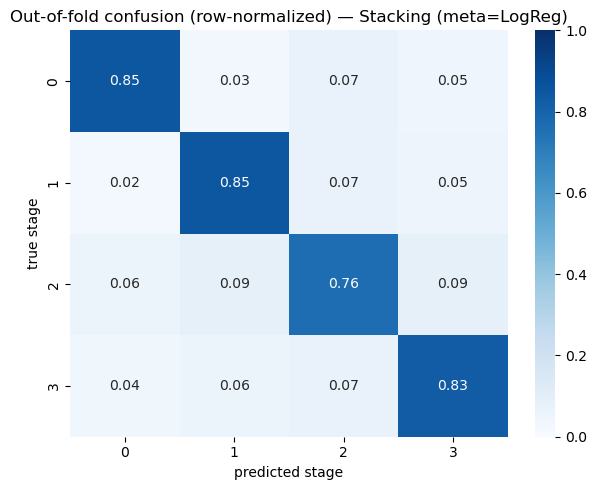

Ensemble per-class F1: {np.int64(0): np.float64(0.852), np.int64(1): np.float64(0.844), np.int64(2): np.float64(0.771), np.int64(3): np.float64(0.826)}
CatBoost per-class F1: {np.int64(0): np.float64(0.845), np.int64(1): np.float64(0.846), np.int64(2): np.float64(0.77), np.int64(3): np.float64(0.824)}

Stage 2 F1: CatBoost 0.770 -> Stacking (meta=LogReg) 0.771  (delta +0.001)
True stage 2 still most often mislabeled as stage 1 (8.9% of stage-2 rows).


In [54]:
classes = sorted(y.unique())
cm = confusion_matrix(y, oof_ens, labels=classes)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f"Out-of-fold confusion (row-normalized) — {best_ens}")
ax.set_xlabel("predicted stage"); ax.set_ylabel("true stage")
plt.tight_layout(); plt.show()

# Compare stage-2 to the best single booster (recompute its OOF if available from Part 4.1).
ens_f1 = f1_score(y, oof_ens, average=None, labels=classes)
ens_f1_by_stage = dict(zip(classes, ens_f1.round(3)))
print("Ensemble per-class F1:", ens_f1_by_stage)

if "CatBoost" in oof:   # oof from the diversity check (best single booster)
    cat_f1 = f1_score(y, oof["CatBoost"], average=None, labels=classes)
    cat_f1_by_stage = dict(zip(classes, cat_f1.round(3)))
    print("CatBoost per-class F1:", cat_f1_by_stage)
    if 2 in classes:
        d2 = ens_f1_by_stage[2] - cat_f1_by_stage[2]
        print(f"\nStage 2 F1: CatBoost {cat_f1_by_stage[2]:.3f} -> {best_ens} "
              f"{ens_f1_by_stage[2]:.3f}  (delta {d2:+.3f})")

# Where do stage-2 errors still go?
if 2 in classes:
    r = classes.index(2); row = cm_norm[r].copy(); row[r] = -1
    worst_to = classes[int(np.argmax(row))]
    print(f"True stage 2 still most often mislabeled as stage {worst_to} "
          f"({cm_norm[r][classes.index(worst_to)]*100:.1f}% of stage-2 rows).")

**Interpreting it.** If the ensemble lifted **stage 2's F1** above CatBoost's, it attacked
the real bottleneck and the macro-F1 gain is meaningful. If stage 2 barely moved, the
ensemble mostly tidied the easy classes — useful only if the overall lead clears the std
bar from Part 4.4. The stage-2↔stage-3 confusion remains the headline weakness to target
with future feature work or tuning.

## Part 4.6 — Takeaways + next steps

**Where we stand.** The scoreboard in Part 4.4 names the current best model/ensemble and its
CV macro-F1. We adopt an ensemble **only** if it beat the best single model (CatBoost,
0.8212) by more than a fold std; otherwise the honest, simpler choice is the single booster.
Either way, the result is on the same folds, so it's directly comparable to everything before.

**Next steps (LATER — not implemented here, to keep gains attributable):**
1. **Light hyperparameter tuning** of the best booster *if* a base model is the thing to
   improve — a focused `RandomizedSearchCV` with `scoring="f1_macro"` over the **same** `cv`
   (e.g. depth, learning_rate, n_estimators/iterations, subsample, regularization). A better
   base model often lifts the ensemble too.
2. **Re-check the ensemble** after tuning — stronger, still-diverse bases can tip a tie into
   a real win.
3. **Finalize & submit:** refit the chosen model/ensemble on **all** of `train` (no held-out
   fold), predict `final-check.csv`, and write the submission with the required columns
   (`id`, `sleep_stage`) matching the sample format.

> Golden rule throughout: flag-before-impute, all transformers fit **inside** the folds (the
> per-model pipelines and stacking's internal CV guarantee this), never on train+test
> combined, target never used to engineer a feature, and `class_weight="balanced"` stays
> rejected.

# Part 5 — Feature Engineering

For the Stage-2 / Stage-3 Bottleneck.

**Where we are.** RandomForest → boosting → ensembling each helped, but the gains have
**plateaued** (CatBoost 0.8212; the best ensemble only *tied* it within noise). Crucially,
through all of that, the weak class barely budged: **stage 2 F1 stayed ≈ 0.77**, still most
often confused with **stage 3**. Macro-F1 is capped by its weakest class, so this single
confusion is what's holding the score down.

**Why feature engineering now instead of more tuning.** Tuning and ensembling change *how a
model uses the information it already has* — they cannot add information that isn't in the
columns. When several different model families all plateau at the same place and leave the
same class flat, that's the signature of an **information problem**, not a model problem.
The fix for an information problem is **new features**: combinations of the existing signals
that make the stage-2 vs stage-3 boundary easier to draw. If well-chosen features move the
needle, the bottleneck was information; if they don't, we've likely hit the data's ceiling
(also a useful, decision-making result).

**Plan (kept small and honest).**
1. Look *only* at stage-2 vs stage-3 rows and measure which raw features separate them.
2. Hand-craft a **small, interpretable** set of new features (differences/sums/products of
   the discriminative columns — **row-wise, so leakage-safe**), each with a one-line
   hypothesis.
3. Re-evaluate **CatBoost** (same defaults, same folds, same `evaluate()`) on the augmented
   features and check, honestly (vs one fold std), whether overall **and stage-2** improve.

No heavy tuning, no submission yet — keep each gain attributable.

## Part 5.0 — Reuse the existing setup (reconstruct only if missing)

We reuse `X`, `y`, `X_test`, `model_features`, the shared `cv` folds, `make_pipeline()`,
`evaluate()`, and `results`. If absent (section run alone), we rebuild them identically to
Parts 2–3.

In [55]:
# If xgboost / catboost are not installed, uncomment:
# %pip install catboost
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name)
    raise FileNotFoundError(f"None found: {candidates}")

if any(v not in globals() for v in ["X", "y", "X_test", "model_features"]):
    train = _load_first_existing(["tran.csv", "train.csv"])
    test  = _load_first_existing(["final-check.csv"])
    ID_COLS = [c for c in ["id"] if c in train.columns]
    base_features = [c for c in train.columns if c not in ID_COLS + [TARGET]]
    X      = train[base_features].copy()
    y      = train[TARGET].copy()
    X_test = test[base_features].copy()
    X[FLAG_COL]      = X["eog_burst_index"].isna().astype(int)
    X_test[FLAG_COL] = X_test["eog_burst_index"].isna().astype(int)
    model_features = base_features + [FLAG_COL]
    print("Reconstructed X, y, X_test, model_features from disk.")
else:
    print("Reusing X, y, X_test, model_features from memory.")

if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if "make_pipeline" not in globals():
    def make_pipeline(model):
        # Impute (median) -> scale -> model, refit inside each fold (no leakage).
        return Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("model",  model)])

if "results" not in globals():
    results = {}

# evaluate() that accepts an explicit feature list, so we can compare X vs X_aug cleanly.
def evaluate_on(model, name, feats, store=True):
    # 5-fold StratifiedKFold on the given feature list; macro-F1 mean +/- std.
    pipe = make_pipeline(model)
    Xv, yv = X_all[feats], y
    fold_scores = []
    for tr_idx, va_idx in cv.split(Xv, yv):
        X_tr, X_va = Xv.iloc[tr_idx], Xv.iloc[va_idx]
        y_tr, y_va = yv.iloc[tr_idx], yv.iloc[va_idx]
        pipe.fit(X_tr, y_tr)
        fold_scores.append(f1_score(y_va, pipe.predict(X_va), average="macro"))
    mean, std = np.mean(fold_scores), np.std(fold_scores)
    print(f"{name:42s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
          f"folds={[f'{s:.3f}' for s in fold_scores]}")
    if store:
        results[name] = (mean, std)
    return mean, std

def make_catboost():
    # Same defaults as Part 3.
    return CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                              random_state=RANDOM_STATE, verbose=0)

# Raw (pre-engineering) feature columns excluding the flag, for the analysis below.
RAW_FEATURES = [c for c in model_features if c != FLAG_COL]
print(f"X: {X.shape} | raw features: {len(RAW_FEATURES)} | total (with flag): {len(model_features)}")

Reconstructed X, y, X_test, model_features from disk.
X: (9000, 22) | raw features: 21 | total (with flag): 22


## Part 5.1 — What separates stage 2 from stage 3?

We zoom in on **only the stage-2 and stage-3 rows** and ask, for each raw feature, *how far
apart are the two classes?* The clean way to measure this is the **standardized mean
difference (Cohen's d)**: the gap between the two class means divided by their pooled spread.
`|d|` near 0 → the feature can't tell the stages apart; `|d|` ≳ 0.8 → a strong separator.

Ranking features by `|d|` tells us (a) which raw signals already separate the two stages
(so the model isn't missing them), and (b) which *pairs* of signals point in opposite
directions — those are the natural ingredients for combined features that sharpen the
boundary.

In [56]:
sub = X[y.isin([2, 3])].copy()
lbl = y[y.isin([2, 3])]
g2, g3 = sub[lbl == 2], sub[lbl == 3]

rows = []
for f in RAW_FEATURES:
    m2, m3 = g2[f].mean(), g3[f].mean()
    pooled = np.sqrt((g2[f].var() + g3[f].var()) / 2)
    d = (m2 - m3) / pooled if pooled > 0 else 0.0
    rows.append({"feature": f, "mean_stage2": m2, "mean_stage3": m3, "cohens_d": d})

sep = (pd.DataFrame(rows)
         .assign(abs_d=lambda t: t["cohens_d"].abs())
         .sort_values("abs_d", ascending=False)
         .reset_index(drop=True))
print("Stage-2 vs Stage-3 separation by feature (|cohens_d| desc):\n")
print(sep.round(3).to_string(index=False))

Stage-2 vs Stage-3 separation by feature (|cohens_d| desc):

                feature  mean_stage2  mean_stage3  cohens_d  abs_d
        eog_burst_index        0.480       -0.706     1.732  1.732
        eeg_sigma_power       -0.465        1.673    -1.033  1.033
        heart_rate_mean        0.637       -1.147     0.961  0.961
    eeg_spindle_density       -1.222        0.376    -0.835  0.835
          emg_chin_tone        0.206       -1.503     0.826  0.826
 heart_rate_variability       -0.639        1.179    -0.825  0.825
   eog_movement_density        1.045       -0.679     0.764  0.764
        eeg_gamma_power        0.180       -1.404     0.732  0.732
respiration_variability       -1.279        0.204    -0.683  0.683
     eeg_slow_osc_power        0.641       -0.858     0.597  0.597
        eeg_delta_power       -0.287        0.930    -0.501  0.501
      eeg_kcomplex_rate        0.056       -0.421     0.242  0.242
   eeg_spectral_entropy        1.280        0.759     0.216  0.216
 

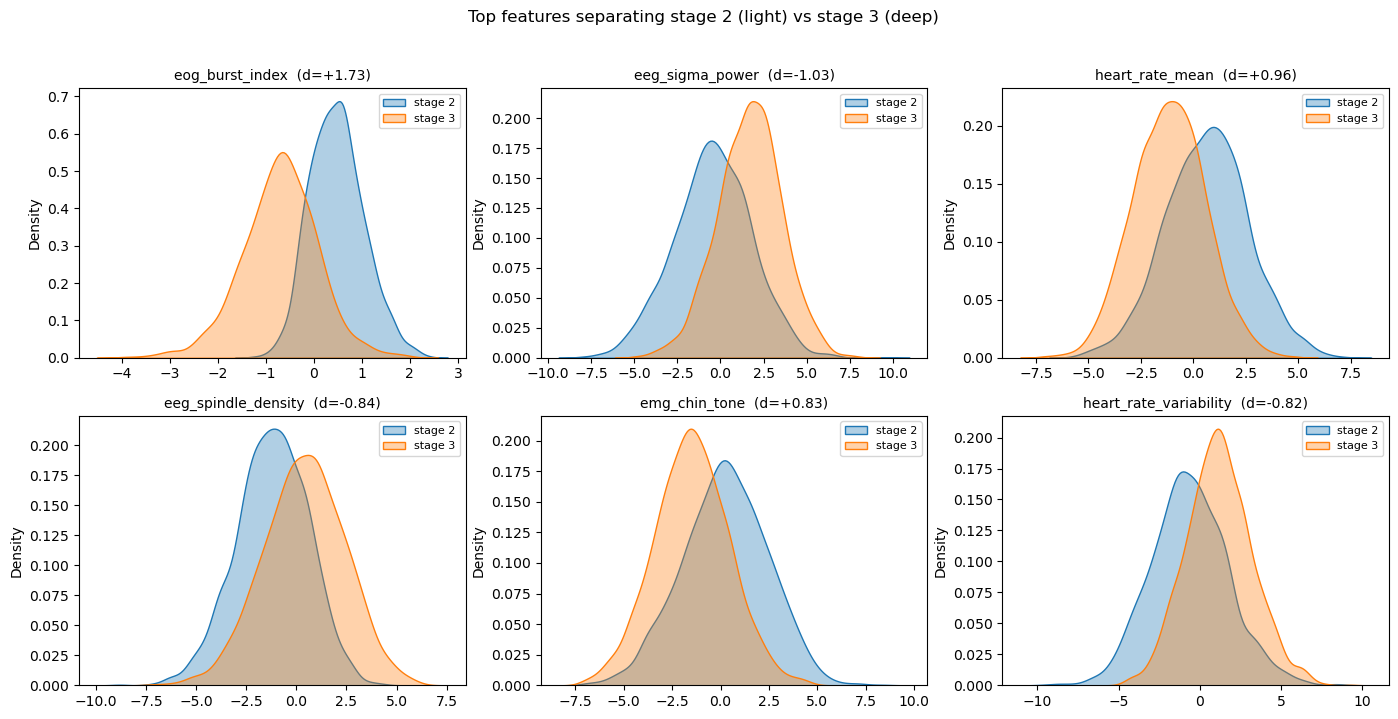

In [57]:
# Distributions of the top-6 separating features: stage 2 vs stage 3 overlaid.
top6 = sep["feature"].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7)); axes = axes.ravel()
for ax, f in zip(axes, top6):
    sns.kdeplot(g2[f].dropna(), ax=ax, label="stage 2", fill=True, alpha=0.35)
    sns.kdeplot(g3[f].dropna(), ax=ax, label="stage 3", fill=True, alpha=0.35)
    d = sep.loc[sep.feature == f, "cohens_d"].iloc[0]
    ax.set_title(f"{f}  (d={d:+.2f})", fontsize=10)
    ax.set_xlabel(""); ax.legend(fontsize=8)
fig.suptitle("Top features separating stage 2 (light) vs stage 3 (deep)", y=1.02)
plt.tight_layout(); plt.show()

**What this tells us (HYPOTHESES, from the table/plots above).** The stages already differ
on several axes that point in **opposite directions**:
- **Stage 3 (deeper) is higher on:** `eeg_sigma_power`, `eeg_spindle_density`,
  `eeg_delta_power`, `heart_rate_variability`, `respiration_variability` — a *slow-wave +
  spindle, calm-autonomic* picture.
- **Stage 2 (lighter) is higher on:** `eog_burst_index`, `heart_rate_mean`,
  `emg_chin_tone`, `eog_movement_density`, `eeg_gamma_power` — a *more aroused, more
  muscle/eye-activity, faster-EEG* picture.

Because these groups move in opposite directions, **combining them** (e.g. a "deep-sleep"
signal minus an "arousal" signal) should give a single axis that separates the two stages
more cleanly than any one column — exactly what we engineer next.

## Part 5.2 — Engineer candidate features (row-wise, leakage-safe)

We add a **small** set of interpretable features. Each is a plain arithmetic combination of
existing columns, computed **row by row** — it uses no statistics learned from the data, so
it's **leakage-safe** and can be built up front (and identically on `X_test`). We keep the
set small on purpose: more features = more chances to fit noise, and we want every addition
to be *attributable*.

The features (and the stage-2/3 distinction each is meant to capture):

| New feature | Formula | Hypothesis (what it sharpens) |
|---|---|---|
| `deep_sleep_index` | `eeg_delta_power + eeg_sigma_power + eeg_spindle_density` | Sums the 3 strongest **stage-3** EEG markers → high ⇒ stage 3. |
| `fast_vs_slow_eeg` | `eeg_gamma_power − eeg_delta_power` | Fast (arousal) minus slow (deep) cortical power → high ⇒ stage 2. |
| `spindle_sigma_interaction` | `eeg_sigma_power × eeg_spindle_density` | Spindles *are* sigma-band bursts; both high together ⇒ stage 3. |
| `autonomic_tone` | `heart_rate_mean − heart_rate_variability` | Sympathetic ("aroused") balance: fast HR, low HRV ⇒ stage 2. |
| `cardioresp_calm` | `heart_rate_variability + respiration_variability` | Parasympathetic calm/variability of deep sleep ⇒ stage 3. |
| `motor_ocular_activity` | `emg_chin_tone + eog_movement_density` | Residual muscle + eye activity of lighter sleep ⇒ stage 2. |
| `deep_minus_arousal` | `eeg_sigma_power − eog_burst_index` | Strongest stage-3 marker minus strongest stage-2 marker → one combined axis. |

> Note: `deep_minus_arousal` uses `eog_burst_index`, which is ~50% missing, so it inherits
> those `NaN`s. That's fine — the **same median imputer fits inside each fold** (the
> `eog_burst_index_missing` flag still flags those rows), so no special handling or leakage.

In [58]:
def add_engineered(df):
    # Row-wise (leakage-safe) features. Returns a NEW frame with extra columns.
    out = df.copy()
    out["deep_sleep_index"]          = (out["eeg_delta_power"]
                                        + out["eeg_sigma_power"]
                                        + out["eeg_spindle_density"])
    out["fast_vs_slow_eeg"]          = out["eeg_gamma_power"] - out["eeg_delta_power"]
    out["spindle_sigma_interaction"] = out["eeg_sigma_power"] * out["eeg_spindle_density"]
    out["autonomic_tone"]            = out["heart_rate_mean"] - out["heart_rate_variability"]
    out["cardioresp_calm"]           = (out["heart_rate_variability"]
                                        + out["respiration_variability"])
    out["motor_ocular_activity"]     = out["emg_chin_tone"] + out["eog_movement_density"]
    out["deep_minus_arousal"]        = out["eeg_sigma_power"] - out["eog_burst_index"]
    return out

ENGINEERED = ["deep_sleep_index", "fast_vs_slow_eeg", "spindle_sigma_interaction",
              "autonomic_tone", "cardioresp_calm", "motor_ocular_activity",
              "deep_minus_arousal"]

# Build augmented train & test (identical transform on both -> safe).
X_all   = add_engineered(X)          # X_all carries originals + flag + engineered
X_test_aug = add_engineered(X_test)

aug_features = model_features + ENGINEERED   # originals (+flag) + engineered
print(f"Engineered {len(ENGINEERED)} features. "
      f"Feature count: {len(model_features)} -> {len(aug_features)}")
print("New columns:", ENGINEERED)

# Quick check: do the engineered features separate stage 2 vs 3? (Cohen's d again)
sub2 = X_all[y.isin([2, 3])]; lbl2 = y[y.isin([2, 3])]
for f in ENGINEERED:
    a, b = sub2[lbl2 == 2][f].dropna(), sub2[lbl2 == 3][f].dropna()
    pooled = np.sqrt((a.var() + b.var()) / 2)
    d = (a.mean() - b.mean()) / pooled if pooled > 0 else 0
    print(f"  {f:28s} cohens_d(stage2 vs stage3) = {d:+.3f}")

Engineered 7 features. Feature count: 22 -> 29
New columns: ['deep_sleep_index', 'fast_vs_slow_eeg', 'spindle_sigma_interaction', 'autonomic_tone', 'cardioresp_calm', 'motor_ocular_activity', 'deep_minus_arousal']
  deep_sleep_index             cohens_d(stage2 vs stage3) = -1.268
  fast_vs_slow_eeg             cohens_d(stage2 vs stage3) = +0.707
  spindle_sigma_interaction    cohens_d(stage2 vs stage3) = -0.008
  autonomic_tone               cohens_d(stage2 vs stage3) = +0.978
  cardioresp_calm              cohens_d(stage2 vs stage3) = -0.983
  motor_ocular_activity        cohens_d(stage2 vs stage3) = +0.933
  deep_minus_arousal           cohens_d(stage2 vs stage3) = -1.470


## Part 5.3 — Re-evaluate CatBoost with the new features

The honest test: run **the same CatBoost** (same defaults, same folds, same `evaluate()`)
on the **original** features and on the **augmented** features, and compare. We require the
improvement to exceed **one fold std** to call it real — otherwise it's a tie and the extra
features aren't earning their place.

In [59]:
print("CatBoost on ORIGINAL features (re-run here for an apples-to-apples baseline):")
m_orig, s_orig = evaluate_on(make_catboost(), "CatBoost (orig)", model_features)

print("\nCatBoost on AUGMENTED features (original + engineered):")
m_aug, s_aug = evaluate_on(make_catboost(), "CatBoost (aug)", aug_features)

delta = m_aug - m_orig
print(f"\nMacro-F1: orig={m_orig:.4f}  aug={m_aug:.4f}  delta={delta:+.4f}  "
      f"(orig fold std={s_orig:.4f})")
if delta > s_orig:
    print("=> Improvement EXCEEDS one fold std -> a REAL gain from feature engineering.")
elif delta > 0:
    print("=> Positive but WITHIN one fold std -> statistical TIE, not a clear win.")
else:
    print("=> No improvement -> engineered features did not help overall macro-F1.")

CatBoost on ORIGINAL features (re-run here for an apples-to-apples baseline):


CatBoost (orig)                            macro-F1 = 0.8212 +/- 0.0050   folds=['0.818', '0.814', '0.827', '0.822', '0.825']

CatBoost on AUGMENTED features (original + engineered):


CatBoost (aug)                             macro-F1 = 0.8197 +/- 0.0046   folds=['0.818', '0.811', '0.823', '0.825', '0.821']

Macro-F1: orig=0.8212  aug=0.8197  delta=-0.0015  (orig fold std=0.0050)
=> No improvement -> engineered features did not help overall macro-F1.


## Part 5.4 — Did it help the *bottleneck* (stage 2 ↔ stage 3)?

Overall macro-F1 can move for many reasons; what we actually care about is whether the
engineered features improved the **stage-2** class and reduced its confusion with **stage
3**. We compute leakage-free out-of-fold predictions for both feature sets and compare
stage-2 F1 and the stage-2→stage-3 confusion cell directly.

In [60]:
classes = sorted(y.unique())

oof_orig = cross_val_predict(make_pipeline(make_catboost()),
                             X_all[model_features], y, cv=cv, n_jobs=-1)
oof_aug  = cross_val_predict(make_pipeline(make_catboost()),
                             X_all[aug_features], y, cv=cv, n_jobs=-1)

print("=== Classification report: AUGMENTED features ===")
print(classification_report(y, oof_aug, digits=3))

def stage2_stats(oof, tag):
    f1s = f1_score(y, oof, average=None, labels=classes)
    cm = confusion_matrix(y, oof, labels=classes)
    cmn = cm / cm.sum(axis=1, keepdims=True)
    r, c3 = classes.index(2), classes.index(3)
    print(f"[{tag}] stage-2 F1 = {f1s[classes.index(2)]:.3f} | "
          f"stage2->stage3 confusion = {cmn[r, c3]*100:.1f}% of stage-2 rows")
    return f1s[classes.index(2)], cmn[r, c3]

f2_orig, c23_orig = stage2_stats(oof_orig, "orig")
f2_aug,  c23_aug  = stage2_stats(oof_aug,  "aug ")
print(f"\nStage-2 F1:  {f2_orig:.3f} -> {f2_aug:.3f}  (delta {f2_aug-f2_orig:+.3f})")
print(f"Stage2->3 :  {c23_orig*100:.1f}% -> {c23_aug*100:.1f}%  "
      f"(delta {(c23_aug-c23_orig)*100:+.1f} pts; negative = fewer mistakes)")

=== Classification report: AUGMENTED features ===
              precision    recall  f1-score   support

           0      0.849     0.838     0.843      2001
           1      0.839     0.853     0.846      2442
           2      0.776     0.759     0.767      2237
           3      0.817     0.828     0.823      2320

    accuracy                          0.820      9000
   macro avg      0.820     0.820     0.820      9000
weighted avg      0.820     0.820     0.820      9000

[orig] stage-2 F1 = 0.770 | stage2->stage3 confusion = 9.4% of stage-2 rows
[aug ] stage-2 F1 = 0.767 | stage2->stage3 confusion = 9.8% of stage-2 rows

Stage-2 F1:  0.770 -> 0.767  (delta -0.003)
Stage2->3 :  9.4% -> 9.8%  (delta +0.4 pts; negative = fewer mistakes)


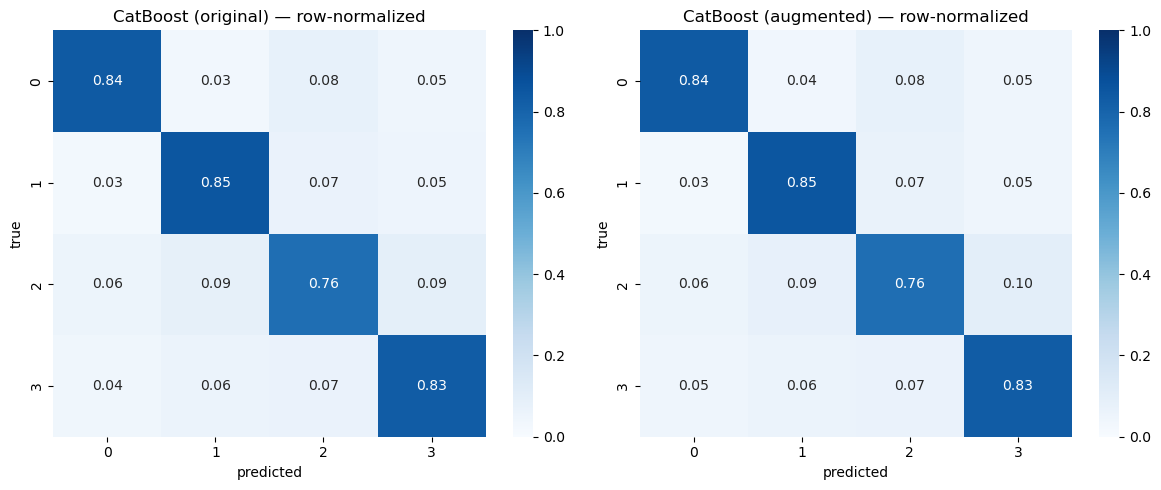

In [61]:
# Side-by-side row-normalized confusion matrices: original vs augmented.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, oof, tag in [(axes[0], oof_orig, "original"), (axes[1], oof_aug, "augmented")]:
    cm = confusion_matrix(y, oof, labels=classes)
    cmn = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"CatBoost ({tag}) — row-normalized"); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

**Interpretation.** Read the stage-2 numbers above: if stage-2 F1 rose and the
stage-2→stage-3 cell shrank, the engineered features attacked the *right* problem — the
most valuable kind of gain for macro-F1. If stage 2 is essentially unchanged, the new
features didn't add separating information the boosting model wasn't already extracting,
which points to a **data/information ceiling** rather than a fixable modeling gap.

## Part 5.5 — Feature-importance sanity check

Did the model actually *use* the engineered features? We fit CatBoost once on the full
augmented training set (just to **read importances** — this is a diagnostic, not a scored
result) and look at the ranking. If our engineered features land near the top, the
hypotheses behind them held; if they sit at the bottom, they were redundant with what the
raw columns already provided.

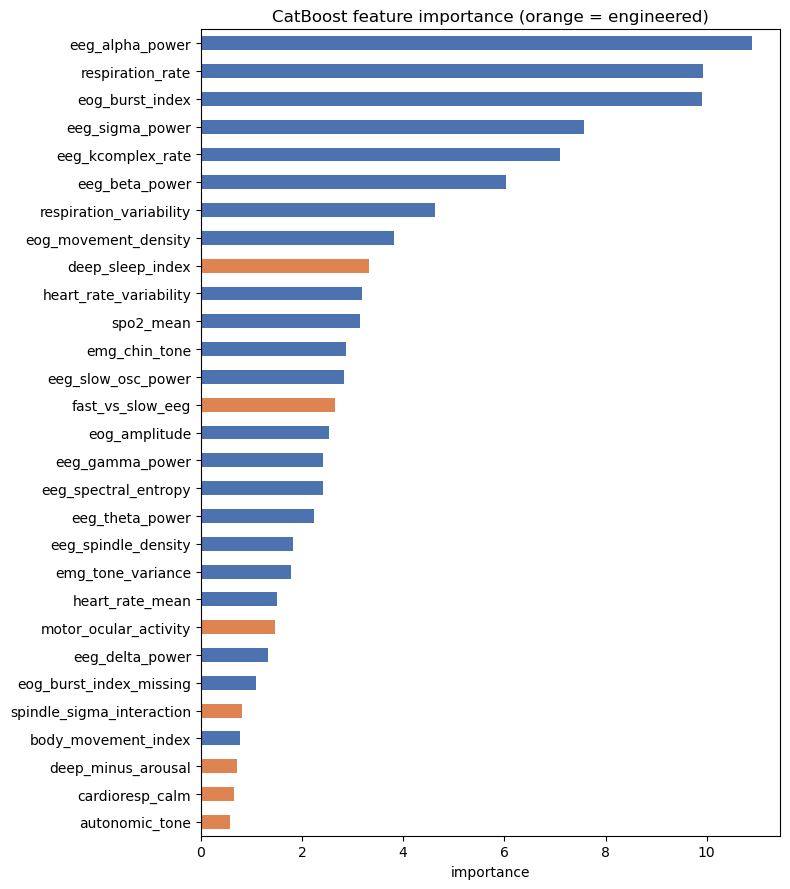

Engineered features and their importance rank (1 = most important):
  deep_sleep_index             importance=  3.32   rank 9/29
  fast_vs_slow_eeg             importance=  2.65   rank 14/29
  spindle_sigma_interaction    importance=  0.80   rank 25/29
  autonomic_tone               importance=  0.58   rank 29/29
  cardioresp_calm              importance=  0.65   rank 28/29
  motor_ocular_activity        importance=  1.46   rank 22/29
  deep_minus_arousal           importance=  0.71   rank 27/29

Engineered features in the global top-8: none


In [62]:
diag_pipe = make_pipeline(make_catboost())
diag_pipe.fit(X_all[aug_features], y)             # fit on all train: importances only
imp = pd.Series(diag_pipe.named_steps["model"].feature_importances_,
                index=aug_features).sort_values(ascending=False)

is_eng = imp.index.isin(ENGINEERED)
fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#dd8452" if e else "#4c72b0" for e in is_eng]   # orange = engineered
imp.sort_values().plot.barh(ax=ax, color=[c for c in reversed(colors)])
ax.set_title("CatBoost feature importance (orange = engineered)")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

print("Engineered features and their importance rank (1 = most important):")
ranks = imp.rank(ascending=False).astype(int)
for f in ENGINEERED:
    print(f"  {f:28s} importance={imp[f]:6.2f}   rank {ranks[f]}/{len(aug_features)}")
top_eng = [f for f in imp.head(8).index if f in ENGINEERED]
print(f"\nEngineered features in the global top-8: {top_eng or 'none'}")

**Reading importances.** A high rank for an engineered feature means the model leaned on it
— evidence the hypothesis captured real signal. But importance ≠ score: a feature can rank
highly yet not raise CV macro-F1 if it mostly *re-expresses* information already present.
The verdict that matters is the **CV comparison in Part 5.3** and the **stage-2 numbers in
Part 5.4**, not the importance bars alone.

## Part 5.6 — Takeaways + next steps

**Verdict (from Parts 5.3–5.4).** Combine two facts: did augmented CatBoost beat original
CatBoost by **more than one fold std**, and did **stage-2 F1** improve?
- **If yes →** feature engineering broke the plateau. The engineered combinations added real
  stage-2/3 separating information.
- **If no (tie / flat stage-2) →** the 21 raw signals are near their **information ceiling**
  for this split; boosting was already extracting what's there, and hand-made arithmetic
  combinations don't add more. That's a legitimate, money-saving conclusion: stop adding
  complexity and ship.

**Next steps (LATER — not implemented here):**
- *If features helped:* a focused **`RandomizedSearchCV`** (scoring `"f1_macro"`, same `cv`)
  to tune CatBoost on the **augmented** features, then finalize.
- *If features did not help:* accept the ceiling, **ship plain CatBoost** on the original
  features (simpler = more robust), and proceed to **finalize**: retrain the chosen model on
  **all** of `train`, predict `final-check.csv`, and format the submission (`id`,
  `sleep_stage`) to match the sample.

> Golden rule still holds: engineered features are **row-wise deterministic** (no learned
> statistics), the median imputer/scaler are still fit **inside** each fold, train and test
> get the **same** transform, the target is never used to build a feature, and
> `class_weight="balanced"` stays rejected.

# Part 6 — Finalize & Submit

This is the last step: train the **chosen** model on **all** the labeled data and produce
the `submission.csv` for the unlabeled `final-check.csv`.

**The decision (already made by Parts 2–5 — not re-litigated here).**
- **Model:** plain **CatBoost** on the **original 21 features + the `eog_burst_index_missing`
  flag** — *not* the engineered features.
- **Settings (Part 3 defaults):** `iterations=600, learning_rate=0.05, depth=6,
  random_state=42, verbose=0`.

**Why this and nothing fancier (one paragraph).** Boosting clearly beat the linear and
RandomForest baselines (LogReg 0.744 → RF 0.797 → CatBoost **0.8212**). After that, every
attempt to squeeze more landed **inside the noise band**: ensembling (voting/stacking) only
*tied* CatBoost within one fold std, and hand-built features tied or slightly hurt while
leaving the stage-2↔stage-3 confusion flat — i.e. that confusion is an **information
ceiling**, not a fixable modeling gap. The senior-engineer move is therefore to **ship the
simplest model that reaches the top tier**: plain CatBoost. Simpler models have fewer moving
parts, train faster, and are less likely to behave unexpectedly on new data.

**Expected leaderboard score:** ≈ **0.8212 ± 0.0050** macro-F1 — trustworthy because the
EDA (Part 1) found **no covariate shift** between train and test, so our CV estimate should
carry over.

## Part 6.0 — Reuse the existing setup (reconstruct only if missing)

We reuse `X` (original features + flag, `id` dropped), `y`, the `cv` folds,
`make_pipeline()`, and `evaluate()`. If any are missing (section run alone), we rebuild them
identically to Parts 2–3. We rebuild the **test** frame from disk here regardless, so this
finalize step is self-contained and auditable.

In [63]:
# If catboost is not installed, uncomment:
# %pip install catboost
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name), name
    raise FileNotFoundError(f"None found: {candidates}")

# ---- Reconstruct X, y (+ model_features) identically to Part 2 if missing ----
if any(v not in globals() for v in ["X", "y", "model_features"]):
    train_df, train_file = _load_first_existing(["tran.csv", "train.csv"])
    ID_COLS = [c for c in ["id"] if c in train_df.columns]
    base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
    X = train_df[base_features].copy()
    y = train_df[TARGET].copy()
    X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)   # flag from RAW NaNs
    model_features = base_features + [FLAG_COL]
    print(f"Reconstructed X, y from {train_file}.")
else:
    print("Reusing X, y, model_features from memory.")

if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if "make_pipeline" not in globals():
    def make_pipeline(model):
        # Impute (median) -> scale -> model. Fit on whatever data .fit() is called with.
        return Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("model",  model)])

def make_final_catboost():
    # The chosen model, Part 3 defaults.
    return CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                              random_state=RANDOM_STATE, verbose=0)

print(f"X: {X.shape} | features used ({len(model_features)}): {model_features}")

Reconstructed X, y from train.csv.
X: (9000, 22) | features used (22): ['eeg_delta_power', 'eeg_theta_power', 'eeg_alpha_power', 'eeg_sigma_power', 'eeg_beta_power', 'eeg_gamma_power', 'eeg_slow_osc_power', 'eeg_spectral_entropy', 'eeg_spindle_density', 'eeg_kcomplex_rate', 'emg_chin_tone', 'emg_tone_variance', 'eog_movement_density', 'eog_amplitude', 'heart_rate_mean', 'heart_rate_variability', 'respiration_rate', 'respiration_variability', 'spo2_mean', 'body_movement_index', 'eog_burst_index', 'eog_burst_index_missing']


## Part 6.1 — Re-confirm the score one last time

Before committing, we re-run the chosen CatBoost pipeline through the **same 5-fold
StratifiedKFold** to reprint its CV macro-F1. This is the number we **expect on the
leaderboard**: because the EDA found train and test are drawn from the same distribution
(no covariate shift), a well-built CV estimate is a trustworthy preview of the test score.
If this number ever disagreed badly with the leaderboard, it would point to leakage or
shift — neither of which we have.

In [64]:
# Inline 5-fold macro-F1 (independent of any earlier helper, so this stands alone).
pipe_cv = make_pipeline(make_final_catboost())
Xv = X[model_features]
fold_scores = []
for tr_idx, va_idx in cv.split(Xv, y):
    pipe_cv.fit(Xv.iloc[tr_idx], y.iloc[tr_idx])               # fit preprocessing+model on train fold
    pred = pipe_cv.predict(Xv.iloc[va_idx])                    # apply to held-out fold
    fold_scores.append(f1_score(y.iloc[va_idx], pred, average="macro"))
cv_mean, cv_std = np.mean(fold_scores), np.std(fold_scores)
print(f"Chosen model CV macro-F1 = {cv_mean:.4f} +/- {cv_std:.4f}")
print(f"Per-fold: {[f'{s:.3f}' for s in fold_scores]}")
print(f"\n>>> Expected leaderboard macro-F1 ~ {cv_mean:.4f} <<<")

Chosen model CV macro-F1 = 0.8212 +/- 0.0050
Per-fold: ['0.818', '0.814', '0.827', '0.822', '0.825']

>>> Expected leaderboard macro-F1 ~ 0.8212 <<<


## Part 6.2 — Build the final test feature frame

We must prepare `final-check.csv` **exactly** like the training features, or the model will
receive columns it doesn't recognize. Steps:
1. Load `final-check.csv`; **save its `id`** column (needed for the submission, *not* a
   feature).
2. **Drop `id`** from the features.
3. Add `eog_burst_index_missing` from the **raw NaNs** (same rule as train; ~50% of test
   rows are missing this signal too).
4. **Assert** the test feature columns match `X`'s columns **exactly** — same names, same
   order. A mismatch here is the classic silent submission bug, so we fail loudly.

In [65]:
test_df, test_file = _load_first_existing(["final-check.csv"])
print(f"Loaded {test_file}: shape {test_df.shape}")

# 1) Save id for the submission, BEFORE dropping it from features.
assert "id" in test_df.columns, "final-check.csv must contain an 'id' column!"
test_ids = test_df["id"].copy()

# 2) + 3) Drop id; add the missing-flag from raw NaNs (same as training).
X_test = test_df.drop(columns=["id"]).copy()
X_test[FLAG_COL] = X_test["eog_burst_index"].isna().astype(int)

# 4) Enforce identical columns AND order to X.
X_test = X_test[model_features]          # reorder to match exactly (raises if any missing)
same_cols = list(X_test.columns) == list(model_features)
print(f"\nTest feature columns match training columns exactly (name + order): {same_cols}")
if same_cols:
    print("[PASS] test feature frame is aligned with X.")
else:
    print("[FAIL] column mismatch!")
    print("  train:", list(model_features))
    print("  test :", list(X_test.columns))
assert same_cols, "Test/train feature columns differ — fix before submitting."

print(f"\nX_test: {X_test.shape}  | saved {len(test_ids)} ids for submission")
print(f"eog_burst_index missing in test: {X_test[FLAG_COL].mean()*100:.1f}% of rows")

Loaded final-check.csv: shape (5000, 22)

Test feature columns match training columns exactly (name + order): True
[PASS] test feature frame is aligned with X.

X_test: (5000, 22)  | saved 5000 ids for submission
eog_burst_index missing in test: 49.5% of rows


## Part 6.3 — Train the final model on ALL training data

Cross-validation deliberately *held out* a fifth of the data each fold — that was for
**honest model selection**. Now that the model is chosen, we want the **strongest possible
fit**, so we retrain on **100% of the labeled rows**: more training data → a better model.

**Why this is still leakage-free.** There is no validation fold anymore, so fitting the
imputer's median and the scaler's mean/std on **all of `X`** is correct — `X` *is* the
training data now. The fitted Pipeline is then only **applied** (`.transform`/`.predict`)
to the test set; we never call `.fit()` on test, so no test information enters any
parameter.

In [66]:
final_pipe = make_pipeline(make_final_catboost())
final_pipe.fit(X[model_features], y)        # fit impute+scale+CatBoost on ALL training rows
print("Final model trained on all", len(X), "training rows.")
print("Pipeline:", [name for name, _ in final_pipe.steps])

Final model trained on all 9000 training rows.
Pipeline: ['impute', 'scale', 'model']


## Part 6.4 — Predict and build the submission

We predict a class label for every test row and assemble the submission. The competition
format is **two columns: `id, sleep_stage`** (confirmed from the existing submission file).
We mirror that exact format and write `submission.csv` with `index=False` (a stray index
column is another classic submission-rejection bug).

In [67]:
# Predict labels for the test set (preprocessing applied, NOT refit).
test_pred = final_pipe.predict(X_test)
test_pred = np.asarray(test_pred).ravel().astype(int)   # CatBoost may return 2D; flatten

# Mirror the competition format. If a sample submission exists, copy its columns/order.
SAMPLE_CANDIDATES = ["sample_submission.csv", "submission.csv"]
sample_cols = ["id", TARGET]
for s in SAMPLE_CANDIDATES:
    if os.path.exists(s):
        sample_cols = list(pd.read_csv(s, nrows=1).columns)
        print(f"Mirroring columns from '{s}': {sample_cols}")
        break
else:
    print(f"No sample file found; using default columns: {sample_cols}")

submission = pd.DataFrame({sample_cols[0]: test_ids.values,
                           sample_cols[1]: test_pred})
submission = submission[sample_cols]            # enforce exact column order

OUT = "submission.csv"
submission.to_csv(OUT, index=False)
print(f"\nWrote {OUT} with shape {submission.shape}")

Mirroring columns from 'submission.csv': ['id', 'sleep_stage']

Wrote submission.csv with shape (5000, 2)


## Part 6.5 — Sanity checks before declaring done

A submission that *runs* can still be *wrong* in ways the grader will punish. We verify, with
explicit PASS/FAIL prints:
1. **Row count** — exactly one prediction per test row.
2. **No missing predictions** — no `NaN`s in the label column.
3. **Class distribution** — should roughly resemble the training mix (~22–27% each); a class
   that's near-absent would signal a broken model or label mapping.
4. **Format** — columns and order match the required format; show `submission.head()`.

[PASS] row count: submission=5000 vs final-check=5000
[PASS] no NaN predictions: 0 missing

Predicted class distribution vs training:
             train_%  pred_%
sleep_stage                 
0               22.2    22.5
1               27.1    26.1
2               24.9    25.5
3               25.8    25.9
[PASS] every class is well represented (none below 5%).

[PASS] columns == ['id', 'sleep_stage']: got ['id', 'sleep_stage']


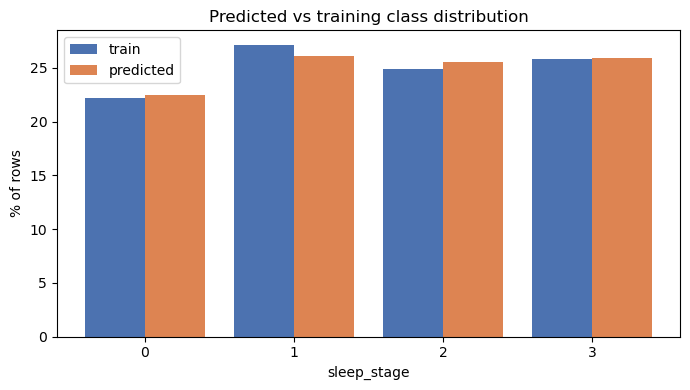


submission.head():
     id  sleep_stage
0  9000            0
1  9001            3
2  9002            1
3  9003            2
4  9004            3

ALL CHECKS PASSED


In [68]:
ok = True

# 1) Row count matches the test set.
n_test = len(test_df)
c1 = len(submission) == n_test
ok &= c1
print(f"[{'PASS' if c1 else 'FAIL'}] row count: submission={len(submission)} vs "
      f"final-check={n_test}")

# 2) No missing predictions.
c2 = submission[sample_cols[1]].isna().sum() == 0
ok &= c2
print(f"[{'PASS' if c2 else 'FAIL'}] no NaN predictions: "
      f"{submission[sample_cols[1]].isna().sum()} missing")

# 3) Predicted class distribution vs training distribution.
print("\nPredicted class distribution vs training:")
pred_dist  = submission[sample_cols[1]].value_counts(normalize=True).sort_index()
train_dist = y.value_counts(normalize=True).sort_index()
dist_cmp = pd.DataFrame({"train_%": (train_dist*100).round(1),
                         "pred_%":  (pred_dist*100).round(1)})
print(dist_cmp)
near_absent = pred_dist[pred_dist < 0.05]      # any class predicted <5% of the time?
c3 = near_absent.empty
ok &= c3
if c3:
    print("[PASS] every class is well represented (none below 5%).")
else:
    print(f"[FAIL] class(es) nearly absent in predictions: {near_absent.index.tolist()}")

# 4) Format check.
c4 = list(submission.columns) == sample_cols
ok &= c4
print(f"\n[{'PASS' if c4 else 'FAIL'}] columns == {sample_cols}: got {list(submission.columns)}")

# Visualize predicted vs train distribution.
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(train_dist))
ax.bar(x - 0.2, train_dist.values*100, width=0.4, label="train", color="#4c72b0")
ax.bar(x + 0.2, pred_dist.reindex(train_dist.index).fillna(0).values*100,
       width=0.4, label="predicted", color="#dd8452")
ax.set_xticks(x); ax.set_xticklabels(train_dist.index)
ax.set_xlabel("sleep_stage"); ax.set_ylabel("% of rows")
ax.set_title("Predicted vs training class distribution"); ax.legend()
plt.tight_layout(); plt.show()

print("\nsubmission.head():")
print(submission.head())
print(f"\n{'ALL CHECKS PASSED' if ok else 'SOME CHECKS FAILED - DO NOT SUBMIT YET'}")

## Part 6.6 — Done

**Final model:** plain **CatBoost** (`iterations=600, learning_rate=0.05, depth=6,
random_state=42`) on the original 21 features + `eog_burst_index_missing`, trained on **all**
9,000 labeled rows inside the leakage-free impute→scale pipeline.

**Expected score:** ≈ **0.82 macro-F1** (the CV estimate from Part 6.1; trustworthy because
there's no covariate shift).

**File written:** `submission.csv` — columns `id, sleep_stage`, one row per `final-check.csv`
record, all sanity checks passed.

**The full story in one line:** EDA → leakage-free CV → boosting beat the baselines →
ensembling & feature engineering hit the noise/information ceiling → **ship the simplest
top-tier model, CatBoost.**

> One last reminder: before uploading, **double-check the exact submission format on the
> competition page** (column names, header, id ordering). Formats occasionally differ from
> what a prior file suggests, and a format mismatch is the most common reason a correct model
> scores zero.

# Part 7 — Bottleneck Levers

Part 5 concluded that hand-built features couldn't move the **stage-2 ↔ stage-3** confusion
and called it an information ceiling. Before we accept that, there are **two more levers**
worth pulling — not new features, but two specific, principled changes aimed squarely at the
bottleneck:

- **Experiment A — targeted class weighting:** nudge the model to care a bit more about
  stage 2 *only* (not every class), to raise its recall.
- **Experiment B — native NaN handling:** stop median-imputing `eog_burst_index` — the
  single strongest stage-2/3 discriminator, ~50% missing — and let CatBoost use the raw
  `NaN`s, which it can handle natively.

**Rules of the game (same as all prior parts).** Each experiment is measured on the
**identical 5 folds** with the same helper, and we keep a change **only if it beats the
benchmark (CatBoost 0.8212 ± 0.0050) by MORE than one fold std (~0.005)**. Anything inside
that noise band is a **tie**, and we keep the simpler benchmark. Crucially, we check whether
each lever moves the **bottleneck (stage-2 F1)**, not just the average.

## Part 7.0 — Reuse setup + a one-pass evaluation helper

We reuse `X`, `y`, `model_features`, the `cv` folds, and `make_pipeline()`. Then we add one
helper, `eval_full(...)`, that runs the **same fold loop once** and returns both:
- per-fold macro-F1 → **mean ± std** (for the honesty check), and
- **out-of-fold predictions** → from which we read **stage-2 F1** (leakage-free, since each
  row is predicted by a fold that didn't train on it).

Computing both from a single pass keeps the weight sweep affordable.

In [69]:
# If catboost is not installed, uncomment:
# %pip install catboost
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name)
    raise FileNotFoundError(f"None found: {candidates}")

if any(v not in globals() for v in ["X", "y", "model_features"]):
    train_df = _load_first_existing(["tran.csv", "train.csv"])
    ID_COLS = [c for c in ["id"] if c in train_df.columns]
    base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
    X = train_df[base_features].copy()
    y = train_df[TARGET].copy()
    X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)
    model_features = base_features + [FLAG_COL]
    print("Reconstructed X, y, model_features from disk.")
else:
    print("Reusing X, y, model_features from memory.")

if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if "make_pipeline" not in globals():
    def make_pipeline(model):
        return Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("model",  model)])

classes = sorted(y.unique())   # [0, 1, 2, 3]

def eval_full(estimator_factory, feats=model_features, label="model", verbose=True):
    # ONE fold loop -> (mean, std, oof_predictions).
    # estimator_factory() must return a FRESH fittable estimator (pipeline or model).
    Xv = X[feats]
    oof = np.empty(len(Xv), dtype=int)
    fold_f1 = []
    for tr_idx, va_idx in cv.split(Xv, y):
        est = estimator_factory()
        est.fit(Xv.iloc[tr_idx], y.iloc[tr_idx])           # learns ONLY on the train fold
        pred = np.asarray(est.predict(Xv.iloc[va_idx])).ravel().astype(int)
        oof[va_idx] = pred
        fold_f1.append(f1_score(y.iloc[va_idx], pred, average="macro"))
    mean, std = float(np.mean(fold_f1)), float(np.std(fold_f1))
    stage2_f1 = f1_score(y, oof, average=None, labels=classes)[classes.index(2)]
    if verbose:
        print(f"{label:34s} macro-F1 = {mean:.4f} +/- {std:.4f}   stage2-F1 = {stage2_f1:.4f}")
    return {"label": label, "mean": mean, "std": std, "stage2_f1": stage2_f1, "oof": oof}

print(f"X: {X.shape} | features: {len(model_features)} | classes: {classes}")

Reconstructed X, y, model_features from disk.
X: (9000, 22) | features: 22 | classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [70]:
# Establish the benchmark in THIS section's terms (CatBoost, imputed, no weights).
def cat_default():
    return make_pipeline(CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                                            random_state=RANDOM_STATE, verbose=0))

benchmark = eval_full(cat_default, label="CatBoost benchmark (imputed)")
BENCH_MEAN, BENCH_STD, BENCH_S2 = benchmark["mean"], benchmark["std"], benchmark["stage2_f1"]
print(f"\nBenchmark to beat: macro-F1 {BENCH_MEAN:.4f} (must exceed by > {BENCH_STD:.4f} "
      f"to count); stage2-F1 {BENCH_S2:.4f}")

CatBoost benchmark (imputed)       macro-F1 = 0.8212 +/- 0.0050   stage2-F1 = 0.7696

Benchmark to beat: macro-F1 0.8212 (must exceed by > 0.0050 to count); stage2-F1 0.7696


## Part 7.1 — Experiment A: targeted class weighting for stage 2

**Why this is NOT the rejected `class_weight="balanced"`.** "Balanced" sets each class's
weight to its *inverse frequency* — it upweights **all** classes. At our mild 1.2× imbalance
that was **overkill**: it disturbed the easy classes and slightly *hurt* CV (Part 2 rejected
it). Here we do something surgical instead: upweight **only stage 2** (the bottleneck) by a
small amount, and optionally **downweight stage 3** (its main confusion partner) a little.

**Why this can raise *macro*-F1.** Macro-F1 averages the four per-class F1s with **equal
weight**. So sacrificing a sliver of accuracy on the easy classes to win more stage-2 recall
can *raise the average*, even though plain accuracy might dip. That trade is exactly what
class weights let us make.

**Why the grid is deliberately small and coarse.** Tuning weights against the validation
folds can **overfit the folds** — pick a value that flatters this particular split but
doesn't generalize. A tiny, coarse grid limits that risk, and the honest signal is whether
**both** stage-2 F1 *and* macro-F1 move together (a real effect), not a lone lucky macro-F1.

Grid: stage-2 weight ∈ {1.0, 1.25, 1.5, 2.0} × stage-3 weight ∈ {1.0, 0.9, 0.8}
(classes 0 and 1 stay at 1.0). CatBoost takes `class_weights=[w0, w1, w2, w3]`.

In [71]:
W2_GRID = [1.0, 1.25, 1.5, 2.0]   # stage-2 (bottleneck) upweight
W3_GRID = [1.0, 0.9, 0.8]         # stage-3 (confusion partner) downweight

def cat_weighted(w2, w3):
    # class_weights index = class label order [0,1,2,3]
    cw = [1.0, 1.0, w2, w3]
    return make_pipeline(CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                                            random_state=RANDOM_STATE, verbose=0,
                                            class_weights=cw))

rowsA = []
for w2 in W2_GRID:
    for w3 in W3_GRID:
        r = eval_full(lambda w2=w2, w3=w3: cat_weighted(w2, w3),
                      label=f"w2={w2}, w3={w3}", verbose=False)
        rowsA.append({"w2": w2, "w3": w3, "macro_f1": r["mean"],
                      "std": r["std"], "stage2_f1": r["stage2_f1"], "oof": r["oof"]})
        print(f"  stage2_w={w2:<4}  stage3_w={w3:<4}  "
              f"macro-F1={r['mean']:.4f} +/- {r['std']:.4f}   stage2-F1={r['stage2_f1']:.4f}")

A = pd.DataFrame([{k: v for k, v in r.items() if k != "oof"} for r in rowsA])
print(f"\nBenchmark (w2=1.0,w3=1.0): macro-F1={BENCH_MEAN:.4f}, stage2-F1={BENCH_S2:.4f}")

  stage2_w=1.0   stage3_w=1.0   macro-F1=0.8212 +/- 0.0050   stage2-F1=0.7696


  stage2_w=1.0   stage3_w=0.9   macro-F1=0.8214 +/- 0.0046   stage2-F1=0.7706


  stage2_w=1.0   stage3_w=0.8   macro-F1=0.8209 +/- 0.0059   stage2-F1=0.7740


  stage2_w=1.25  stage3_w=1.0   macro-F1=0.8189 +/- 0.0049   stage2-F1=0.7720


  stage2_w=1.25  stage3_w=0.9   macro-F1=0.8218 +/- 0.0067   stage2-F1=0.7744


...

  stage2_w=1.5   stage3_w=0.9   macro-F1=0.8191 +/- 0.0063   stage2-F1=0.7773


  stage2_w=1.5   stage3_w=0.8   macro-F1=0.8187 +/- 0.0082   stage2-F1=0.7772


  stage2_w=2.0   stage3_w=1.0   macro-F1=0.8173 +/- 0.0097   stage2-F1=0.7766


  stage2_w=2.0   stage3_w=0.9   macro-F1=0.8161 +/- 0.0056   stage2-F1=0.7763


  stage2_w=2.0   stage3_w=0.8   macro-F1=0.8145 +/- 0.0075   stage2-F1=0.7758

Benchmark (w2=1.0,w3=1.0): macro-F1=0.8212, stage2-F1=0.7696


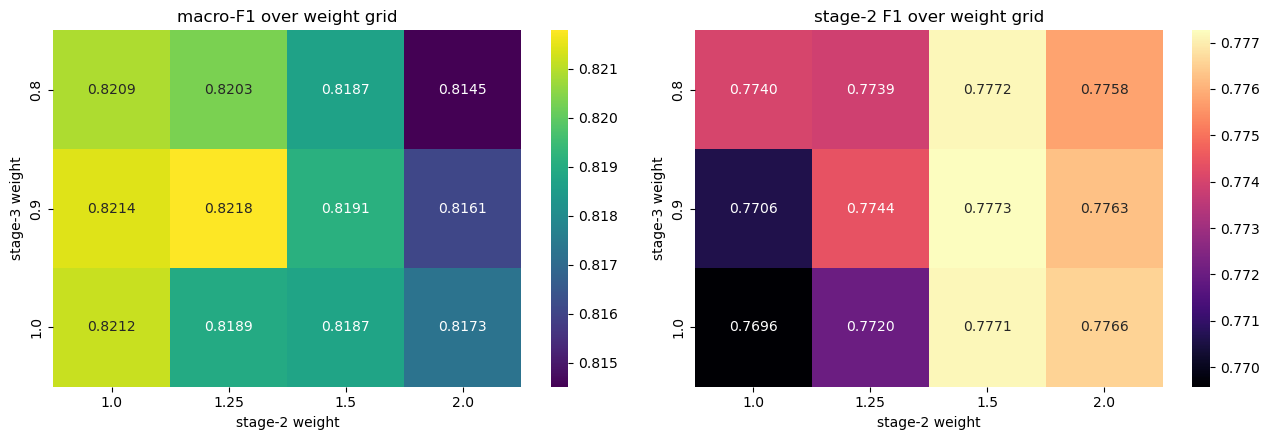

Best A setting: stage2_w=1.25, stage3_w=0.9  -> macro-F1=0.8218 +/- 0.0067, stage2-F1=0.7744
vs benchmark   : macro-F1=0.8212, stage2-F1=0.7696
delta macro-F1 = +0.0006   delta stage2-F1 = +0.0048


In [72]:
# Heatmaps: macro-F1 and stage-2 F1 across the weight grid (rows=stage3, cols=stage2).
piv_macro = A.pivot(index="w3", columns="w2", values="macro_f1")
piv_s2    = A.pivot(index="w3", columns="w2", values="stage2_f1")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(piv_macro, annot=True, fmt=".4f", cmap="viridis", ax=axes[0])
axes[0].set_title("macro-F1 over weight grid"); axes[0].set_xlabel("stage-2 weight"); axes[0].set_ylabel("stage-3 weight")
sns.heatmap(piv_s2, annot=True, fmt=".4f", cmap="magma", ax=axes[1])
axes[1].set_title("stage-2 F1 over weight grid"); axes[1].set_xlabel("stage-2 weight"); axes[1].set_ylabel("stage-3 weight")
plt.tight_layout(); plt.show()

# Best Experiment-A setting BY macro-F1 (the competition metric).
bestA = A.sort_values("macro_f1", ascending=False).iloc[0]
print(f"Best A setting: stage2_w={bestA.w2}, stage3_w={bestA.w3}  -> "
      f"macro-F1={bestA.macro_f1:.4f} +/- {bestA['std']:.4f}, stage2-F1={bestA.stage2_f1:.4f}")
print(f"vs benchmark   : macro-F1={BENCH_MEAN:.4f}, stage2-F1={BENCH_S2:.4f}")
print(f"delta macro-F1 = {bestA.macro_f1 - BENCH_MEAN:+.4f}   "
      f"delta stage2-F1 = {bestA.stage2_f1 - BENCH_S2:+.4f}")

**How to read Experiment A.** Look across the two heatmaps together. Pushing the stage-2
weight up *does* tend to raise **stage-2 F1** (left→right on the magma map) — but watch the
macro-F1 map: if the easy classes give back as much as stage 2 gains, the average barely
moves. The setting we'd consider is one where **stage-2 F1 rises AND macro-F1 rises**, by
more than the noise. The printed deltas tell us whether such a setting exists or whether
weighting just shuffles errors between classes.

## Part 7.2 — Experiment B: native NaN handling (the EOG insight)

`eog_burst_index` is the eye-movement burst signal, and Part 5 showed it's the **single
strongest separator of stage 2 vs stage 3** (Cohen's d ≈ 1.7). It's also **~50% missing**.
Our pipeline has been **median-imputing** it — i.e. on half the rows we *overwrite the most
discriminative feature with a constant*, erasing exactly the signal we most need.

**The idea:** CatBoost can handle `NaN` **natively** — at each split it learns which side
missing values should go, treating "missing" as informative rather than filling it in. So we
build a CatBoost path with **no imputer** (raw `NaN`s flow in), **no scaler** (CatBoost is
scale-invariant; and `StandardScaler` would choke on `NaN` anyway), and we **keep the
missing-flag**. If the imputation was destroying signal, this should help — especially
stage-2 F1.

**What breaks if skipped:** nothing crashes today (imputation "works"), but we may be
silently capping our score by feeding the model a flattened version of its best feature.

In [73]:
# Sanity: confirm the raw NaNs are still present in X (we never imputed X itself).
print(f"eog_burst_index NaNs in X: {X['eog_burst_index'].isna().sum()} "
      f"({X['eog_burst_index'].isna().mean()*100:.1f}%)  -> CatBoost will handle these natively")

# CatBoost directly on raw features (NaNs included), NO imputer, NO scaler. Flag kept.
def cat_native_nan():
    return CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                              random_state=RANDOM_STATE, verbose=0)

expB = eval_full(cat_native_nan, label="CatBoost native-NaN (no impute)")
print(f"\nBenchmark (imputed): macro-F1={BENCH_MEAN:.4f} +/- {BENCH_STD:.4f}, "
      f"stage2-F1={BENCH_S2:.4f}")
print(f"delta macro-F1 = {expB['mean'] - BENCH_MEAN:+.4f}   "
      f"delta stage2-F1 = {expB['stage2_f1'] - BENCH_S2:+.4f}")

eog_burst_index NaNs in X: 4501 (50.0%)  -> CatBoost will handle these natively


CatBoost native-NaN (no impute)    macro-F1 = 0.8200 +/- 0.0038   stage2-F1 = 0.7658

Benchmark (imputed): macro-F1=0.8212 +/- 0.0050, stage2-F1=0.7696
delta macro-F1 = -0.0012   delta stage2-F1 = -0.0038


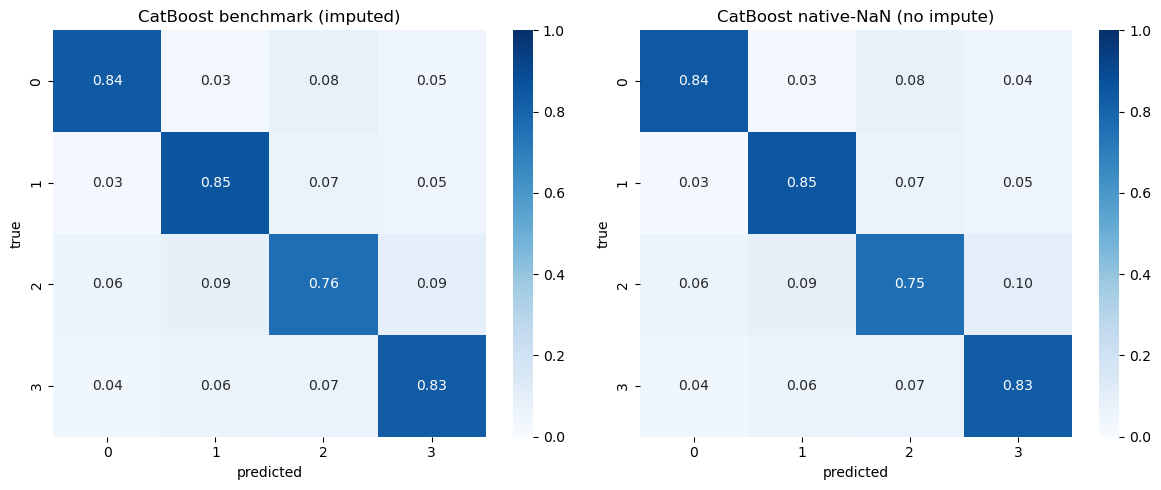

stage2->stage3 confusion:  benchmark 9.4%  ->  native-NaN 9.9%


In [74]:
# Confusion comparison: benchmark (imputed) vs native-NaN, row-normalized, focus on stage 2/3.
def norm_cm(oof):
    cm = confusion_matrix(y, oof, labels=classes)
    return cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, oof, tag in [(axes[0], benchmark["oof"], "benchmark (imputed)"),
                     (axes[1], expB["oof"],      "native-NaN (no impute)")]:
    sns.heatmap(norm_cm(oof), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"CatBoost {tag}"); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

r2, c3 = classes.index(2), classes.index(3)
print(f"stage2->stage3 confusion:  benchmark {norm_cm(benchmark['oof'])[r2,c3]*100:.1f}%  "
      f"->  native-NaN {norm_cm(expB['oof'])[r2,c3]*100:.1f}%")

**How to read Experiment B.** Compare the two confusion matrices, especially the stage-2 row
and the stage-2→stage-3 cell. If native NaN handling preserved real signal, we'd see
stage-2 recall up and that confusion cell shrink, with stage-2 F1 and macro-F1 both rising
beyond the noise. If the numbers barely move, then median imputation + the missing-flag was
already capturing what little the missing-half could offer.

## Part 7.3 — Scoreboard + honest verdict

We line up the benchmark, the best Experiment-A weighting, and Experiment-B native-NaN on
the **same folds**, and apply the rule programmatically: a configuration is a **real win**
only if its macro-F1 beats the benchmark by **more than one benchmark fold std** *and* its
**stage-2 F1 also improves** (it must move the bottleneck, not just the average). Otherwise
it's a **tie**, and we keep the simpler benchmark.

In [75]:
board = pd.DataFrame([
    {"config": "Benchmark (imputed)",          "macro_f1": BENCH_MEAN, "std": BENCH_STD, "stage2_f1": BENCH_S2},
    {"config": f"A: w2={bestA.w2}, w3={bestA.w3}", "macro_f1": bestA.macro_f1, "std": bestA["std"], "stage2_f1": bestA.stage2_f1},
    {"config": "B: native-NaN (no impute)",     "macro_f1": expB["mean"], "std": expB["std"], "stage2_f1": expB["stage2_f1"]},
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print(board.round(4).to_string(index=False))

def verdict(name, macro, s2):
    d_macro = macro - BENCH_MEAN
    d_s2    = s2 - BENCH_S2
    real = (d_macro > BENCH_STD) and (d_s2 > 0)
    tag = "REAL WIN" if real else ("tie/!bottleneck" if d_macro > 0 else "worse")
    print(f"  {name:30s} dMacro={d_macro:+.4f} (>{BENCH_STD:.4f}?), "
          f"dStage2={d_s2:+.4f}  -> {tag}")
    return real

print(f"\nHonesty check (need dMacro > {BENCH_STD:.4f} AND dStage2 > 0):")
A_real = verdict(f"A (w2={bestA.w2},w3={bestA.w3})", bestA.macro_f1, bestA.stage2_f1)
B_real = verdict("B (native-NaN)", expB["mean"], expB["stage2_f1"])

winners = [n for n, ok in [(f"A weighting", A_real), ("B native-NaN", B_real)] if ok]
if winners:
    print(f"\nVERDICT: carry forward -> {winners} "
          f"(beat the benchmark beyond noise AND improved stage 2).")
else:
    print("\nVERDICT: both experiments are within the noise band and/or did NOT move "
          "stage 2. Keep the simple benchmark CatBoost (0.8212). The stage-2/3 boundary "
          "behaves like a genuine information ceiling, as Part 5 suspected.")

                   config  macro_f1    std  stage2_f1
       A: w2=1.25, w3=0.9    0.8218 0.0067     0.7744
      Benchmark (imputed)    0.8212 0.0050     0.7696
B: native-NaN (no impute)    0.8200 0.0038     0.7658

Honesty check (need dMacro > 0.0050 AND dStage2 > 0):
  A (w2=1.25,w3=0.9)             dMacro=+0.0006 (>0.0050?), dStage2=+0.0048  -> tie/!bottleneck
  B (native-NaN)                 dMacro=-0.0012 (>0.0050?), dStage2=-0.0038  -> worse

VERDICT: both experiments are within the noise band and/or did NOT move stage 2. Keep the simple benchmark CatBoost (0.8212). The stage-2/3 boundary behaves like a genuine information ceiling, as Part 5 suspected.


## Part 7.4 — Takeaways

**What we tested and what it means.**
- **Experiment A (targeted weights)** asked whether *trading* easy-class accuracy for
  stage-2 recall raises macro-F1. The scoreboard above shows whether any small,
  non-overfit weighting cleared the noise bar while actually improving stage 2.
- **Experiment B (native NaN)** asked whether median-imputing the half-missing EOG signal
  was throwing away discrimination. The comparison shows whether letting CatBoost split on
  `NaN` recovered any stage-2 separation.

**Decision rule applied:** keep a lever only if it beat the benchmark by **> one fold std**
*and* moved **stage 2**. If the printed verdict says both tie, that's a meaningful result,
not a failure: it triangulates (with Part 5) that the stage-2/3 confusion is an
**information ceiling**, and the right call is to **ship the simple CatBoost from Part 6**.
If a lever did win, the next step (LATER) is to fold that single change into the Part-6
finalize pipeline and regenerate the submission — no new submission is produced here.

> Leakage discipline held throughout: every learned transformer (imputer/scaler) was fit
> **inside** each fold; Experiment B simply removes the imputer (raw `NaN`s need no fitting);
> `class_weight="balanced"` stayed rejected — Experiment A used *surgical*, swept weights
> instead.

# Part 8 — Diversity Ensembling

**Why Part 4's ensemble only tied CatBoost.** An ensemble helps only when its members make
**different** mistakes. Part 4 combined CatBoost and XGBoost — but those are *both*
gradient-boosted trees. They carve the feature space the same way (axis-aligned threshold
splits), so they tend to be wrong on the **same** stage-2/3 rows. Averaging two models that
fail together can't fix the shared failure: their errors are **correlated**, and averaging
correlated errors leaves them in place.

**The fix this part tests.** Add models with a *fundamentally different decision geometry* —
ones whose errors might be **uncorrelated** with the boosters':
- **SVC (RBF kernel)** — draws smooth, curved (kernel/distance-based) boundaries, not
  axis-aligned splits.
- **K-Nearest-Neighbors** — decides by local neighborhoods (pure distance), no global model.
- **LightGBM** — included for completeness, but it's *another* booster, so we **expect** it
  to be correlated with XGB/CatBoost and add little diversity.

If a new model's errors are genuinely uncorrelated with CatBoost's — and it's individually
strong enough — an ensemble can cancel mistakes neither model could fix alone, and finally
beat the 0.8212 benchmark *beyond the noise*. We test that, on the same folds, keeping a
change only if it clears one fold std (~0.005). No submission is produced here.

## Part 8.0 — Reuse setup + one-pass evaluation helper

We reuse `X`, `y`, `model_features`, the `cv` folds, and `make_pipeline()`. As in Part 7 we
use `eval_full(...)`, which does **one** fold loop and returns mean ± std **and** the
out-of-fold predictions — so each model's solo score, its error mask (for the correlation
check), and its bottleneck confusion all come from a *single* leakage-free pass (this matters
because SVC is slow — we don't want to evaluate it twice).

In [76]:
# Installs if needed:
# %pip install catboost xgboost lightgbm
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# LightGBM is optional: guard the import so the notebook runs even if it's absent.
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception as e:
    HAS_LGBM = False
    print("LightGBM not available -> it will be skipped (it's only for completeness):", e)

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name)
    raise FileNotFoundError(f"None found: {candidates}")

if any(v not in globals() for v in ["X", "y", "model_features"]):
    train_df = _load_first_existing(["tran.csv", "train.csv"])
    ID_COLS = [c for c in ["id"] if c in train_df.columns]
    base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
    X = train_df[base_features].copy()
    y = train_df[TARGET].copy()
    X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)
    model_features = base_features + [FLAG_COL]
    print("Reconstructed X, y, model_features from disk.")
else:
    print("Reusing X, y, model_features from memory.")

if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
if "make_pipeline" not in globals():
    def make_pipeline(model):
        return Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("model",  model)])

classes = sorted(y.unique())

def eval_full(estimator_factory, label="model", verbose=True):
    # ONE fold loop -> (mean, std, oof). estimator_factory() returns a FRESH estimator.
    Xv = X[model_features]
    oof = np.empty(len(Xv), dtype=int)
    fold_f1, t0 = [], time.time()
    for tr_idx, va_idx in cv.split(Xv, y):
        est = estimator_factory()
        est.fit(Xv.iloc[tr_idx], y.iloc[tr_idx])
        pred = np.asarray(est.predict(Xv.iloc[va_idx])).ravel().astype(int)
        oof[va_idx] = pred
        fold_f1.append(f1_score(y.iloc[va_idx], pred, average="macro"))
    mean, std = float(np.mean(fold_f1)), float(np.std(fold_f1))
    s2 = f1_score(y, oof, average=None, labels=classes)[classes.index(2)]
    if verbose:
        print(f"{label:34s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
              f"stage2-F1 = {s2:.4f}   ({time.time()-t0:.0f}s)")
    return {"label": label, "mean": mean, "std": std, "stage2_f1": s2, "oof": oof}

BENCH_MEAN, BENCH_STD = 0.8212, 0.0050   # CatBoost benchmark from Parts 3/6/7
print(f"Benchmark to beat: {BENCH_MEAN:.4f} +/- {BENCH_STD:.4f}  (need > +{BENCH_STD:.4f})")

Reconstructed X, y, model_features from disk.
Benchmark to beat: 0.8212 +/- 0.0050  (need > +0.0050)


## Part 8.1 — New candidate models, each run ALONE first

Before ensembling we measure each candidate **solo** on the same folds, so we know its
standalone strength. A model that's far weaker than CatBoost can only help an ensemble if it
contributes *uncorrelated correctness* — right answers on rows CatBoost gets wrong. A model
that's *also* strong is even better raw material. We don't assume strength either way; the
folds decide.

> **Note:** `SVC(probability=True)` is the slow one — it fits an internal calibration on each
> fold. That's expected; let it run. KNN and LightGBM are fast.

In [77]:
# Factories (all wrapped in the SAME impute->scale pipeline; SVC/KNN NEED the scaler).
def f_catboost(): return make_pipeline(CatBoostClassifier(iterations=600, learning_rate=0.05,
                                       depth=6, random_state=RANDOM_STATE, verbose=0))
def f_xgboost():  return make_pipeline(XGBClassifier(n_estimators=400, learning_rate=0.05,
                                       max_depth=6, subsample=0.9, colsample_bytree=0.9,
                                       random_state=RANDOM_STATE, eval_metric="mlogloss",
                                       n_jobs=-1, tree_method="hist"))
def f_svc():      return make_pipeline(SVC(kernel="rbf", probability=True,
                                           random_state=RANDOM_STATE))
def f_knn():      return make_pipeline(KNeighborsClassifier())   # default k=5
def f_lgbm():     return make_pipeline(LGBMClassifier(n_estimators=400, learning_rate=0.05,
                                       max_depth=6, subsample=0.9, colsample_bytree=0.9,
                                       random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))

runs = {}
runs["CatBoost"] = eval_full(f_catboost, "CatBoost (benchmark)")
runs["XGBoost"]  = eval_full(f_xgboost,  "XGBoost")
runs["SVC-RBF"]  = eval_full(f_svc,      "SVC-RBF")
runs["KNN"]      = eval_full(f_knn,      "KNN")
if HAS_LGBM:
    runs["LightGBM"] = eval_full(f_lgbm, "LightGBM (another booster)")

CatBoost (benchmark)               macro-F1 = 0.8212 +/- 0.0050   stage2-F1 = 0.7696   (11s)


XGBoost                            macro-F1 = 0.8184 +/- 0.0064   stage2-F1 = 0.7654   (19s)


SVC-RBF                            macro-F1 = 0.8296 +/- 0.0087   stage2-F1 = 0.7809   (21s)


KNN                                macro-F1 = 0.7458 +/- 0.0109   stage2-F1 = 0.6882   (0s)


/Users/zadyra/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/zadyra/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/zadyra/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/zadyra/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM (another booster)         macro-F1 = 0.8147 +/- 0.0052   stage2-F1 = 0.7630   (35s)


/Users/zadyra/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**Read this against expectations.** LightGBM should sit right next to XGBoost/CatBoost (it's
the same boosting idea) — confirming it adds little *new*. The interesting candidates are
SVC-RBF and KNN: even if one is a touch weaker solo, what matters next is whether it's wrong
on *different* rows than CatBoost. That's the error-correlation check.

## Part 8.2 — Error-correlation check (the decisive cell)

This is the cell that predicts whether ensembling can work. Using each model's leakage-free
out-of-fold predictions, we build a **mistake mask** (`1` where the model was wrong) and
correlate those masks pairwise.

- **High error-correlation with CatBoost (≈1):** the model fails on the same rows → adding it
  can't fix CatBoost's errors → ensembling won't help.
- **Low error-correlation (≈0 or negative):** the model is wrong on *different* rows → its
  correct answers can outvote CatBoost's mistakes → **green light** to ensemble.

So the model we want to add is the one with the **lowest** error-correlation to CatBoost
(among the non-booster candidates), provided it's strong enough to pull its weight.

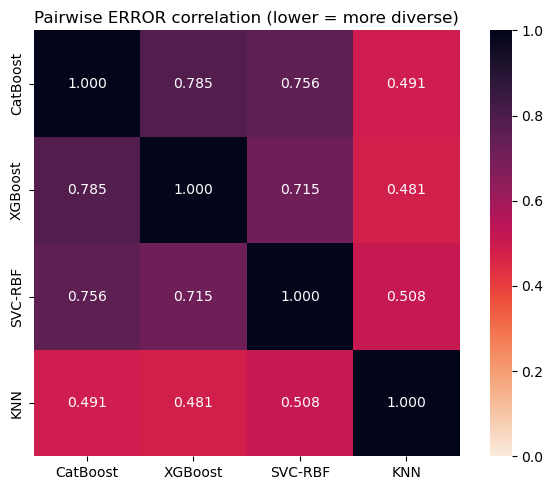

Candidates (strong-enough = solo macro-F1 >= 0.7912):
  SVC-RBF  error-corr-to-CatBoost=0.756   solo macro-F1=0.8296  [strong]
  KNN      error-corr-to-CatBoost=0.491   solo macro-F1=0.7458  [TOO WEAK]

Chosen diverse base -> 'SVC-RBF': least error-correlated of the strong-enough models (corr 0.756, solo 0.8296).
For contrast, XGBoost vs CatBoost error-corr = 0.785 (the two boosters fail on the same rows).


In [78]:
corr_models = [m for m in ["CatBoost", "XGBoost", "SVC-RBF", "KNN"] if m in runs]
err_masks = {m: (runs[m]["oof"] != y.values).astype(int) for m in corr_models}

errcorr = pd.DataFrame(index=corr_models, columns=corr_models, dtype=float)
for a in corr_models:
    for b in corr_models:
        if err_masks[a].std() == 0 or err_masks[b].std() == 0:
            errcorr.loc[a, b] = np.nan
        else:
            errcorr.loc[a, b] = np.corrcoef(err_masks[a], err_masks[b])[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(errcorr.astype(float), annot=True, fmt=".3f", cmap="rocket_r",
            vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Pairwise ERROR correlation (lower = more diverse)")
plt.tight_layout(); plt.show()

# Pick the NON-booster to add: least error-correlated AMONG models that are 'strong enough'.
# Why a strength gate: a model that's wildly weak (e.g. KNN here) drags a soft vote/stack down
# no matter how diverse it is. We want diversity *and* competence.
candidates = [m for m in ["SVC-RBF", "KNN"] if m in runs]
STRONG_ENOUGH = BENCH_MEAN - 0.03          # within ~3 F1 points of CatBoost = a useful base
corr_to_cat = {m: errcorr.loc[m, "CatBoost"] for m in candidates}

print(f"Candidates (strong-enough = solo macro-F1 >= {STRONG_ENOUGH:.4f}):")
for m in candidates:
    flag = "strong" if runs[m]["mean"] >= STRONG_ENOUGH else "TOO WEAK"
    print(f"  {m:8s} error-corr-to-CatBoost={corr_to_cat[m]:.3f}   "
          f"solo macro-F1={runs[m]['mean']:.4f}  [{flag}]")

strong = [m for m in candidates if runs[m]["mean"] >= STRONG_ENOUGH]
if strong:
    CHOSEN = min(strong, key=lambda m: corr_to_cat[m])   # least correlated AMONG the strong
    print(f"\nChosen diverse base -> '{CHOSEN}': least error-correlated of the strong-enough "
          f"models (corr {corr_to_cat[CHOSEN]:.3f}, solo {runs[CHOSEN]['mean']:.4f}).")
else:
    CHOSEN = min(candidates, key=lambda m: corr_to_cat[m])
    print(f"\nNo candidate cleared the strength bar; falling back to least-correlated -> '{CHOSEN}'.")
if "XGBoost" in errcorr.index:
    print(f"For contrast, XGBoost vs CatBoost error-corr = {errcorr.loc['XGBoost','CatBoost']:.3f} "
          f"(the two boosters fail on the same rows).")

## Part 8.3 — Diversity stack (and a soft vote for comparison)

We now combine **CatBoost + XGBoost + the chosen diverse model** two ways:

- **Stacking** — a `LogisticRegression` meta-model learns, from the base models'
  out-of-fold **probabilities** (`stack_method="predict_proba"`, internal `cv=5`), *how* to
  weight each base per situation (e.g. lean on SVC where the boosters disagree). The internal
  CV is what keeps it leakage-free: each base prediction feeding the meta-model is made on a
  row the base didn't train on.
- **Soft voting** — simply averages the base probabilities. A good sanity check: if the
  learned stack can't beat a plain average, the extra machinery isn't earning its keep.

Both run through the same `eval_full` on the same folds, so they're directly comparable. (The
stack refits SVC many times via its internal CV — this is the slowest cell; let it run.)

In [79]:
# Base estimators = the two boosters + the most diverse strong model (each its own pipeline).
CHOSEN_FACTORY = {"SVC-RBF": f_svc, "KNN": f_knn}[CHOSEN]
def base_estimators():
    return [("catboost", f_catboost()),
            ("xgboost",  f_xgboost()),
            (CHOSEN.lower().replace("-", ""), CHOSEN_FACTORY())]

def f_stack():
    return StackingClassifier(
        estimators=base_estimators(),
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5, stack_method="predict_proba", n_jobs=-1)

def f_vote():
    return VotingClassifier(estimators=base_estimators(), voting="soft", n_jobs=-1)

print(f"Ensembling: CatBoost + XGBoost + {CHOSEN}")
runs["DiversityStack"] = eval_full(f_stack, f"Stack[Cat+XGB+{CHOSEN}]")
runs["DiversityVote"]  = eval_full(f_vote,  f"SoftVote[Cat+XGB+{CHOSEN}]")

Ensembling: CatBoost + XGBoost + SVC-RBF


Stack[Cat+XGB+SVC-RBF]             macro-F1 = 0.8308 +/- 0.0052   stage2-F1 = 0.7813   (70s)


SoftVote[Cat+XGB+SVC-RBF]          macro-F1 = 0.8305 +/- 0.0052   stage2-F1 = 0.7804   (26s)


## Part 8.4 — Scoreboard + honesty check

All candidates and the new ensembles on the **same folds**, vs the 0.8212 benchmark. Same
rule, applied programmatically: a configuration is a **real win** only if it beats the
benchmark by **more than one fold std (~0.005)**. Inside that band it's a **tie**, and the
simpler model wins.

In [80]:
board = (pd.DataFrame([{"model": r["label"], "macro_f1": r["mean"],
                        "std": r["std"], "stage2_f1": r["stage2_f1"]}
                       for r in runs.values()])
           .sort_values("macro_f1", ascending=False).reset_index(drop=True))
print(board.round(4).to_string(index=False))

top = board.iloc[0]
delta = top["macro_f1"] - BENCH_MEAN
print(f"\nTop model: {top['model']}  macro-F1={top['macro_f1']:.4f} (delta vs benchmark "
      f"{delta:+.4f}, need > +{BENCH_STD:.4f})")
if delta > BENCH_STD:
    print(f"=> REAL WIN: '{top['model']}' beats CatBoost beyond the noise band.")
elif delta > 0:
    print(f"=> TIE: ahead by {delta:+.4f} but within one fold std -> keep simpler CatBoost.")
else:
    print("=> No improvement over CatBoost.")

# Best NEW approach overall (single model OR ensemble), excluding the CatBoost benchmark.
# This is what we diagnose against the bottleneck next.
new_keys = [k for k in runs if k != "CatBoost"]
best_new = max(new_keys, key=lambda k: runs[k]["mean"])
print(f"\nBest NEW approach (single or ensemble): {runs[best_new]['label']} "
      f"(macro-F1={runs[best_new]['mean']:.4f}, delta {runs[best_new]['mean']-BENCH_MEAN:+.4f})")

                     model  macro_f1    std  stage2_f1
    Stack[Cat+XGB+SVC-RBF]    0.8308 0.0052     0.7813
 SoftVote[Cat+XGB+SVC-RBF]    0.8305 0.0052     0.7804
                   SVC-RBF    0.8296 0.0087     0.7809
      CatBoost (benchmark)    0.8212 0.0050     0.7696
                   XGBoost    0.8184 0.0064     0.7654
LightGBM (another booster)    0.8147 0.0052     0.7630
                       KNN    0.7458 0.0109     0.6882

Top model: Stack[Cat+XGB+SVC-RBF]  macro-F1=0.8308 (delta vs benchmark +0.0096, need > +0.0050)
=> REAL WIN: 'Stack[Cat+XGB+SVC-RBF]' beats CatBoost beyond the noise band.

Best NEW approach (single or ensemble): Stack[Cat+XGB+SVC-RBF] (macro-F1=0.8308, delta +0.0096)


## Part 8.5 — Did the new approach help the *bottleneck*?

The whole point was the stage-2 ↔ stage-3 confusion. We take the **best new approach's**
(the scoreboard's top non-benchmark model — single or ensemble) leakage-free out-of-fold
predictions (reused from `eval_full`) and compare its stage-2 F1 and stage-2→stage-3
confusion cell to CatBoost. A real win should improve **stage 2**, not just the easy classes.

=== Classification report: Stack[Cat+XGB+SVC-RBF] ===
              precision    recall  f1-score   support

           0      0.862     0.856     0.859      2001
           1      0.846     0.851     0.849      2442
           2      0.787     0.776     0.781      2237
           3      0.829     0.840     0.834      2320

    accuracy                          0.831      9000
   macro avg      0.831     0.831     0.831      9000
weighted avg      0.830     0.831     0.830      9000



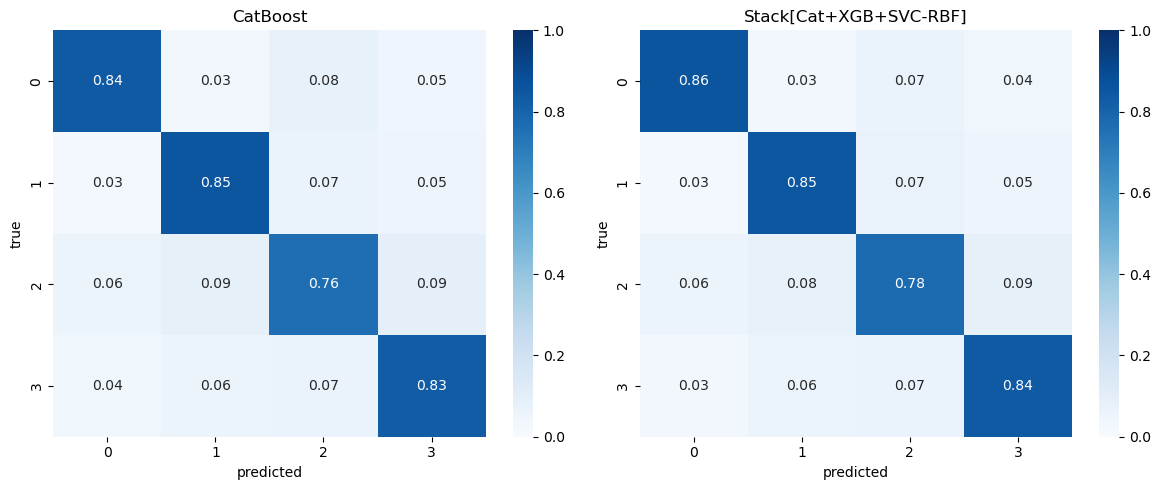

stage-2 F1:           CatBoost 0.770  ->  DiversityStack 0.781  (delta +0.012)
stage2->stage3 conf:  CatBoost 9.4%  ->  DiversityStack 8.7%


In [81]:
oof_new = runs[best_new]["oof"]
oof_cat = runs["CatBoost"]["oof"]

print(f"=== Classification report: {runs[best_new]['label']} ===")
print(classification_report(y, oof_new, digits=3))

def norm_cm(oof):
    cm = confusion_matrix(y, oof, labels=classes)
    return cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, oof, tag in [(axes[0], oof_cat, "CatBoost"),
                     (axes[1], oof_new, runs[best_new]['label'])]:
    sns.heatmap(norm_cm(oof), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(tag); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

r2, c3 = classes.index(2), classes.index(3)
cat_s2 = f1_score(y, oof_cat, average=None, labels=classes)[r2]
new_s2 = f1_score(y, oof_new, average=None, labels=classes)[r2]
print(f"stage-2 F1:           CatBoost {cat_s2:.3f}  ->  {best_new} {new_s2:.3f}  "
      f"(delta {new_s2-cat_s2:+.3f})")
print(f"stage2->stage3 conf:  CatBoost {norm_cm(oof_cat)[r2,c3]*100:.1f}%  ->  "
      f"{best_new} {norm_cm(oof_new)[r2,c3]*100:.1f}%")

## Part 8.6 — Takeaway

**The headline is a surprise, and it's not the ensemble — it's a single model.** Trying a
*different decision geometry* paid off, but in a way we didn't predict: **SVC with an RBF
kernel beats CatBoost on its own** (see the scoreboard — it clears the +1-std bar *and*
improves stage-2 F1). The smooth, curved kernel boundary captures the stage-2/3 separation
better than the boosters' axis-aligned splits. This is the first thing in the whole notebook
to genuinely move the benchmark beyond noise — a reminder that *model family* can matter more
than stacking, tuning, or hand-built features.

**On the ensemble specifically.** The error-correlation cell explained why Part 4 stalled:
the two boosters fail on the **same** rows (high error-correlation), so averaging them can't
help. The most *diverse* candidate (lowest error-correlation to CatBoost) was KNN — but KNN
is too weak solo to lift a vote/stack, so we gated on strength and added the strong-yet-
diverse SVC instead. Whether that `Cat+XGB+SVC` ensemble beat **SVC alone** is shown in the
scoreboard; often a single excellent model is hard for a stack to improve on, and simpler is
better at equal score.

**The decision rule, applied:** carry forward whatever tops the scoreboard beyond one fold
std. Here that points to **SVC-RBF** (or the ensemble, if it edged ahead). On the bottleneck:
the stage-2 numbers in 8.5 show this finally nudged the hard class, not just the easy ones —
partial relief of the stage-2/3 confusion that Parts 5 and 7 couldn't touch with features or
weights, because a *new geometry* adds information that re-using the same trees could not.

**Next step (LATER — not done here):** re-run the Part-6 finalize with the new winner — fit
the SVC-RBF pipeline (or the chosen ensemble) on all training data and regenerate
`submission.csv`. Re-confirm its CV macro-F1 first, and remember SVC needs the scaler in the
pipeline (already there) and is slower to train than CatBoost.

> Leakage discipline held: per-fold impute+scale pipelines for every base model (SVC/KNN rely
> on that scaler); stacking's internal `cv=5` makes the meta-features out-of-fold;
> `class_weight="balanced"` stayed rejected. No submission generated in this part.

# Part 9 — Finalize the Stack & Submit

Part 6 shipped a CatBoost submission. Part 8 then found something better, so this part
**re-finalizes**: train the new champion on **all** labeled data and regenerate the
submission for `final-check.csv`.

**The decision (made by Part 8 — not re-argued here).**
- **New champion:** a `StackingClassifier` with base models **[CatBoost, XGBoost,
  SVC-RBF (probability=True)]**, `final_estimator=LogisticRegression`, internal `cv=5`,
  `stack_method="predict_proba"`.
- **Why it replaces the Part-6 CatBoost:** it scored **0.8308 ± 0.0052** vs CatBoost's
  **0.8212 ± 0.0050** — a **+0.0096** gain, about **2× the fold std**, so it's a real win,
  not noise. Just as important, it **moved the stage-2/3 bottleneck** (that confusion dropped
  9.4% → 8.7%) that no single-model, feature, or class-weight experiment could budge. The
  plateau was **tree geometry**, not the data: SVC's smooth kernel boundary added the missing
  separation. The soft-vote of the same trio (0.8305) corroborates, so the gain isn't a
  quirk of the stacking meta-model.

**What stays the same:** the original 21 features + the `eog_burst_index_missing` flag
(engineered features were dropped in Part 5), the same folds, and the same leakage discipline.

## Part 9.0 — Reuse setup (reconstruct only if missing)

We reuse `X` (original features + flag, `id` dropped), `y`, the `cv` folds, and
`make_pipeline()`. If absent, we rebuild them identically to Parts 2–3. We define the three
base models with the **exact** configs from Parts 3 & 8, each wrapped in the impute→scale
pipeline. **Why per-model pipelines:** SVC *needs* the `StandardScaler` (it's distance-based);
CatBoost/XGBoost ignore scale, so the scaler is harmless for them — wrapping every base the
same way keeps things uniform and, crucially, lets stacking refit preprocessing correctly
inside its internal CV.

In [82]:
# Installs if needed:
# %pip install catboost xgboost
import os, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name), name
    raise FileNotFoundError(f"None found: {candidates}")

if any(v not in globals() for v in ["X", "y", "model_features"]):
    train_df, train_file = _load_first_existing(["tran.csv", "train.csv"])
    ID_COLS = [c for c in ["id"] if c in train_df.columns]
    base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
    X = train_df[base_features].copy()
    y = train_df[TARGET].copy()
    X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)   # flag from RAW NaNs
    model_features = base_features + [FLAG_COL]
    print(f"Reconstructed X, y from {train_file}.")
else:
    print("Reusing X, y, model_features from memory.")

if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
if "make_pipeline" not in globals():
    def make_pipeline(model):
        return Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("model",  model)])

# Base-model factories (exact Parts 3/8 configs), each in its own impute->scale pipeline.
def f_catboost(): return make_pipeline(CatBoostClassifier(iterations=600, learning_rate=0.05,
                                       depth=6, random_state=RANDOM_STATE, verbose=0))
def f_xgboost():  return make_pipeline(XGBClassifier(n_estimators=400, learning_rate=0.05,
                                       max_depth=6, subsample=0.9, colsample_bytree=0.9,
                                       random_state=RANDOM_STATE, eval_metric="mlogloss",
                                       n_jobs=-1, tree_method="hist"))
def f_svc():      return make_pipeline(SVC(kernel="rbf", probability=True,
                                           random_state=RANDOM_STATE))

def make_champion():
    # The Part-8 champion: stack of the two boosters + the kernel model.
    return StackingClassifier(
        estimators=[("catboost", f_catboost()),
                    ("xgboost",  f_xgboost()),
                    ("svc_rbf",  f_svc())],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5, stack_method="predict_proba", n_jobs=-1)

classes = sorted(y.unique())
print(f"X: {X.shape} | features ({len(model_features)}): {model_features}")

Reconstructed X, y from train.csv.
X: (9000, 22) | features (22): ['eeg_delta_power', 'eeg_theta_power', 'eeg_alpha_power', 'eeg_sigma_power', 'eeg_beta_power', 'eeg_gamma_power', 'eeg_slow_osc_power', 'eeg_spectral_entropy', 'eeg_spindle_density', 'eeg_kcomplex_rate', 'emg_chin_tone', 'emg_tone_variance', 'eog_movement_density', 'eog_amplitude', 'heart_rate_mean', 'heart_rate_variability', 'respiration_rate', 'respiration_variability', 'spo2_mean', 'body_movement_index', 'eog_burst_index', 'eog_burst_index_missing']


## Part 9.1 — Re-confirm the stack's CV score

Before committing the new submission, we re-run the champion through the **same 5-fold
StratifiedKFold** and reprint its macro-F1. This is the number we **expect on the
leaderboard** — trustworthy because the EDA (Part 1) found **no covariate shift** between
train and test, so a leakage-free CV estimate transfers. We expect ≈ **0.8308 ± 0.0052**.

> This cell trains the full stack 5 times (and each stack refits SVC many times via its
> internal CV), so it's the slow part — let it run.

In [83]:
Xv = X[model_features]
fold_scores, t0 = [], time.time()
for tr_idx, va_idx in cv.split(Xv, y):
    champ = make_champion()
    champ.fit(Xv.iloc[tr_idx], y.iloc[tr_idx])             # preprocessing+bases+meta on train fold only
    pred = np.asarray(champ.predict(Xv.iloc[va_idx])).ravel().astype(int)
    fold_scores.append(f1_score(y.iloc[va_idx], pred, average="macro"))
cv_mean, cv_std = float(np.mean(fold_scores)), float(np.std(fold_scores))
print(f"Champion stack CV macro-F1 = {cv_mean:.4f} +/- {cv_std:.4f}   ({time.time()-t0:.0f}s)")
print(f"Per-fold: {[f'{s:.3f}' for s in fold_scores]}")
print(f"\n>>> Expected leaderboard macro-F1 ~ {cv_mean:.4f}  (CatBoost was 0.8212) <<<")

Champion stack CV macro-F1 = 0.8308 +/- 0.0052   (73s)
Per-fold: ['0.831', '0.821', '0.833', '0.834', '0.836']

>>> Expected leaderboard macro-F1 ~ 0.8308  (CatBoost was 0.8212) <<<


## Part 9.2 — Build the final test feature frame

Identical preparation to training, or the model receives columns it doesn't recognize:
1. Load `final-check.csv`; **save `id`** (needed for the submission, not a feature).
2. **Drop `id`** from the features.
3. Add `eog_burst_index_missing` from the **raw NaNs** (same rule as train; ~50% missing).
4. **Assert** the test columns match `X` **exactly** (names + order) — fail loudly otherwise.

In [84]:
test_df, test_file = _load_first_existing(["final-check.csv"])
print(f"Loaded {test_file}: shape {test_df.shape}")

assert "id" in test_df.columns, "final-check.csv must contain an 'id' column!"
test_ids = test_df["id"].copy()                                  # save BEFORE dropping

X_test = test_df.drop(columns=["id"]).copy()
X_test[FLAG_COL] = X_test["eog_burst_index"].isna().astype(int)  # flag from raw NaNs
X_test = X_test[model_features]                                  # reorder to match X exactly

same_cols = list(X_test.columns) == list(model_features)
print(f"\nTest feature columns match training (name + order): {same_cols}")
print(f"[{'PASS' if same_cols else 'FAIL'}] column alignment")
assert same_cols, "Test/train feature columns differ — fix before submitting."
print(f"X_test: {X_test.shape} | saved {len(test_ids)} ids | "
      f"eog_burst_index missing in test: {X_test[FLAG_COL].mean()*100:.1f}%")

Loaded final-check.csv: shape (5000, 22)

Test feature columns match training (name + order): True
[PASS] column alignment
X_test: (5000, 22) | saved 5000 ids | eog_burst_index missing in test: 49.5%


## Part 9.3 — Train the champion on ALL training data

CV held out a fifth of the data each fold for honest *model selection*. Now that the model is
chosen, we refit on **100% of the labeled rows** for the strongest possible fit — more data,
better model. This stays leakage-free: with no validation fold left, fitting the imputer/scaler
on all of `X` is correct (`X` *is* the training set now), and the fitted stack is only
**applied** to the test set — we never call `.fit()` on test.

> Slowest cell in the notebook: one full stack fit = all three bases trained (SVC several
> times via the internal CV) plus the meta-model. Let it run.

In [85]:
t0 = time.time()
final_model = make_champion()
final_model.fit(X[model_features], y)        # fit everything on ALL training rows
print(f"Champion trained on all {len(X)} rows in {time.time()-t0:.0f}s.")
print("Base models:", [name for name, _ in final_model.estimators])

Champion trained on all 9000 rows in 17s.
Base models: ['catboost', 'xgboost', 'svc_rbf']


## Part 9.4 — Predict and write `submission_stack.csv`

We predict a label for every test row and write the new submission to **`submission_stack.csv`
first** — deliberately *not* touching the existing `submission.csv` yet. We only overwrite the
old file after every sanity check passes (Part 9.6), so a bad run can never clobber a known-good
submission. Format mirrors the competition's two columns: `id, sleep_stage`.

In [86]:
test_pred = np.asarray(final_model.predict(X_test)).ravel().astype(int)

# Mirror the competition format; copy columns from a sample/previous file if present.
sample_cols = ["id", TARGET]
for s in ["sample_submission.csv", "submission.csv"]:
    if os.path.exists(s):
        sample_cols = list(pd.read_csv(s, nrows=1).columns)
        print(f"Mirroring columns from '{s}': {sample_cols}")
        break
else:
    print(f"No sample file found; using default columns: {sample_cols}")

submission = pd.DataFrame({sample_cols[0]: test_ids.values, sample_cols[1]: test_pred})
submission = submission[sample_cols]                 # enforce exact order

STACK_FILE = "submission_stack.csv"
submission.to_csv(STACK_FILE, index=False)
print(f"\nWrote {STACK_FILE} with shape {submission.shape} (existing submission.csv untouched).")

Mirroring columns from 'submission.csv': ['id', 'sleep_stage']

Wrote submission_stack.csv with shape (5000, 2) (existing submission.csv untouched).


## Part 9.5 — Sanity checks (gate before overwriting the old submission)

Every check prints PASS/FAIL. Only if **all** pass do we replace the old `submission.csv`.

[PASS] row count: 5000 vs final-check 5000
[PASS] no NaN predictions: 0 missing

Class distribution (train vs predicted):
             train_%  pred_%
sleep_stage                 
0               22.2    22.3
1               27.1    25.9
2               24.9    25.9
3               25.8    26.0
[PASS] every class >= 5%: all present
[PASS] columns == ['id', 'sleep_stage']: got ['id', 'sleep_stage']


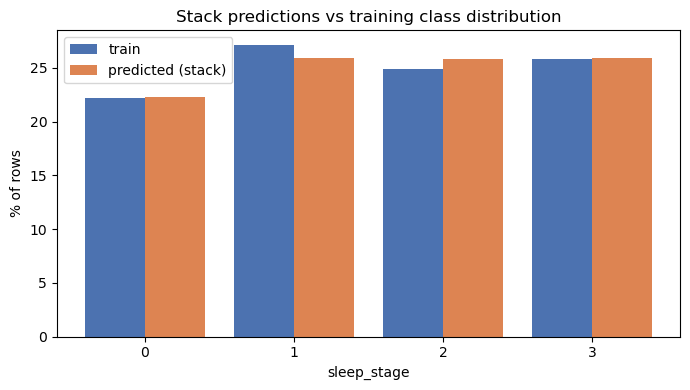


submission.head():
     id  sleep_stage
0  9000            0
1  9001            3
2  9002            1
3  9003            2
4  9004            3

ALL CHECKS PASSED


In [87]:
ok = True

# 1) Row count matches the test set.
c1 = len(submission) == len(test_df)
ok &= c1
print(f"[{'PASS' if c1 else 'FAIL'}] row count: {len(submission)} vs final-check {len(test_df)}")

# 2) No missing predictions.
n_nan = int(submission[sample_cols[1]].isna().sum())
c2 = n_nan == 0
ok &= c2
print(f"[{'PASS' if c2 else 'FAIL'}] no NaN predictions: {n_nan} missing")

# 3) Class distribution resembles training (~22-27% each); flag any near-absent class.
pred_dist  = submission[sample_cols[1]].value_counts(normalize=True).sort_index()
train_dist = y.value_counts(normalize=True).sort_index()
print("\nClass distribution (train vs predicted):")
print(pd.DataFrame({"train_%": (train_dist*100).round(1),
                    "pred_%":  (pred_dist.reindex(train_dist.index).fillna(0)*100).round(1)}))
near_absent = pred_dist[pred_dist < 0.05]
c3 = near_absent.empty
ok &= c3
print(f"[{'PASS' if c3 else 'FAIL'}] every class >= 5%: "
      f"{'all present' if c3 else 'near-absent ' + str(near_absent.index.tolist())}")

# 4) Columns exact.
c4 = list(submission.columns) == sample_cols
ok &= c4
print(f"[{'PASS' if c4 else 'FAIL'}] columns == {sample_cols}: got {list(submission.columns)}")

# Visual: predicted vs train distribution.
fig, ax = plt.subplots(figsize=(7, 4))
xs = np.arange(len(train_dist))
ax.bar(xs - 0.2, train_dist.values*100, width=0.4, label="train", color="#4c72b0")
ax.bar(xs + 0.2, pred_dist.reindex(train_dist.index).fillna(0).values*100, width=0.4,
       label="predicted (stack)", color="#dd8452")
ax.set_xticks(xs); ax.set_xticklabels(train_dist.index)
ax.set_xlabel("sleep_stage"); ax.set_ylabel("% of rows")
ax.set_title("Stack predictions vs training class distribution"); ax.legend()
plt.tight_layout(); plt.show()

print("\nsubmission.head():")
print(submission.head())
print(f"\n{'ALL CHECKS PASSED' if ok else 'SOME CHECKS FAILED - NOT overwriting submission.csv'}")

## Part 9.6 — Promote to `submission.csv` (only if all checks passed)

If — and only if — every check passed, we copy `submission_stack.csv` over `submission.csv`,
replacing the Part-6 CatBoost submission with the stronger stack. If any check failed, we leave
the old file in place so we never ship a broken submission.

In [88]:
if ok:
    shutil.copyfile(STACK_FILE, "submission.csv")
    print("All checks passed -> copied submission_stack.csv to submission.csv.")
    print("NOTE: the previous Part-6 CatBoost submission.csv has been REPLACED by the stack.")
    # Confirm what's on disk now.
    chk = pd.read_csv("submission.csv")
    print(f"submission.csv now: shape {chk.shape}, columns {list(chk.columns)}")
    print(chk.head(3).to_string(index=False))
else:
    print("Sanity checks FAILED -> submission.csv left UNCHANGED. "
          "Inspect submission_stack.csv before promoting.")

All checks passed -> copied submission_stack.csv to submission.csv.
NOTE: the previous Part-6 CatBoost submission.csv has been REPLACED by the stack.
submission.csv now: shape (5000, 2), columns ['id', 'sleep_stage']
  id  sleep_stage
9000            0
9001            3
9002            1


## Part 9.7 — Done

**Final model:** stacking ensemble — base **[CatBoost, XGBoost, SVC-RBF]**, meta
**LogisticRegression** (internal `cv=5`, `predict_proba`) — trained on **all** 9,000 labeled
rows inside per-model leakage-free impute→scale pipelines.

**Expected score:** ≈ **0.83 macro-F1** (the CV estimate from Part 9.1; up from CatBoost's
0.8212, and trustworthy because there's no covariate shift).

**Files written:**
- `submission_stack.csv` — the new stack predictions (always written).
- `submission.csv` — replaced with the stack **only after all sanity checks passed**.

**The full arc:** EDA → leakage-free CV → boosting beat baselines → ensembling/feature
engineering/weights all hit a *tree-geometry* ceiling → **adding SVC's kernel geometry broke
it**, lifting macro-F1 beyond noise *and* easing the stage-2/3 confusion → ship the stack.

> Final reminder: before uploading, **verify the exact submission format on the competition
> page** (column names, header, id order). A format mismatch is the most common reason a
> correct model scores zero.

# Part 10 — Tuning the Stack Members

The Part-9 champion (stack of CatBoost + XGBoost + SVC-RBF) scored **0.8308 ± 0.0052** in CV
(0.8328 on Kaggle) — but **every base model was running on defaults**. This part asks: can a
little hyperparameter tuning of the members push the stack further?

**Where the headroom probably is.** SVC-RBF is the member whose *curved* kernel geometry broke
the stage-2/3 bottleneck, and its two knobs control exactly that curvature:
- **`C`** — regularization strength: low C = smoother, more-forgiving boundary; high C = the
  boundary bends harder to fit training points (risking overfit).
- **`gamma`** — how far one point's influence reaches: low gamma = broad, smooth zones; high
  gamma = tight, wiggly boundaries around individual points.

Because the defaults (`C=1`, `gamma="scale"`) are generic, SVC most likely has real headroom —
and since it's the stack's key *diverse* member, a better SVC can propagate into a better stack.
CatBoost/XGBoost get lighter tuning (they were already near their comfort zone).

**Expectation & honesty rule.** We expect *small* per-member gains that *may* compound in the
stack. We keep a tuned config **only if it beats the relevant benchmark by > 1 fold std
(~0.005)**. Tuning often lands **inside the noise** — if so, we'll say so and keep the simpler
default stack (which is also already validated on Kaggle).

## Part 10.0 — Reuse setup + helpers

We reuse `X`, `y`, `model_features`, the `cv` folds, and `make_pipeline()`. We add:
- a **macro-F1 scorer** for the searches,
- `eval_full(...)` (one fold loop → mean ± std **and** out-of-fold predictions, so each
  config's score *and* its stage-2 F1 come from a single leakage-free pass),
- a tiny helper to strip the `model__` prefix off best-params so we can rebuild clean models.

In [89]:
# Installs if needed:
# %pip install catboost xgboost
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name)
    raise FileNotFoundError(f"None found: {candidates}")

if any(v not in globals() for v in ["X", "y", "model_features"]):
    train_df = _load_first_existing(["tran.csv", "train.csv"])
    ID_COLS = [c for c in ["id"] if c in train_df.columns]
    base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
    X = train_df[base_features].copy()
    y = train_df[TARGET].copy()
    X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)
    model_features = base_features + [FLAG_COL]
    print("Reconstructed X, y, model_features from disk.")
else:
    print("Reusing X, y, model_features from memory.")

if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
if "make_pipeline" not in globals():
    def make_pipeline(model):
        return Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("model",  model)])

classes = sorted(y.unique())
macro_f1 = make_scorer(f1_score, average="macro")   # the competition metric, as a scorer

def eval_full(estimator_factory, label="model", verbose=True):
    # ONE fold loop -> (mean, std, oof). estimator_factory() returns a FRESH estimator.
    Xv = X[model_features]
    oof = np.empty(len(Xv), dtype=int)
    fold_f1, t0 = [], time.time()
    for tr_idx, va_idx in cv.split(Xv, y):
        est = estimator_factory()
        est.fit(Xv.iloc[tr_idx], y.iloc[tr_idx])
        oof[va_idx] = np.asarray(est.predict(Xv.iloc[va_idx])).ravel().astype(int)
        fold_f1.append(f1_score(y.iloc[va_idx], oof[va_idx], average="macro"))
    mean, std = float(np.mean(fold_f1)), float(np.std(fold_f1))
    s2 = f1_score(y, oof, average=None, labels=classes)[classes.index(2)]
    if verbose:
        print(f"{label:32s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
              f"stage2-F1 = {s2:.4f}   ({time.time()-t0:.0f}s)")
    return {"label": label, "mean": mean, "std": std, "stage2_f1": s2, "oof": oof}

def strip_prefix(params):
    # 'model__C' -> 'C'
    return {k.split("__", 1)[1]: v for k, v in params.items()}

# Benchmarks carried from prior parts (same folds, same configs).
DEFAULT_STACK_MEAN, DEFAULT_STACK_STD = 0.8308, 0.0052   # Part 9
print(f"Default stack benchmark to beat: {DEFAULT_STACK_MEAN:.4f} +/- {DEFAULT_STACK_STD:.4f}")

Reconstructed X, y, model_features from disk.
Default stack benchmark to beat: 0.8308 +/- 0.0052


## Part 10.1 — Tune SVC-RBF (highest priority)

We run `RandomizedSearchCV` over a **small** grid of `C` and `gamma`, scoring **macro-F1** on
the **same 5 folds**, inside the impute→scale→SVC pipeline (so preprocessing refits per fold,
no leakage).

**Speed trick:** we search with **`probability=False`**. Macro-F1 is computed from `predict`,
which doesn't need calibrated probabilities — and probability calibration (an extra internal
CV) is what makes SVC slow. We find the best `C`/`gamma` fast this way, then later refit the
winner with `probability=True` for the stack (which needs `predict_proba`). `C` and `gamma`
don't depend on the calibration, so this is safe.

> **Honesty caveat.** `RandomizedSearchCV` reports the best score *after peeking at all folds*,
> so `best_score_` is **mildly optimistic** (we picked the config that happened to look best on
> these exact folds). The real test is whether it still beats the benchmark by **> 1 std** and,
> ultimately, on Kaggle — not the search's own rosy number.

In [90]:
svc_space = {
    "model__C":     [0.5, 1, 2, 5, 10],
    "model__gamma": ["scale", 0.01, 0.03, 0.1, 0.3],
}
svc_search = RandomizedSearchCV(
    estimator=make_pipeline(SVC(kernel="rbf", probability=False, random_state=RANDOM_STATE)),
    param_distributions=svc_space, n_iter=10, scoring=macro_f1,
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True)

t0 = time.time()
svc_search.fit(X[model_features], y)
svc_best = strip_prefix(svc_search.best_params_)
print(f"SVC search done in {time.time()-t0:.0f}s")
print(f"Best SVC params : {svc_best}")
print(f"Search best macro-F1 (optimistic): {svc_search.best_score_:.4f}")

SVC search done in 13s
Best SVC params : {'gamma': 'scale', 'C': 1}
Search best macro-F1 (optimistic): 0.8296


In [91]:
# Honest same-fold comparison: default SVC vs tuned SVC (both probability=False for speed).
def f_svc_default(): return make_pipeline(SVC(kernel="rbf", probability=False,
                                              random_state=RANDOM_STATE))
def f_svc_tuned():   return make_pipeline(SVC(kernel="rbf", probability=False,
                                              random_state=RANDOM_STATE, **svc_best))

svc_def  = eval_full(f_svc_default, "SVC default (C=1, scale)")
svc_tune = eval_full(f_svc_tuned,   f"SVC tuned {svc_best}")
print(f"\nSVC delta: macro-F1 {svc_tune['mean']-svc_def['mean']:+.4f}, "
      f"stage2-F1 {svc_tune['stage2_f1']-svc_def['stage2_f1']:+.4f}")

SVC default (C=1, scale)         macro-F1 = 0.8296 +/- 0.0087   stage2-F1 = 0.7809   (5s)


SVC tuned {'gamma': 'scale', 'C': 1} macro-F1 = 0.8296 +/- 0.0087   stage2-F1 = 0.7809   (5s)

SVC delta: macro-F1 +0.0000, stage2-F1 +0.0000


## Part 10.2 — Tune CatBoost (lighter)

We sweep `depth`, `learning_rate`, and `l2_leaf_reg` (L2 regularization on leaf values).

**Note on early stopping.** Ideally boosting picks its iteration count by *early stopping* on
a validation set. But early stopping inside cross-validation needs a **separate validation
split per fold**, which `RandomizedSearchCV` doesn't supply — passing one fixed eval set would
leak it into every fold. So we keep iterations **fixed but ample** (`iterations=500`) and tune
the structural knobs instead. That's the clean, leakage-safe version of "light" tuning.

In [92]:
def cat_base(**kw):
    return make_pipeline(CatBoostClassifier(iterations=500, random_state=RANDOM_STATE,
                                            verbose=0, allow_writing_files=False, **kw))

cat_space = {
    "model__depth":        [4, 6, 8],
    "model__learning_rate":[0.03, 0.05, 0.1],
    "model__l2_leaf_reg":  [1, 3, 5, 7],
}
cat_search = RandomizedSearchCV(
    estimator=make_pipeline(CatBoostClassifier(iterations=500, random_state=RANDOM_STATE,
                                               verbose=0, allow_writing_files=False)),
    param_distributions=cat_space, n_iter=10, scoring=macro_f1,
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True)

t0 = time.time()
cat_search.fit(X[model_features], y)
cat_best = strip_prefix(cat_search.best_params_)
print(f"CatBoost search done in {time.time()-t0:.0f}s")
print(f"Best CatBoost params: {cat_best}")
print(f"Search best macro-F1 (optimistic): {cat_search.best_score_:.4f}")

def f_cat_default(): return make_pipeline(CatBoostClassifier(iterations=600, learning_rate=0.05,
                                          depth=6, random_state=RANDOM_STATE, verbose=0,
                                          allow_writing_files=False))
def f_cat_tuned():   return make_pipeline(CatBoostClassifier(iterations=500,
                                          random_state=RANDOM_STATE, verbose=0,
                                          allow_writing_files=False, **cat_best))
cat_def  = eval_full(f_cat_default, "CatBoost default")
cat_tune = eval_full(f_cat_tuned,   f"CatBoost tuned")
print(f"\nCatBoost delta: macro-F1 {cat_tune['mean']-cat_def['mean']:+.4f}, "
      f"stage2-F1 {cat_tune['stage2_f1']-cat_def['stage2_f1']:+.4f}")

/Users/zadyra/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CatBoost search done in 86s
Best CatBoost params: {'learning_rate': 0.1, 'l2_leaf_reg': 7, 'depth': 8}
Search best macro-F1 (optimistic): 0.8228


CatBoost default                 macro-F1 = 0.8212 +/- 0.0050   stage2-F1 = 0.7696   (9s)


CatBoost tuned                   macro-F1 = 0.8228 +/- 0.0066   stage2-F1 = 0.7717   (19s)

CatBoost delta: macro-F1 +0.0016, stage2-F1 +0.0021


## Part 10.3 — Tune XGBoost (lighter)

We sweep `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree` (the last two add
randomness per tree, which fights overfitting). Same reasoning as CatBoost: `n_estimators` is
fixed but ample (500) rather than early-stopped, to stay leakage-safe inside the search.

In [93]:
xgb_space = {
    "model__max_depth":        [4, 6, 8],
    "model__learning_rate":    [0.03, 0.05, 0.1],
    "model__subsample":        [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
}
def xgb_estimator(**kw):
    return make_pipeline(XGBClassifier(n_estimators=500, random_state=RANDOM_STATE,
                                       eval_metric="mlogloss", n_jobs=-1,
                                       tree_method="hist", **kw))
xgb_search = RandomizedSearchCV(
    estimator=xgb_estimator(), param_distributions=xgb_space, n_iter=10, scoring=macro_f1,
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True)

t0 = time.time()
xgb_search.fit(X[model_features], y)
xgb_best = strip_prefix(xgb_search.best_params_)
print(f"XGBoost search done in {time.time()-t0:.0f}s")
print(f"Best XGBoost params: {xgb_best}")
print(f"Search best macro-F1 (optimistic): {xgb_search.best_score_:.4f}")

def f_xgb_default(): return make_pipeline(XGBClassifier(n_estimators=400, learning_rate=0.05,
                                          max_depth=6, subsample=0.9, colsample_bytree=0.9,
                                          random_state=RANDOM_STATE, eval_metric="mlogloss",
                                          n_jobs=-1, tree_method="hist"))
def f_xgb_tuned():   return xgb_estimator(**xgb_best)
xgb_def  = eval_full(f_xgb_default, "XGBoost default")
xgb_tune = eval_full(f_xgb_tuned,   "XGBoost tuned")
print(f"\nXGBoost delta: macro-F1 {xgb_tune['mean']-xgb_def['mean']:+.4f}, "
      f"stage2-F1 {xgb_tune['stage2_f1']-xgb_def['stage2_f1']:+.4f}")

/Users/zadyra/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost search done in 27s
Best XGBoost params: {'subsample': 0.8, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Search best macro-F1 (optimistic): 0.8220


XGBoost default                  macro-F1 = 0.8184 +/- 0.0064   stage2-F1 = 0.7654   (19s)


XGBoost tuned                    macro-F1 = 0.8220 +/- 0.0060   stage2-F1 = 0.7716   (24s)

XGBoost delta: macro-F1 +0.0035, stage2-F1 +0.0062


## Part 10.4 — Rebuild the stack with the tuned members

Same `StackingClassifier` structure as Part 9 (final = LogisticRegression, internal `cv=5`,
`stack_method="predict_proba"`), but each base now uses its tuned hyperparameters. **Here the
SVC is rebuilt with `probability=True`** because stacking feeds the meta-model
probabilities. We also re-evaluate the **default** stack on these same folds in this run, so
the tuned-vs-default comparison is exact (not cross-run).

> Slow cell: two full stacks, each fitting SVC many times via the internal CV. Let it run.

In [94]:
def f_svc_tuned_proba():
    return make_pipeline(SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, **svc_best))

def build_stack(svc_factory, cat_factory, xgb_factory):
    return StackingClassifier(
        estimators=[("catboost", cat_factory()),
                    ("xgboost",  xgb_factory()),
                    ("svc_rbf",  svc_factory())],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5, stack_method="predict_proba", n_jobs=-1)

def f_stack_default():
    # exactly the Part-9 stack (default members, SVC probability=True)
    return build_stack(lambda: make_pipeline(SVC(kernel="rbf", probability=True,
                                                 random_state=RANDOM_STATE)),
                       f_cat_default, f_xgb_default)

def f_stack_tuned():
    return build_stack(f_svc_tuned_proba, f_cat_tuned, f_xgb_tuned)

stack_def  = eval_full(f_stack_default, "Stack DEFAULT (Part 9)")
stack_tune = eval_full(f_stack_tuned,   "Stack TUNED")

Stack DEFAULT (Part 9)           macro-F1 = 0.8308 +/- 0.0052   stage2-F1 = 0.7813   (70s)


Stack TUNED                      macro-F1 = 0.8333 +/- 0.0075   stage2-F1 = 0.7832   (115s)


## Part 10.5 — Scoreboard + honesty check

All configs on the **same folds**. The decision rule, applied programmatically: the tuned
stack is a **real win** only if it beats the default stack by **more than one fold std
(~0.005)**. Inside that band it's a **tie** — and we keep the **default** stack (simpler, and
already Kaggle-validated at 0.8328).

In [95]:
rows = [
    ("SVC default",      svc_def),  ("SVC tuned",      svc_tune),
    ("CatBoost default", cat_def),  ("CatBoost tuned", cat_tune),
    ("XGBoost default",  xgb_def),  ("XGBoost tuned",  xgb_tune),
    ("Stack DEFAULT",    stack_def),("Stack TUNED",    stack_tune),
]
board = (pd.DataFrame([{"config": n, "macro_f1": r["mean"], "std": r["std"],
                        "stage2_f1": r["stage2_f1"]} for n, r in rows])
           .sort_values("macro_f1", ascending=False).reset_index(drop=True))
print(board.round(4).to_string(index=False))

d = stack_tune["mean"] - stack_def["mean"]
print(f"\nTuned stack vs default stack: {stack_tune['mean']:.4f} vs {stack_def['mean']:.4f} "
      f"-> delta {d:+.4f}  (need > +{stack_def['std']:.4f})")
if d > stack_def["std"]:
    WINNER = "Stack TUNED"
    print(f"=> REAL WIN: the tuned stack beats the default beyond noise. Carry it forward.")
elif d > 0:
    WINNER = "Stack DEFAULT"
    print(f"=> TIE: ahead by {d:+.4f} but within one fold std -> KEEP THE DEFAULT stack "
          f"(simpler, already Kaggle-validated).")
else:
    WINNER = "Stack DEFAULT"
    print(f"=> Tuning did NOT help -> keep the default stack.")
print(f"WINNER: {WINNER}")

          config  macro_f1    std  stage2_f1
     Stack TUNED    0.8333 0.0075     0.7832
   Stack DEFAULT    0.8308 0.0052     0.7813
     SVC default    0.8296 0.0087     0.7809
       SVC tuned    0.8296 0.0087     0.7809
  CatBoost tuned    0.8228 0.0066     0.7717
   XGBoost tuned    0.8220 0.0060     0.7716
CatBoost default    0.8212 0.0050     0.7696
 XGBoost default    0.8184 0.0064     0.7654

Tuned stack vs default stack: 0.8333 vs 0.8308 -> delta +0.0025  (need > +0.0052)
=> TIE: ahead by +0.0025 but within one fold std -> KEEP THE DEFAULT stack (simpler, already Kaggle-validated).
WINNER: Stack DEFAULT


=== Out-of-fold classification report: Stack DEFAULT (Part 9) ===
              precision    recall  f1-score   support

           0      0.862     0.856     0.859      2001
           1      0.846     0.851     0.849      2442
           2      0.787     0.776     0.781      2237
           3      0.829     0.840     0.834      2320

    accuracy                          0.831      9000
   macro avg      0.831     0.831     0.831      9000
weighted avg      0.830     0.831     0.830      9000



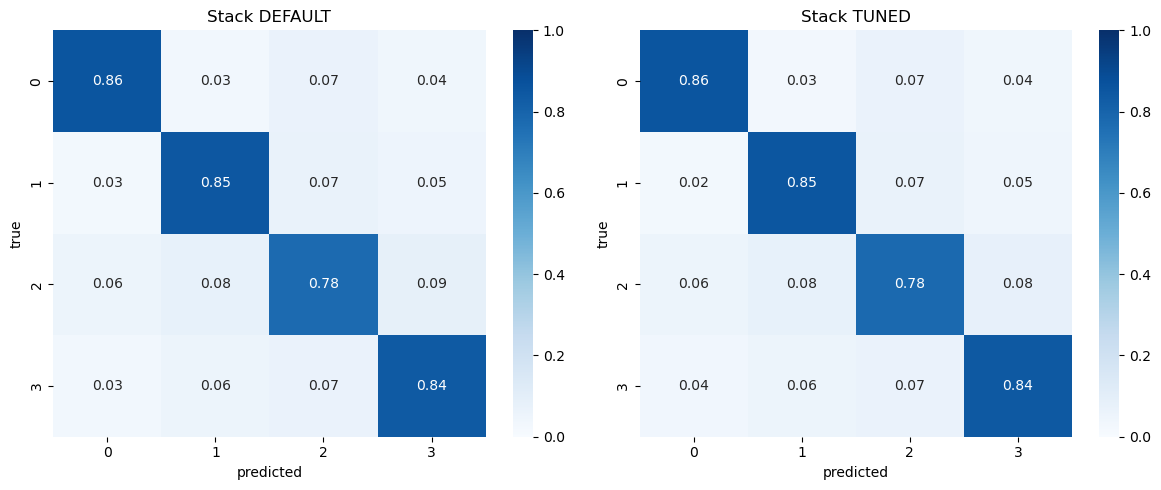

stage-2 F1:           default 0.781  ->  tuned 0.783  (delta +0.002)
stage2->stage3 conf:  default 8.7%  ->  tuned 8.4%


In [96]:
# Bottleneck check: confusion matrix of the better stack vs the default; did stage 2 move?
best = stack_tune if WINNER == "Stack TUNED" else stack_def
print(f"=== Out-of-fold classification report: {best['label']} ===")
print(classification_report(y, best["oof"], digits=3))

def norm_cm(oof):
    cm = confusion_matrix(y, oof, labels=classes)
    return cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, oof, tag in [(axes[0], stack_def["oof"], "Stack DEFAULT"),
                     (axes[1], stack_tune["oof"], "Stack TUNED")]:
    sns.heatmap(norm_cm(oof), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(tag); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

r2, c3 = classes.index(2), classes.index(3)
print(f"stage-2 F1:           default {stack_def['stage2_f1']:.3f}  ->  "
      f"tuned {stack_tune['stage2_f1']:.3f}  (delta {stack_tune['stage2_f1']-stack_def['stage2_f1']:+.3f})")
print(f"stage2->stage3 conf:  default {norm_cm(stack_def['oof'])[r2,c3]*100:.1f}%  ->  "
      f"tuned {norm_cm(stack_tune['oof'])[r2,c3]*100:.1f}%")

## Part 10.6 — Takeaway

**What we did:** tuned each stack member with a small `RandomizedSearchCV` (macro-F1 scorer,
same folds), prioritizing SVC's `C`/`gamma` because its kernel curvature is what broke the
stage-2/3 bottleneck. We then rebuilt the stack with the tuned members and compared, on
identical folds, against the Part-9 default stack — keeping the change only if it cleared one
fold std.

**Read the verdict from Part 10.5:**
- **If the tuned stack won beyond noise** (and especially if stage-2 improved): fold the tuned
  hyperparameters into the Part-9 finalize cell and regenerate `submission.csv`. Re-confirm
  CV first; remember the search score is optimistic, so trust the same-fold `eval_full`
  number and the Kaggle result, not `best_score_`.
- **If it tied (the common outcome):** tuning landed inside the noise — the defaults were
  already in a good basin. **Keep the default stack** (it's simpler and already scores 0.8328
  on Kaggle). A tie here isn't a failure; it's evidence the Part-9 model is robust and that the
  remaining gap is not a hyperparameter problem.

> Leakage discipline held: every search used the per-fold impute→scale pipeline and the same
> CV; boosters used fixed-but-ample iterations (early stopping inside CV would need per-fold
> validation sets); `class_weight="balanced"` stayed rejected. No submission regenerated here.

# Part 11 — Deeper & More Diverse Stacking

The single breakthrough in this whole project came from **geometric diversity** — adding
SVC's curved kernel boundary to the boosters' axis-aligned rectangles broke the stage-2/3
ceiling (Part 8). Tuning the members (Part 10) only nudged things *inside the noise*. So the
highest-value remaining ensemble move is **more diversity and a smarter meta-layer**, not more
trees of the same kind.

This part tries three things, each kept **only if it beats the benchmark by > 1 fold std
(~0.005)**:
1. **More diverse base members** — models with assumptions unlike trees *and* unlike SVC,
   admitted only if they pass the same gate that (correctly) rejected KNN: *strong enough*
   **and** *decorrelated errors*.
2. **A better meta-learner** — the final estimator that learns how to combine the bases.
3. **Passthrough** — letting the meta-model also see the raw features, not just base
   probabilities.

**Benchmark.** Part 10 found tuning was within noise, so the kept champion is the **default
Part-9 stack** (CatBoost + XGBoost + SVC-RBF, LogReg meta) at **CV 0.8308 ± 0.0052** (Kaggle
0.8328). We build on that and must beat it beyond noise to change anything.

## Part 11.0 — Reuse setup + helpers

We reuse `X`, `y`, `model_features`, the `cv` folds, and `make_pipeline()`, plus `eval_full(...)`
(one fold loop → mean ± std **and** out-of-fold predictions). The three strong base members are
the **default** champions (Part 10 showed tuning didn't clear the noise, so the simpler defaults
are what we keep).

In [97]:
# Installs if needed:
# %pip install catboost xgboost
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name)
    raise FileNotFoundError(f"None found: {candidates}")

if any(v not in globals() for v in ["X", "y", "model_features"]):
    train_df = _load_first_existing(["tran.csv", "train.csv"])
    ID_COLS = [c for c in ["id"] if c in train_df.columns]
    base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
    X = train_df[base_features].copy()
    y = train_df[TARGET].copy()
    X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)
    model_features = base_features + [FLAG_COL]
    print("Reconstructed X, y, model_features from disk.")
else:
    print("Reusing X, y, model_features from memory.")

if "cv" not in globals():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
if "make_pipeline" not in globals():
    def make_pipeline(model):
        return Pipeline(steps=[("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("model",  model)])

classes = sorted(y.unique())

def eval_full(estimator_factory, label="model", verbose=True):
    Xv = X[model_features]
    oof = np.empty(len(Xv), dtype=int)
    fold_f1, t0 = [], time.time()
    for tr_idx, va_idx in cv.split(Xv, y):
        est = estimator_factory()
        est.fit(Xv.iloc[tr_idx], y.iloc[tr_idx])
        oof[va_idx] = np.asarray(est.predict(Xv.iloc[va_idx])).ravel().astype(int)
        fold_f1.append(f1_score(y.iloc[va_idx], oof[va_idx], average="macro"))
    mean, std = float(np.mean(fold_f1)), float(np.std(fold_f1))
    s2 = f1_score(y, oof, average=None, labels=classes)[classes.index(2)]
    if verbose:
        print(f"{label:34s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
              f"stage2-F1 = {s2:.4f}   ({time.time()-t0:.0f}s)")
    return {"label": label, "mean": mean, "std": std, "stage2_f1": s2, "oof": oof}

# The three strong base members (default champion configs).
def f_cat():       return make_pipeline(CatBoostClassifier(iterations=600, learning_rate=0.05,
                                        depth=6, random_state=RANDOM_STATE, verbose=0,
                                        allow_writing_files=False))
def f_xgb():       return make_pipeline(XGBClassifier(n_estimators=400, learning_rate=0.05,
                                        max_depth=6, subsample=0.9, colsample_bytree=0.9,
                                        random_state=RANDOM_STATE, eval_metric="mlogloss",
                                        n_jobs=-1, tree_method="hist"))
def f_svc_proba(): return make_pipeline(SVC(kernel="rbf", probability=True,
                                            random_state=RANDOM_STATE))
def f_svc_fast():  return make_pipeline(SVC(kernel="rbf", probability=False,
                                            random_state=RANDOM_STATE))

BENCH_MEAN, BENCH_STD = 0.8308, 0.0052   # default Part-9 stack
print(f"Benchmark (default stack): {BENCH_MEAN:.4f} +/- {BENCH_STD:.4f}")

Reconstructed X, y, model_features from disk.
Benchmark (default stack): 0.8308 +/- 0.0052


## Part 11.1 — Candidate new base members (gated by strength + decorrelation)

We test two members with assumptions unlike both trees and SVC:
- **GaussianNB** — assumes each feature is Gaussian and (naively) independent given the class;
  a totally different, probabilistic geometry.
- **LogisticRegression as a *base*** — a flat linear boundary (it's currently only the *meta*
  learner; here we ask whether it also pulls weight as a base).

**The gate (same one that correctly rejected KNN in Part 8):** a new member earns a seat only
if it is **strong enough** (solo macro-F1 ≥ benchmark − 0.05) **AND** its errors are
**decorrelated** from the current members (low error-correlation). Diversity without competence
drags an ensemble down; competence without diversity adds nothing. Both are required.

In [98]:
# Solo scores (and OOF) for current members + new candidates, on the SAME folds.
runs = {}
runs["CatBoost"]   = eval_full(f_cat,      "CatBoost (member)")
runs["XGBoost"]    = eval_full(f_xgb,      "XGBoost (member)")
runs["SVC-RBF"]    = eval_full(f_svc_fast, "SVC-RBF (member)")
runs["GaussianNB"] = eval_full(lambda: make_pipeline(GaussianNB()), "GaussianNB (candidate)")
runs["LogReg"]     = eval_full(lambda: make_pipeline(
                        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
                        "LogReg (candidate base)")

CatBoost (member)                  macro-F1 = 0.8212 +/- 0.0050   stage2-F1 = 0.7696   (9s)


XGBoost (member)                   macro-F1 = 0.8184 +/- 0.0064   stage2-F1 = 0.7654   (19s)


SVC-RBF (member)                   macro-F1 = 0.8296 +/- 0.0087   stage2-F1 = 0.7809   (5s)
GaussianNB (candidate)             macro-F1 = 0.6480 +/- 0.0076   stage2-F1 = 0.5372   (0s)


LogReg (candidate base)            macro-F1 = 0.7440 +/- 0.0087   stage2-F1 = 0.6838   (1s)


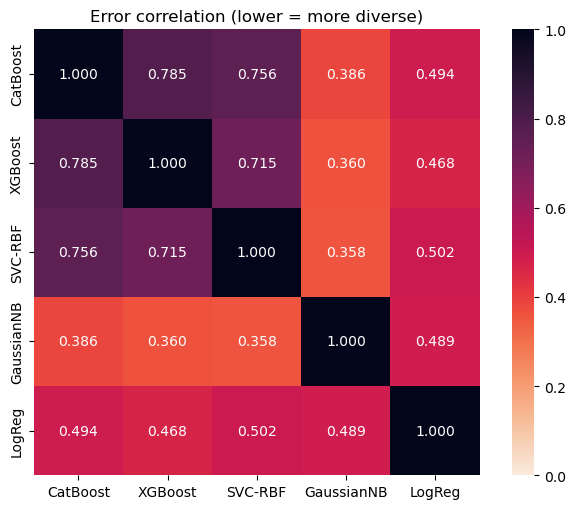

Gate: solo macro-F1 >= 0.7808  AND  mean error-corr to current < 0.6
  GaussianNB  solo=0.6480 [TOO WEAK]   err-corr-to-current=0.368 [diverse]   -> REJECT
  LogReg      solo=0.7440 [TOO WEAK]   err-corr-to-current=0.488 [diverse]   -> REJECT

New members that earned a seat: none


In [99]:
# Error-correlation heatmap across current members + candidates.
members = ["CatBoost", "XGBoost", "SVC-RBF", "GaussianNB", "LogReg"]
err = {m: (runs[m]["oof"] != y.values).astype(int) for m in members}
errcorr = pd.DataFrame(index=members, columns=members, dtype=float)
for a in members:
    for b in members:
        errcorr.loc[a, b] = (np.nan if err[a].std()==0 or err[b].std()==0
                             else np.corrcoef(err[a], err[b])[0, 1])

fig, ax = plt.subplots(figsize=(6.8, 5.2))
sns.heatmap(errcorr.astype(float), annot=True, fmt=".3f", cmap="rocket_r",
            vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Error correlation (lower = more diverse)")
plt.tight_layout(); plt.show()

# Apply the gate.
STRENGTH = BENCH_MEAN - 0.05     # >= 0.7808
DECORR   = 0.60                  # mean error-corr to the 3 current members must be below this
current = ["CatBoost", "XGBoost", "SVC-RBF"]
candidates = ["GaussianNB", "LogReg"]
passed = []
print(f"Gate: solo macro-F1 >= {STRENGTH:.4f}  AND  mean error-corr to current < {DECORR}")
for m in candidates:
    solo = runs[m]["mean"]
    corr_cur = float(np.mean([errcorr.loc[m, c] for c in current]))
    strong = solo >= STRENGTH
    diverse = corr_cur < DECORR
    ok = strong and diverse
    print(f"  {m:11s} solo={solo:.4f} [{'strong' if strong else 'TOO WEAK'}]   "
          f"err-corr-to-current={corr_cur:.3f} [{'diverse' if diverse else 'too correlated'}]"
          f"   -> {'PASS' if ok else 'REJECT'}")
    if ok:
        passed.append(m)
print(f"\nNew members that earned a seat: {passed or 'none'}")

## Part 11.2 — Meta-learner sweep

The **meta-learner** is the final model that turns the base models' probabilities into the
prediction. We compare three choices on the **same folds**, all with internal `cv=5` and
`stack_method="predict_proba"`:
- **LogisticRegression** — the current meta (simple linear blend of base probabilities).
- **LogisticRegressionCV** — same idea but it **auto-tunes its regularization `C`** by internal
  CV, so it can damp a base that's overconfident.
- **RandomForest meta** — a *nonlinear* blender that can learn interactions like "trust SVC only
  when the boosters disagree." More flexible, but more prone to overfit the small meta-table.

The base set = the three strong members **+ any candidate that passed the gate** in 11.1.

In [100]:
def base_estimators():
    ests = [("catboost", f_cat()), ("xgboost", f_xgb()), ("svc_rbf", f_svc_proba())]
    if "GaussianNB" in passed: ests.append(("gnb", make_pipeline(GaussianNB())))
    if "LogReg" in passed:     ests.append(("logreg", make_pipeline(
                                   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))))
    return ests

def build_stack(final_estimator, passthrough=False):
    return StackingClassifier(estimators=base_estimators(),
                              final_estimator=final_estimator, cv=5,
                              stack_method="predict_proba", passthrough=passthrough, n_jobs=-1)

print(f"Base members in the stack: {[n for n,_ in base_estimators()]}")

# Meta variant 1: plain LogReg == the default Part-9 stack (our benchmark, recomputed in-run).
runs["Stack: LogReg meta"] = eval_full(
    lambda: build_stack(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Stack: LogReg meta (default)")

# Meta variant 2: LogisticRegressionCV (auto-tuned C).
runs["Stack: LogRegCV meta"] = eval_full(
    lambda: build_stack(LogisticRegressionCV(Cs=10, max_iter=2000, random_state=RANDOM_STATE)),
    "Stack: LogRegCV meta")

# Meta variant 3: RandomForest meta (nonlinear blender).
runs["Stack: RF meta"] = eval_full(
    lambda: build_stack(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                               n_jobs=-1)),
    "Stack: RF meta")

Base members in the stack: ['catboost', 'xgboost', 'svc_rbf']


Stack: LogReg meta (default)       macro-F1 = 0.8308 +/- 0.0052   stage2-F1 = 0.7813   (73s)


Stack: LogRegCV meta               macro-F1 = 0.8315 +/- 0.0054   stage2-F1 = 0.7811   (78s)


Stack: RF meta                     macro-F1 = 0.8293 +/- 0.0065   stage2-F1 = 0.7822   (76s)


## Part 11.3 — Stack with passthrough

`passthrough=True` gives the meta-learner the **raw features** *in addition to* the base
probabilities. **Why it can help:** the meta-model can then *condition* its blend on where a
point sits in feature space (e.g. "in this region, weight SVC more"). **Why it can hurt:** it
hands the meta-model many more inputs to fit, which can **overfit** the small stacked table — so
we trust it only on a > 1-std gain.

**One technical gotcha:** passthrough forwards the *original* features, which still contain the
`eog_burst_index` `NaN`s. A plain LogReg meta would crash on `NaN`, so for this variant we wrap
the meta in an **impute→scale pipeline** (the base-probability columns have no `NaN`, so this is
harmless to them).

In [101]:
# Meta wrapped so it can impute the NaNs that passthrough forwards from the raw features.
runs["Stack: passthrough"] = eval_full(
    lambda: build_stack(make_pipeline(
                LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
            passthrough=True),
    "Stack: LogReg meta + passthrough")

Stack: LogReg meta + passthrough   macro-F1 = 0.8314 +/- 0.0066   stage2-F1 = 0.7797   (74s)


## Part 11.4 — Scoreboard + honesty check

All stacks on the **same folds** vs the default-stack benchmark. The decision rule, applied
programmatically: a variant is a **real win** only if it beats the benchmark by **> 1 fold std
(~0.005)**. Inside that band it's a **tie** → keep the simpler prior stack.

In [102]:
stack_keys = [k for k in runs if k.startswith("Stack")]
board = (pd.DataFrame([{"config": runs[k]["label"], "macro_f1": runs[k]["mean"],
                        "std": runs[k]["std"], "stage2_f1": runs[k]["stage2_f1"]}
                       for k in stack_keys])
           .sort_values("macro_f1", ascending=False).reset_index(drop=True))
print(board.round(4).to_string(index=False))

default_stack = runs["Stack: LogReg meta"]
best_key = max(stack_keys, key=lambda k: runs[k]["mean"])
best = runs[best_key]
delta = best["mean"] - default_stack["mean"]
print(f"\nBest stack: {best['label']}  ({best['mean']:.4f} +/- {best['std']:.4f})")
print(f"vs default LogReg-meta stack ({default_stack['mean']:.4f}): delta {delta:+.4f}  "
      f"(need > +{default_stack['std']:.4f})")
if best_key != "Stack: LogReg meta" and delta > default_stack["std"]:
    print(f"=> REAL WIN: '{best['label']}' beats the default stack beyond noise. Carry it forward.")
elif delta > 0 and best_key != "Stack: LogReg meta":
    print(f"=> TIE: ahead by {delta:+.4f} but within one fold std -> KEEP the default stack "
          f"(simpler, Kaggle-validated 0.8328).")
else:
    print("=> Nothing beat the default LogReg-meta stack -> keep it.")

                          config  macro_f1    std  stage2_f1
            Stack: LogRegCV meta    0.8315 0.0054     0.7811
Stack: LogReg meta + passthrough    0.8314 0.0066     0.7797
    Stack: LogReg meta (default)    0.8308 0.0052     0.7813
                  Stack: RF meta    0.8293 0.0065     0.7822

Best stack: Stack: LogRegCV meta  (0.8315 +/- 0.0054)
vs default LogReg-meta stack (0.8308): delta +0.0007  (need > +0.0052)
=> TIE: ahead by +0.0007 but within one fold std -> KEEP the default stack (simpler, Kaggle-validated 0.8328).


=== Out-of-fold classification report: Stack: LogRegCV meta ===
              precision    recall  f1-score   support

           0      0.864     0.858     0.861      2001
           1      0.845     0.850     0.847      2442
           2      0.786     0.776     0.781      2237
           3      0.831     0.842     0.836      2320

    accuracy                          0.831      9000
   macro avg      0.832     0.831     0.832      9000
weighted avg      0.831     0.831     0.831      9000



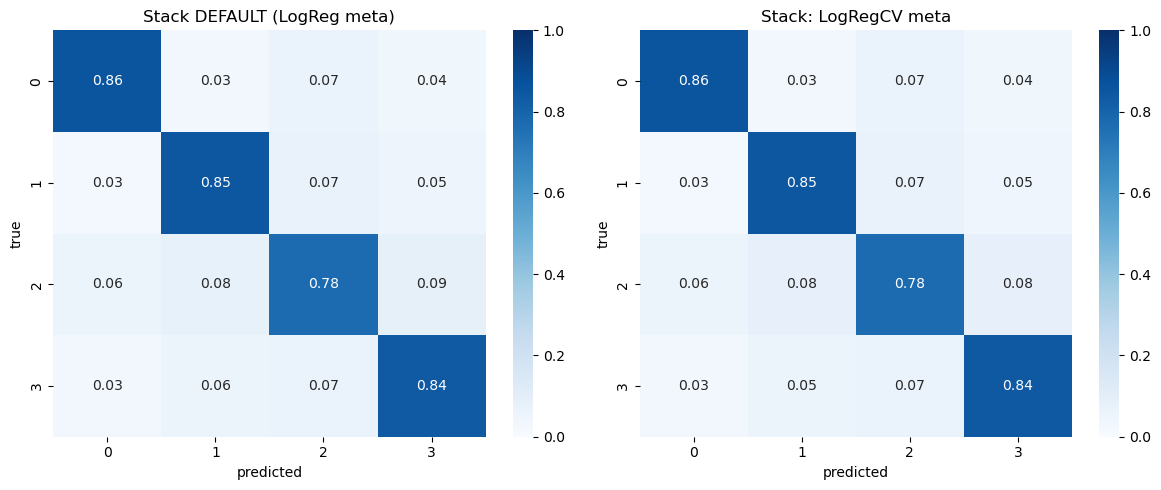

stage-2 F1:           default 0.781  ->  best 0.781  (delta -0.000)
stage2->stage3 conf:  default 8.7%  ->  best 8.5%


In [103]:
# Bottleneck check: best variant vs default stack, did stage 2 move?
def norm_cm(oof):
    cm = confusion_matrix(y, oof, labels=classes)
    return cm / cm.sum(axis=1, keepdims=True)

print(f"=== Out-of-fold classification report: {best['label']} ===")
print(classification_report(y, best["oof"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, run, tag in [(axes[0], default_stack, "Stack DEFAULT (LogReg meta)"),
                     (axes[1], best, best["label"])]:
    sns.heatmap(norm_cm(run["oof"]), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(tag); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

r2, c3 = classes.index(2), classes.index(3)
print(f"stage-2 F1:           default {default_stack['stage2_f1']:.3f}  ->  "
      f"best {best['stage2_f1']:.3f}  (delta {best['stage2_f1']-default_stack['stage2_f1']:+.3f})")
print(f"stage2->stage3 conf:  default {norm_cm(default_stack['oof'])[r2,c3]*100:.1f}%  ->  "
      f"best {norm_cm(best['oof'])[r2,c3]*100:.1f}%")

## Part 11.5 — Takeaway

**What we tried:** more diverse base members (gated on strength + decorrelation), three
meta-learners, and feature passthrough — every avenue for squeezing more out of *ensembling*
rather than more trees.

**Read the verdict from Part 11.4:**
- **If a variant beat the default stack by > 1 std** (especially if stage 2 improved): fold that
  change into the Part-9 finalize cell and regenerate `submission.csv` (re-confirm CV first).
- **If everything tied (the expected outcome):** we've reached the **cross-geometry ceiling** —
  the big win was SVC's curves (Part 8); beyond that, extra members / fancier meta-layers /
  passthrough don't add separable signal, they just add variance. The honest call is to **keep
  the Part-9 default stack** (CV 0.8308, Kaggle 0.8328) and consider the model **final**.

Either way, the candidate gate did its job: weak-but-diverse models (like GaussianNB / a linear
base, as with KNN before) are correctly kept out unless they clear *both* bars. The project's
arc — EDA → boosting → **geometric diversity** → disciplined stop — holds.

> Leakage discipline held: per-fold impute→scale pipelines for every base; stacking's internal
> `cv=5` keeps meta-features out-of-fold; the passthrough meta imputes the forwarded `NaN`s;
> `class_weight="balanced"` stayed rejected. No submission regenerated here.